In [ ]:
import json
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
import vector
import pandas as pd
import torch

In [ ]:
def to_p4(p4_obj):
    return vector.awk(
        ak.zip(
            {
                "mass": p4_obj.tau,
                "x": p4_obj.x,
                "y": p4_obj.y,
                "z": p4_obj.z,
            }
        )
    )

In [90]:
output_dir = '/home/norman/ml-tau/ml-tau-en-reg/training-outputs/260210_charge_classification_e50/charge_classification/ParticleTransformer'
test_results_path = f'{output_dir}/zz_test.parquet'

In [91]:
test_data = ak.from_parquet(test_results_path)
preds = test_data['charge_classification']['pred']
targets = test_data['charge_classification']['target']

In [92]:
# Confusion matrix at the default hard-decision threshold
model_score = np.asarray(preds)
target_binary = np.asarray(targets)
y_pred = (model_score >= 0.5).astype(int)

cm = confusion_matrix(target_binary, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


In [93]:
plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['Predicted -', 'Predicted +'], 
            yticklabels=['True -', 'True +'])
plt.title('Charge Classification: Normalized Confusion Matrix')

Text(0.5, 1.0, 'Charge Classification: Normalized Confusion Matrix')

In [94]:
zz_test = ak.from_parquet("/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206_365/zz_test.parquet")
zz_train = ak.from_parquet("/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206_365/zz_train.parquet")
zh_train = ak.from_parquet("/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206_365/zh_train.parquet")

In [95]:
mask = to_p4(zz_test.reco_jet_p4s).pt > 5
data_ptcut = zz_test[mask]

mask1 = to_p4(zz_train.reco_jet_p4s).pt > 5
mask2 = to_p4(zh_train.reco_jet_p4s).pt > 5

zz_ptcut = zz_train[mask1]
zh_ptcut = zh_train[mask2]

In [96]:
pf_pid = data_ptcut.reco_cand_pdg
gen_charge = data_ptcut.gen_jet_tau_charge
pf_charges = data_ptcut.reco_cand_charge
jet_charge_sum = ak.sum(pf_charges, axis=1)
baseline_score = ak.to_numpy(jet_charge_sum)
model_score = test_data.charge_classification.pred
target = test_data.charge_classification.target

In [97]:
data_ptcut.fields

['reco_cand_p4s',
 'reco_cand_charge',
 'reco_cand_pdg',
 'reco_jet_p4s',
 'reco_cand_dxy',
 'reco_cand_dz',
 'reco_cand_dxy_err',
 'reco_cand_dz_err',
 'gen_jet_p4s',
 'gen_jet_tau_decaymode',
 'gen_jet_tau_charge',
 'gen_jet_tau_p4s']

Best Q_kappa baseline by AUC: kappa = 0.2


,kappa,auc,accuracy
0,0.2,0.963258,0.897341
1,0.3,0.962790,0.895969
2,0.1,0.962717,0.897057
3,0.4,0.960610,0.891617
4,0.5,0.957018,0.885916
5,0.6,0.952545,0.880334
6,0.7,0.947720,0.875627
7,0.8,0.943008,0.872268
8,0.9,0.938472,0.869169
9,1.0,0.934366,0.866969


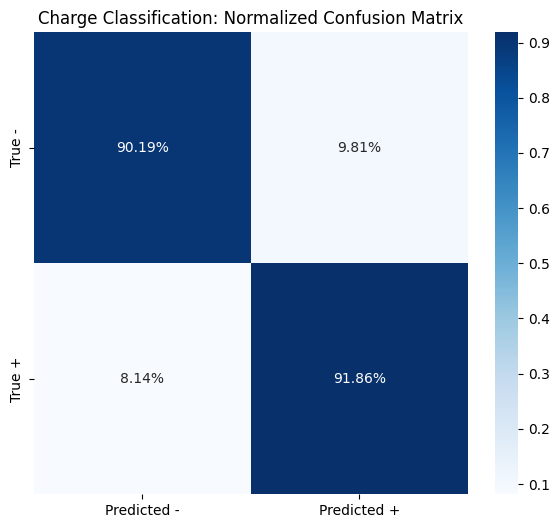

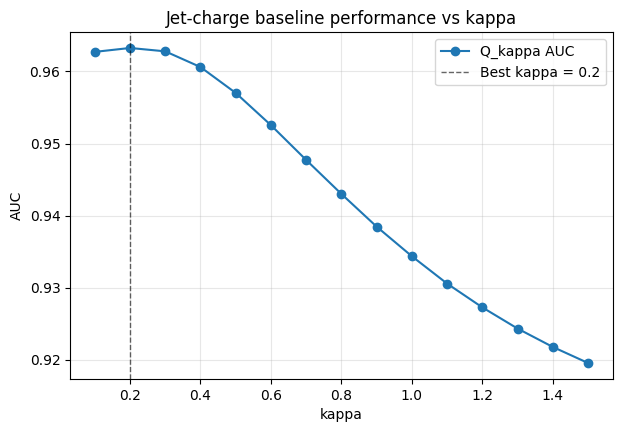

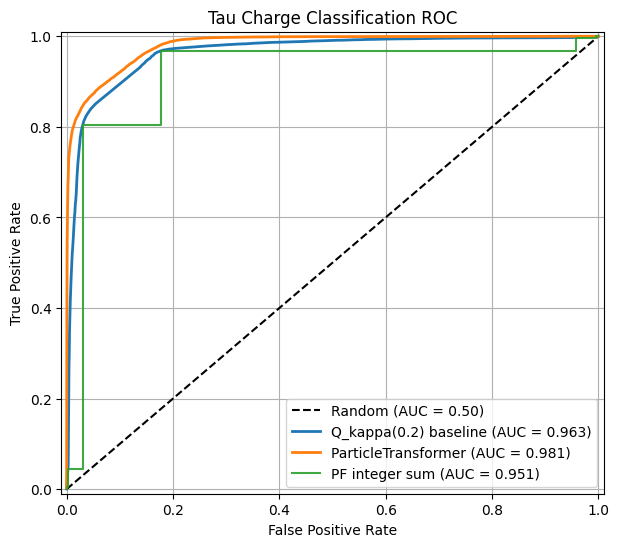

In [98]:
# compute pT-weighted jet charge

def jet_charge_qkappa(charges, pts, jet_pts, kappa=0.5):
    numer = ak.sum(charges * (pts ** kappa), axis=1)
    denom = jet_pts ** kappa
    denom = ak.where(denom == 0, 1.0, denom)
    return ak.to_numpy(numer / denom)

pf_charges = data_ptcut.reco_cand_charge
pf_pts = to_p4(data_ptcut.reco_cand_p4s).pt
jet_pts = to_p4(data_ptcut.reco_jet_p4s).pt

# scan a grid of kappa values to find the strongest jet-charge baseline
kappa_values = np.round(np.arange(0.1, 1.6, 0.1), 2)
qkappa_scores = {
    float(kappa): jet_charge_qkappa(pf_charges, pf_pts, jet_pts, kappa=float(kappa))
    for kappa in kappa_values
}

# PF sum baseline
pf_sum = ak.to_numpy(ak.sum(pf_charges, axis=1))

# get model scores
model_score = np.asarray(test_data.charge_classification.pred)
target = np.asarray(test_data.charge_classification.target)

def compute_roc_auc(y_true, scores):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_val = auc(fpr, tpr)
    return fpr, tpr, auc_val

kappa_scan_rows = []
for kappa in kappa_values:
    qk = qkappa_scores[float(kappa)]
    _, _, auc_val = compute_roc_auc(target, qk)
    accuracy_val = np.mean((qk >= 0.0).astype(int) == target)
    kappa_scan_rows.append({
        'kappa': float(kappa),
        'auc': auc_val,
        'accuracy': accuracy_val,
    })

kappa_scan_df = pd.DataFrame(kappa_scan_rows)
kappa_scan_plot_df = kappa_scan_df.sort_values('kappa').reset_index(drop=True)
kappa_scan_df = kappa_scan_df.sort_values('auc', ascending=False).reset_index(drop=True)
best_kappa = float(kappa_scan_df.loc[0, 'kappa'])
best_kappa_label = f'{best_kappa:.2f}'.rstrip('0').rstrip('.')
qk_best = qkappa_scores[best_kappa]

print(f'Best Q_kappa baseline by AUC: kappa = {best_kappa_label}')
display(kappa_scan_df)

plt.figure(figsize=(7, 4.5))
plt.plot(kappa_scan_plot_df['kappa'], kappa_scan_plot_df['auc'], marker='o', label='Q_kappa AUC')
plt.axvline(best_kappa, color='black', linestyle='--', linewidth=1, alpha=0.6, label=f'Best kappa = {best_kappa_label}')
plt.xlabel('kappa')
plt.ylabel('AUC')
plt.title('Jet-charge baseline performance vs kappa')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

fpr_model, tpr_model, auc_model = compute_roc_auc(target, model_score)
fpr_qk_best, tpr_qk_best, auc_qk_best = compute_roc_auc(target, qk_best)
fpr_pf, tpr_pf, auc_pf = compute_roc_auc(target, pf_sum)

# dense interpolated curves for plotting
fpr_dense = np.linspace(0.0, 1.0, 2000)
tpr_model_dense = np.interp(fpr_dense, fpr_model, tpr_model)
tpr_qk_best_dense = np.interp(fpr_dense, fpr_qk_best, tpr_qk_best)

# plot
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.plot(
    fpr_dense,
    tpr_qk_best_dense,
    label=f'Q_kappa({best_kappa_label}) baseline (AUC = {auc_qk_best:.3f})',
    lw=2,
)
plt.plot(fpr_dense, tpr_model_dense, label=f'ParticleTransformer (AUC = {auc_model:.3f})', lw=2)
plt.step(fpr_pf, tpr_pf, where='post', label=f'PF integer sum (AUC = {auc_pf:.3f})', alpha=0.9)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tau Charge Classification ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.ylim(-0.01, 1.01)
plt.xlim(-0.01, 1.01)
plt.show()


In [99]:
def jet_charge_qkappa(cand_charges, cand_pts, jet_pts, kappa=0.5):
    numer = ak.sum(cand_charges * (cand_pts ** kappa), axis=1)
    denom = jet_pts ** kappa
    denom = ak.where(denom == 0, 1.0, denom)
    return ak.to_numpy(numer / denom)

pf_charges = data_ptcut.reco_cand_charge
pf_pts = to_p4(data_ptcut.reco_cand_p4s).pt
jet_pts = to_p4(data_ptcut.reco_jet_p4s).pt

charges_kappa = jet_charge_qkappa(pf_charges, pf_pts, jet_pts, kappa=0.2)


In [100]:
charges0

array([-0.94524939,  0.76981706,  0.99750878, ...,  0.98044431,
        0.40523481, -0.64509948], shape=(42276,))

In [101]:
pf_sum = ak.to_numpy(ak.sum(data_ptcut.reco_cand_charge, axis=1))
print("unique values count:", np.unique(pf_sum).size)
print("unique values:", np.unique(pf_sum))

unique values count: 12
unique values: [-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.]


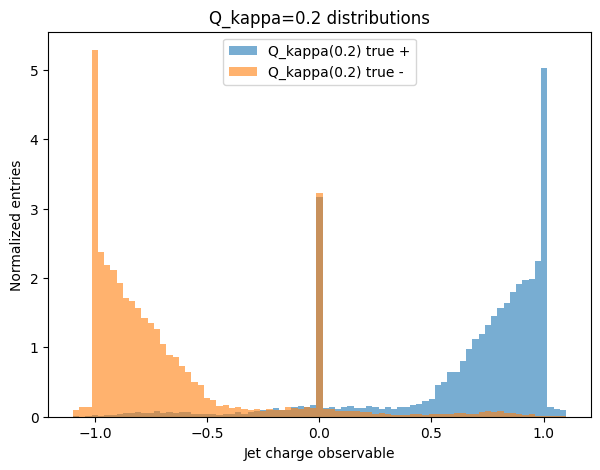

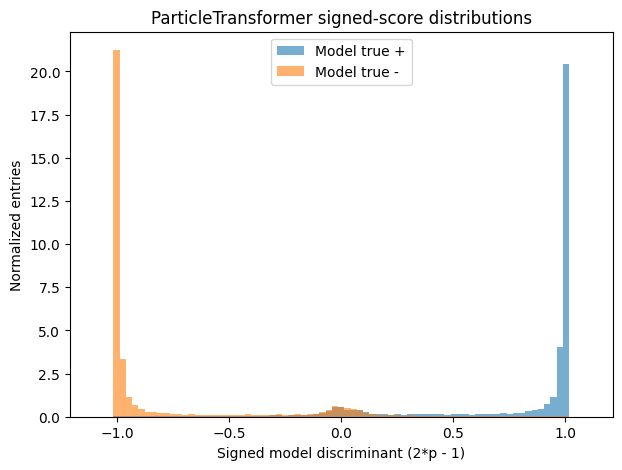

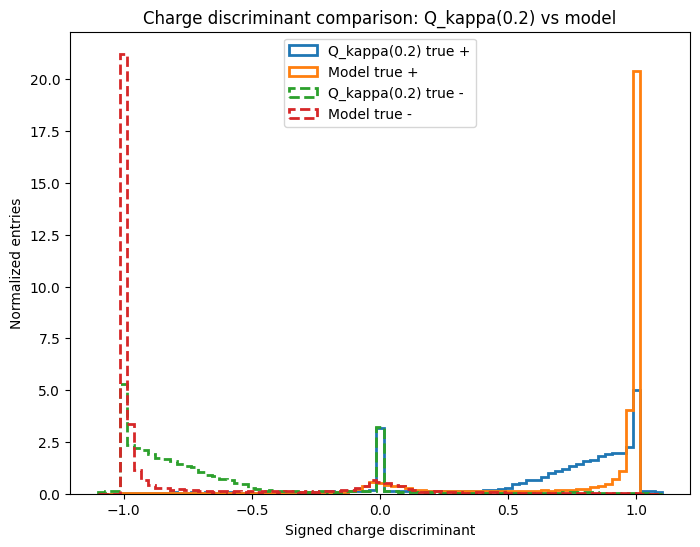

In [102]:
# map the model score p from [0, 1] to a signed discriminant in [-1, 1]
model_signed = 2.0 * np.asarray(model_score) - 1.0

bins = np.linspace(-1.1, 1.1, 80)

# baseline jet-charge distribution
plt.figure(figsize=(7, 5))
plt.hist(qk_best[target == 1], bins=bins, density=True, alpha=0.6, label=f'Q_kappa({best_kappa_label}) true +')
plt.hist(qk_best[target == 0], bins=bins, density=True, alpha=0.6, label=f'Q_kappa({best_kappa_label}) true -')
plt.legend()
plt.xlabel('Jet charge observable')
plt.ylabel('Normalized entries')
plt.title(f'Q_kappa={best_kappa_label} distributions')
plt.show()

# model signed-score distribution
plt.figure(figsize=(7, 5))
plt.hist(model_signed[target == 1], bins=bins, density=True, alpha=0.6, label='Model true +')
plt.hist(model_signed[target == 0], bins=bins, density=True, alpha=0.6, label='Model true -')
plt.legend()
plt.xlabel('Signed model discriminant (2*p - 1)')
plt.ylabel('Normalized entries')
plt.title('ParticleTransformer signed-score distributions')
plt.show()

# overlay baseline and model for direct comparison
plt.figure(figsize=(8, 6))
plt.hist(qk_best[target == 1], bins=bins, density=True, histtype='step', linewidth=2, label=f'Q_kappa({best_kappa_label}) true +')
plt.hist(model_signed[target == 1], bins=bins, density=True, histtype='step', linewidth=2, label='Model true +')
plt.hist(qk_best[target == 0], bins=bins, density=True, histtype='step', linewidth=2, linestyle='--', label=f'Q_kappa({best_kappa_label}) true -')
plt.hist(model_signed[target == 0], bins=bins, density=True, histtype='step', linewidth=2, linestyle='--', label='Model true -')
# plt.axvline(0.0, color='black', linewidth=1, alpha=0.5)
plt.legend()
plt.xlabel('Signed charge discriminant')
plt.ylabel('Normalized entries')
plt.title(f'Charge discriminant comparison: Q_kappa({best_kappa_label}) vs model')
plt.show()

In [103]:
# helper: compute Q_kappa (floating baseline)
def jet_charge_qkappa(charges, pts, jet_pts, kappa=0.5):
    """charges, pts: awkward arrays ragged (n_jets, n_cands)"""
    numer = ak.sum(charges * (pts ** kappa), axis=1)
    denom = jet_pts ** kappa
    denom = ak.where(denom == 0, 1.0, denom)
    return ak.to_numpy(numer / denom)

# extract arrays
pf_charges = data_ptcut.reco_cand_charge
pf_pts = to_p4(data_ptcut.reco_cand_p4s).pt
jet_pts = to_p4(data_ptcut.reco_jet_p4s).pt

# integer PF charge sum baseline
pf_sum = ak.to_numpy(ak.sum(pf_charges, axis=1))

# Q_kappa baselines for comparison
q03 = jet_charge_qkappa(pf_charges, pf_pts, jet_pts, kappa=0.3)
q05 = jet_charge_qkappa(pf_charges, pf_pts, jet_pts, kappa=0.5)
q10 = jet_charge_qkappa(pf_charges, pf_pts, jet_pts, kappa=1.0)
qk_best = jet_charge_qkappa(pf_charges, pf_pts, jet_pts, kappa=best_kappa)

# model outputs and target
model_raw = np.asarray(test_data.charge_classification.pred)
model_signed = 2.0 * model_raw - 1.0
target_raw = np.asarray(test_data.charge_classification.target)

if np.issubdtype(model_raw.dtype, np.floating):
    model_label = (model_raw >= 0.5).astype(int)
else:
    model_label = model_raw.astype(int)

# map label convention to signed charge: 0 stands for -1
pred_charge_signed = np.where(model_label == 0, -1, +1)
true_charge_signed = np.where(target_raw == 0, -1, +1)

df = pd.DataFrame({
    'true_charge': true_charge_signed,
    'model_signed': model_signed,
    'pred_charge': pred_charge_signed,
    'pf_sum': pf_sum,
    f'q_kappa_best_{best_kappa_label}': qk_best,
    'q_kappa_0.3': q03,
    'q_kappa_0.5': q05,
    'q_kappa_1.0': q10,
})
df


,true_charge,model_signed,pred_charge,pf_sum,q_kappa_best_0.2,q_kappa_0.3,q_kappa_0.5,q_kappa_1.0
0,-1,-0.999757,-1,-1.0,-0.945249,-0.919009,-0.868692,-0.754626
1,1,0.987496,1,1.0,0.769817,0.675421,0.519918,0.270242
2,1,0.992505,1,1.0,0.997509,0.996265,0.993784,0.987606
3,-1,-0.974247,-1,-2.0,-1.259501,-1.001227,-0.634870,-0.207237
4,1,0.984143,1,1.0,0.349234,0.122943,-0.193250,-0.527203
...,...,...,...,...,...,...,...,...
42271,-1,-0.996303,-1,-1.0,-0.662785,-0.535942,-0.343845,-0.090596
42272,1,0.998477,1,1.0,0.921403,0.884452,0.814937,0.664122
42273,1,0.998797,1,1.0,0.980444,0.970810,0.951825,0.905972
42274,-1,-0.257929,-1,0.0,0.405235,0.528548,0.678049,0.775194


In [104]:
def compute_binned_metrics(x_values, bins, target_binary, model_score, q_baseline):
    model_binary = (np.asarray(model_score) >= 0.5).astype(int)
    q_baseline_binary = (q_baseline >= 0.0).astype(int)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    model_accuracy = []
    q_baseline_accuracy = []
    model_auc = []
    q_baseline_auc = []
    valid_auc_mask = []
    bin_counts = []

    for low, high in zip(bins[:-1], bins[1:]):
        in_bin = (x_values >= low) & (x_values < high)
        bin_counts.append(np.sum(in_bin))
        if np.sum(in_bin) == 0:
            model_accuracy.append(np.nan)
            q_baseline_accuracy.append(np.nan)
            model_auc.append(np.nan)
            q_baseline_auc.append(np.nan)
            valid_auc_mask.append(False)
            continue

        y_bin = target_binary[in_bin]
        model_accuracy.append(np.mean(model_binary[in_bin] == y_bin))
        q_baseline_accuracy.append(np.mean(q_baseline_binary[in_bin] == y_bin))

        has_both_classes = np.unique(y_bin).size == 2
        valid_auc_mask.append(has_both_classes)
        if has_both_classes:
            model_auc.append(auc(*roc_curve(y_bin, np.asarray(model_score)[in_bin])[:2]))
            q_baseline_auc.append(auc(*roc_curve(y_bin, q_baseline[in_bin])[:2]))
        else:
            model_auc.append(np.nan)
            q_baseline_auc.append(np.nan)

    return (
        bin_centers,
        np.array(model_accuracy),
        np.array(q_baseline_accuracy),
        np.array(model_auc),
        np.array(q_baseline_auc),
        np.array(valid_auc_mask, dtype=bool),
        np.array(bin_counts),
    )


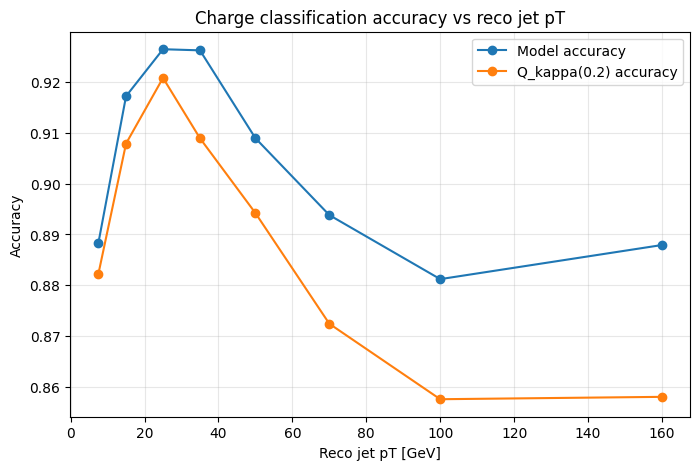

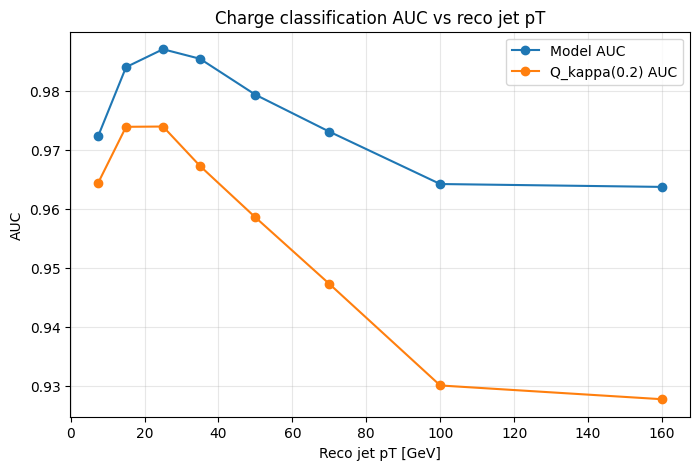

pT bin [5, 10) GeV: 4108 jets
pT bin [10, 20) GeV: 8903 jets
pT bin [20, 30) GeV: 7969 jets
pT bin [30, 40) GeV: 5952 jets
pT bin [40, 60) GeV: 7260 jets
pT bin [60, 80) GeV: 3880 jets
pT bin [80, 120) GeV: 3384 jets
pT bin [120, 200) GeV: 803 jets



In [105]:
reco_jet_pt = ak.to_numpy(to_p4(data_ptcut.reco_jet_p4s).pt)
target_binary = np.asarray(target)
pt_bins = np.array([5, 10, 20, 30, 40, 60, 80, 120, 200])
pt_bin_centers, model_accuracy, qk_accuracy, model_auc, qk_auc, valid_auc_mask, pt_counts = compute_binned_metrics(
    reco_jet_pt, pt_bins, target_binary, model_score, qk_best
)

plt.figure(figsize=(8, 5))
plt.plot(pt_bin_centers, model_accuracy, marker='o', label='Model accuracy')
plt.plot(pt_bin_centers, qk_accuracy, marker='o', label=f'Q_kappa({best_kappa_label}) accuracy')
plt.xlabel('Reco jet pT [GeV]')
plt.ylabel('Accuracy')
plt.title('Charge classification accuracy vs reco jet pT')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(pt_bin_centers[valid_auc_mask], model_auc[valid_auc_mask], marker='o', label='Model AUC')
plt.plot(pt_bin_centers[valid_auc_mask], qk_auc[valid_auc_mask], marker='o', label=f'Q_kappa({best_kappa_label}) AUC')
plt.xlabel('Reco jet pT [GeV]')
plt.ylabel('AUC')
plt.title('Charge classification AUC vs reco jet pT')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

for low, high, count in zip(pt_bins[:-1], pt_bins[1:], pt_counts):
    print(f'pT bin [{low}, {high}) GeV: {count} jets')
print()


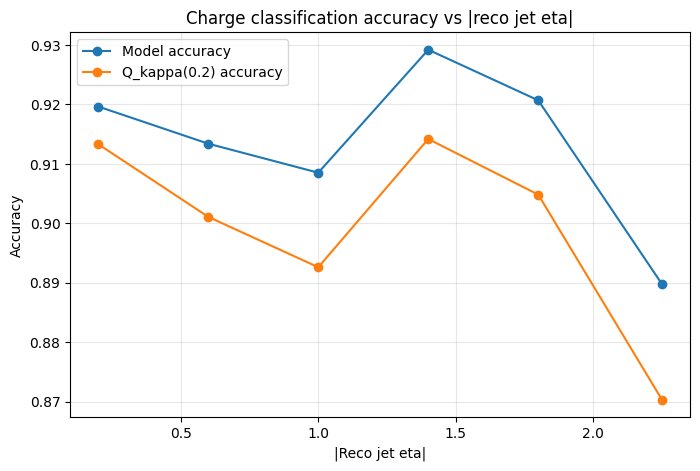

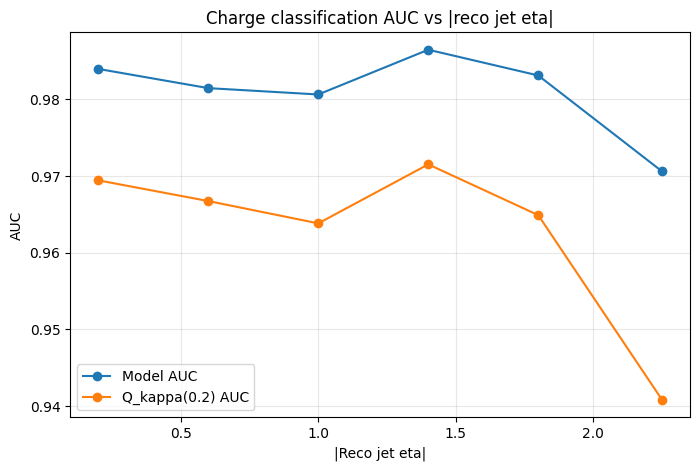

|eta| bin [0.0, 0.4): 10255 jets
|eta| bin [0.4, 0.8): 9746 jets
|eta| bin [0.8, 1.2): 8614 jets
|eta| bin [1.2, 1.6): 6258 jets
|eta| bin [1.6, 2.0): 3909 jets
|eta| bin [2.0, 2.5): 2622 jets



In [106]:
reco_jet_eta = ak.to_numpy(to_p4(data_ptcut.reco_jet_p4s).eta)
abs_reco_jet_eta = np.abs(reco_jet_eta)

eta_bins = np.array([0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.5])
eta_centers, model_acc_eta, qk_acc_eta, model_auc_eta, qk_auc_eta, valid_eta_auc, eta_counts = compute_binned_metrics(
    abs_reco_jet_eta, eta_bins, target_binary, model_score, qk_best
)

plt.figure(figsize=(8, 5))
plt.plot(eta_centers, model_acc_eta, marker='o', label='Model accuracy')
plt.plot(eta_centers, qk_acc_eta, marker='o', label=f'Q_kappa({best_kappa_label}) accuracy')
plt.xlabel('|Reco jet eta|')
plt.ylabel('Accuracy')
plt.title('Charge classification accuracy vs |reco jet eta|')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(eta_centers[valid_eta_auc], model_auc_eta[valid_eta_auc], marker='o', label='Model AUC')
plt.plot(eta_centers[valid_eta_auc], qk_auc_eta[valid_eta_auc], marker='o', label=f'Q_kappa({best_kappa_label}) AUC')
plt.xlabel('|Reco jet eta|')
plt.ylabel('AUC')
plt.title('Charge classification AUC vs |reco jet eta|')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

for low, high, count in zip(eta_bins[:-1], eta_bins[1:], eta_counts):
    print(f'|eta| bin [{low:.1f}, {high:.1f}): {count} jets')
print()


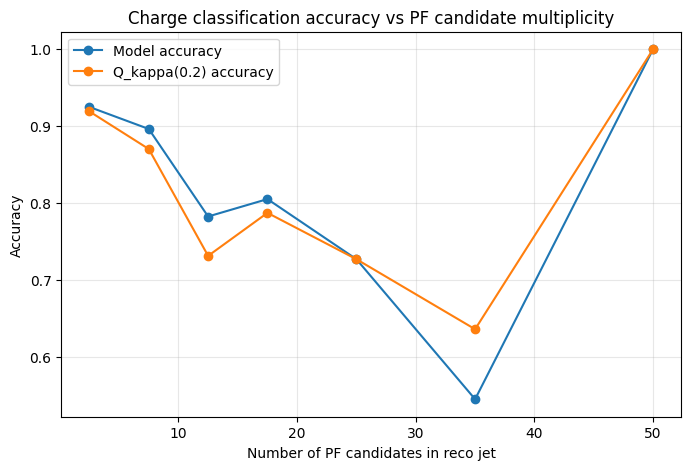

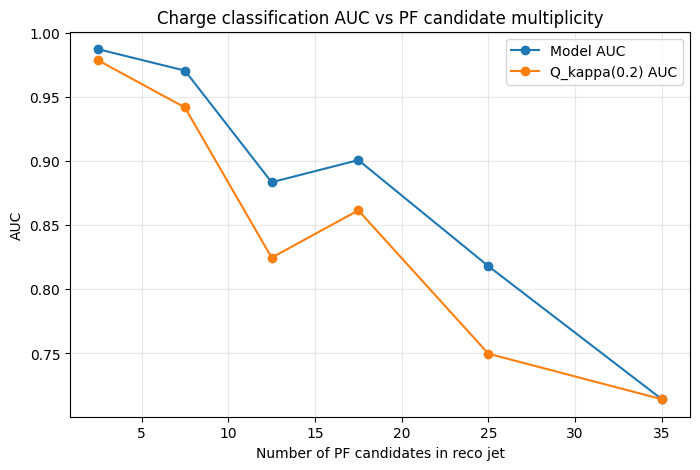

jets with ncand in [0, 5): 28245
jets with ncand in [5, 10): 12144
jets with ncand in [10, 15): 1252
jets with ncand in [15, 20): 447
jets with ncand in [20, 30): 176
jets with ncand in [30, 40): 11
jets with ncand in [40, 60): 1
jets with ncand in [60, 100): 0



In [107]:
n_constituents = ak.to_numpy(ak.num(data_ptcut.reco_cand_charge, axis=1))

nconst_bins = np.array([0, 5, 10, 15, 20, 30, 40, 60, 100])
nconst_centers, model_acc_nconst, qk_acc_nconst, model_auc_nconst, qk_auc_nconst, valid_nconst_auc, nconst_counts = compute_binned_metrics(
    n_constituents, nconst_bins, target_binary, model_score, qk_best
)

plt.figure(figsize=(8, 5))
plt.plot(nconst_centers, model_acc_nconst, marker='o', label='Model accuracy')
plt.plot(nconst_centers, qk_acc_nconst, marker='o', label=f'Q_kappa({best_kappa_label}) accuracy')
plt.xlabel('Number of PF candidates in reco jet')
plt.ylabel('Accuracy')
plt.title('Charge classification accuracy vs PF candidate multiplicity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(nconst_centers[valid_nconst_auc], model_auc_nconst[valid_nconst_auc], marker='o', label='Model AUC')
plt.plot(nconst_centers[valid_nconst_auc], qk_auc_nconst[valid_nconst_auc], marker='o', label=f'Q_kappa({best_kappa_label}) AUC')
plt.xlabel('Number of PF candidates in reco jet')
plt.ylabel('AUC')
plt.title('Charge classification AUC vs PF candidate multiplicity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

for low, high, count in zip(nconst_bins[:-1], nconst_bins[1:], nconst_counts):
    print(f'jets with ncand in [{low}, {high}): {count}')
print()


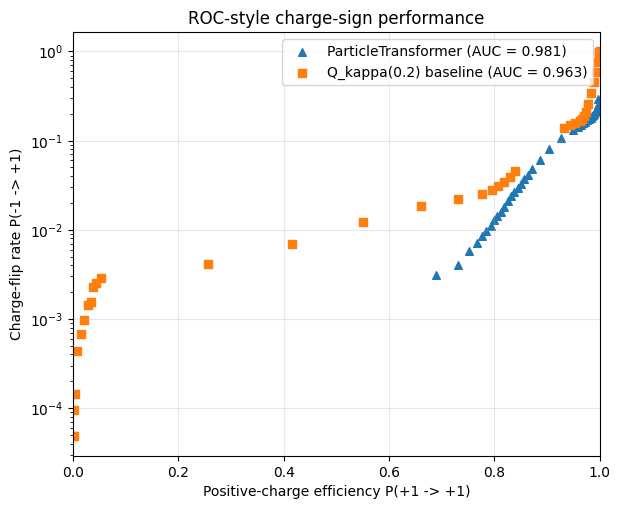

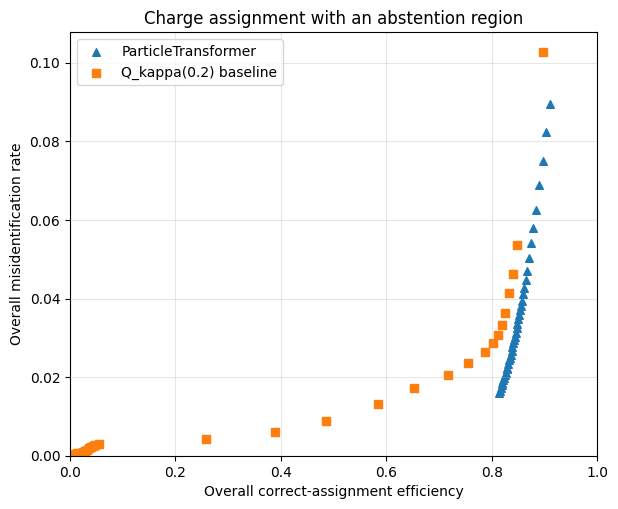

,target_pos_eff,model_flip_rate,qkappa_0.2_flip_rate
0,0.80,0.012738,0.029484
1,0.85,0.032253,0.053822
2,0.90,0.076648,0.105506
3,0.92,0.099485,0.126268


,target_correct_eff,model_misid_rate,qkappa_0.2_misid_rate
0,0.75,NaN,0.023174
1,0.80,NaN,0.028276
2,0.85,0.034417,0.055457
3,0.90,0.078949,NaN


In [108]:
# Charge performance curves
# 1. ROC-style curve for charge assignment, analogous to the tau-efficiency vs mistag plot in the paper.
# 2. Overall correct-assignment efficiency vs overall misidentification rate with an abstention region.

def compute_charge_roc_curve(y_true, score, thresholds):
    pos_mask = y_true == 1
    neg_mask = y_true == 0
    pos_eff = []
    neg_flip = []

    for thr in thresholds:
        pred_pos = score >= thr
        pos_eff.append(np.mean(pred_pos[pos_mask]))
        neg_flip.append(np.mean(pred_pos[neg_mask]))

    return np.array(pos_eff), np.array(neg_flip)

def compute_reject_curve(y_true, signed_score, margins):
    true_charge = np.where(y_true == 1, 1, -1)
    pred_charge = np.where(signed_score >= 0.0, 1, -1)
    correct_eff = []
    misid_rate = []
    assignment_eff = []

    for margin in margins:
        assigned = np.abs(signed_score) >= margin
        is_correct = assigned & (pred_charge == true_charge)
        is_wrong = assigned & (pred_charge != true_charge)
        correct_eff.append(np.mean(is_correct))
        misid_rate.append(np.mean(is_wrong))
        assignment_eff.append(np.mean(assigned))

    return np.array(correct_eff), np.array(misid_rate), np.array(assignment_eff)

def summarize_at_efficiencies(x_curve, y_curve, eff_targets, x_label, y_label):
    order = np.argsort(x_curve)
    x_sorted = x_curve[order]
    y_sorted = y_curve[order]

    x_unique, unique_idx = np.unique(x_sorted, return_index=True)
    y_unique = y_sorted[unique_idx]

    y_at_targets = np.interp(
        eff_targets,
        x_unique,
        y_unique,
        left=np.nan,
        right=np.nan,
    )
    return pd.DataFrame({
        x_label: eff_targets,
        y_label: y_at_targets,
    })

def select_display_points(x_curve, y_curve, n_points=40):
    order = np.argsort(x_curve)
    x_sorted = x_curve[order]
    y_sorted = y_curve[order]

    x_unique, unique_idx = np.unique(x_sorted, return_index=True)
    y_unique = y_sorted[unique_idx]

    if len(x_unique) <= n_points:
        return x_unique, y_unique

    idx = np.linspace(0, len(x_unique) - 1, n_points).astype(int)
    idx = np.unique(idx)
    return x_unique[idx], y_unique[idx]

target_binary = np.asarray(target)
model_score = np.asarray(model_score)
qk_best = np.asarray(qk_best)

# Signed scores centered on the natural decision boundary.
model_signed_score = 2.0 * model_score - 1.0
qk_signed_score = qk_best

model_thresholds = np.linspace(0.0, 1.0, 1000)
qk_thresholds = np.linspace(np.min(qk_best), np.max(qk_best), 1000)

model_pos_eff, model_neg_flip = compute_charge_roc_curve(target_binary, model_score, model_thresholds)
qk_pos_eff, qk_neg_flip = compute_charge_roc_curve(target_binary, qk_best, qk_thresholds)

model_x, model_y = select_display_points(model_pos_eff, model_neg_flip)
qk_x, qk_y = select_display_points(qk_pos_eff, qk_neg_flip)

plt.figure(figsize=(6.8, 5.5))
plt.scatter(model_x, model_y, s=30, marker='^', color='tab:blue', label=f'ParticleTransformer (AUC = {auc_model:.3f})')
plt.scatter(qk_x, qk_y, s=30, marker='s', color='tab:orange', label=f'Q_kappa({best_kappa_label}) baseline (AUC = {auc_qk_best:.3f})')
plt.xlabel('Positive-charge efficiency P(+1 -> +1)')
plt.ylabel('Charge-flip rate P(-1 -> +1)')
plt.title('ROC-style charge-sign performance')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0.0, 1.0)
plt.yscale('log')
plt.show()

# Reject-region scan around the natural decision boundary.
# ParticleTransformer keeps jets with |score - 0.5| >= delta.
# Q_kappa keeps jets with |Q_kappa| >= delta.
model_margins = np.linspace(0.0, 0.49, 300)
qk_margins = np.linspace(0.0, np.max(np.abs(qk_signed_score)) * 0.999, 300)

model_correct_eff, model_misid, model_assignment_eff = compute_reject_curve(target_binary, model_signed_score, model_margins)
qk_correct_eff, qk_misid, qk_assignment_eff = compute_reject_curve(target_binary, qk_signed_score, qk_margins)

model_reject_x, model_reject_y = select_display_points(model_correct_eff, model_misid)
qk_reject_x, qk_reject_y = select_display_points(qk_correct_eff, qk_misid)

plt.figure(figsize=(6.8, 5.5))
plt.scatter(model_reject_x, model_reject_y, s=30, marker='^', color='tab:blue', label='ParticleTransformer')
plt.scatter(qk_reject_x, qk_reject_y, s=30, marker='s', color='tab:orange', label=f'Q_kappa({best_kappa_label}) baseline')
plt.xlabel('Overall correct-assignment efficiency')
plt.ylabel('Overall misidentification rate')
plt.title('Charge assignment with an abstention region')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0.0, 1.0)
plt.ylim(bottom=0.0)
plt.show()

# Working-point summaries for both views.
roc_eff_targets = np.array([0.80, 0.85, 0.90, 0.92])
roc_model_summary = summarize_at_efficiencies(model_pos_eff, model_neg_flip, roc_eff_targets, 'target_pos_eff', 'flip_rate')
roc_qk_summary = summarize_at_efficiencies(qk_pos_eff, qk_neg_flip, roc_eff_targets, 'target_pos_eff', 'flip_rate')

charge_roc_table = pd.DataFrame({
    'target_pos_eff': roc_eff_targets,
    'model_flip_rate': roc_model_summary['flip_rate'],
    f'qkappa_{best_kappa_label}_flip_rate': roc_qk_summary['flip_rate'],
})
display(charge_roc_table)

reject_eff_targets = np.array([0.75, 0.80, 0.85, 0.90])
reject_model_summary = summarize_at_efficiencies(model_correct_eff, model_misid, reject_eff_targets, 'target_correct_eff', 'misidentification_rate')
reject_qk_summary = summarize_at_efficiencies(qk_correct_eff, qk_misid, reject_eff_targets, 'target_correct_eff', 'misidentification_rate')

charge_reject_table = pd.DataFrame({
    'target_correct_eff': reject_eff_targets,
    'model_misid_rate': reject_model_summary['misidentification_rate'],
    f'qkappa_{best_kappa_label}_misid_rate': reject_qk_summary['misidentification_rate'],
})
display(charge_reject_table)

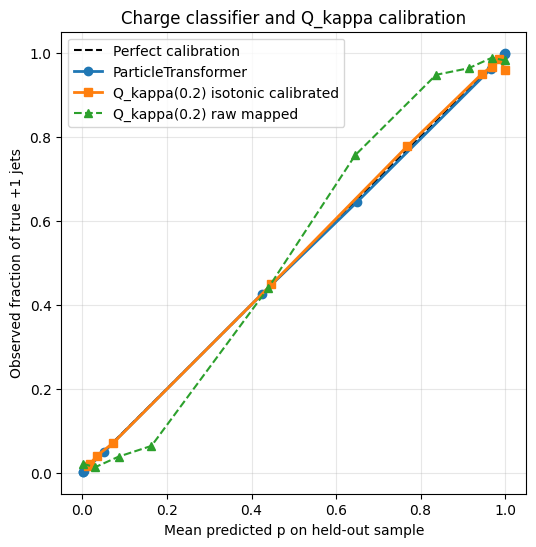

Q_kappa(0.2) isotonic calibration fit on 21138 jets and evaluated on 21138 held-out jets


In [109]:
# use a held-out split of the current sample so the Q_kappa calibrator is fit and evaluated separately
idx_all = np.arange(len(target_binary))
idx_calib, idx_eval = train_test_split(idx_all, test_size=0.5, random_state=42, stratify=target_binary)

model_score = np.asarray(model_score)
qk_best = np.asarray(qk_best)
target_binary = np.asarray(target_binary)

iso_qk_best = IsotonicRegression(out_of_bounds='clip')
iso_qk_best.fit(qk_best[idx_calib], target_binary[idx_calib])
qk_best_calibrated = iso_qk_best.transform(qk_best[idx_eval])

prob_true_model, prob_pred_model = calibration_curve(
    target_binary[idx_eval], model_score[idx_eval], n_bins=10, strategy='quantile'
)
prob_true_qk_cal, prob_pred_qk_cal = calibration_curve(
    target_binary[idx_eval], qk_best_calibrated, n_bins=10, strategy='quantile'
)
prob_true_qk_raw, prob_pred_qk_raw = calibration_curve(
    target_binary[idx_eval], np.clip(0.5 * (qk_best[idx_eval] + 1.0), 0.0, 1.0), n_bins=10, strategy='quantile'
)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.plot(prob_pred_model, prob_true_model, marker='o', linewidth=2, label='ParticleTransformer')
plt.plot(prob_pred_qk_cal, prob_true_qk_cal, marker='s', linewidth=2, label=f'Q_kappa({best_kappa_label}) isotonic calibrated')
plt.plot(prob_pred_qk_raw, prob_true_qk_raw, marker='^', linewidth=1.5, linestyle='--', label=f'Q_kappa({best_kappa_label}) raw mapped')
plt.xlabel('Mean predicted p on held-out sample')
plt.ylabel('Observed fraction of true +1 jets')
plt.title('Charge classifier and Q_kappa calibration')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(
    f'Q_kappa({best_kappa_label}) isotonic calibration fit on {len(idx_calib)} jets '
    f'and evaluated on {len(idx_eval)} held-out jets'
)


### efficiency oleks siis correct charge efficiency (nii + kui -) vs misid rate (overall mis id siis)
### teised oleksid j2lle mingi 0.5 efficiency WP vs pt jne 

Global ParticleTransformer threshold at +1 efficiency 0.50: 0.9969
Global Q_kappa(0.2) threshold at +1 efficiency 0.50: 0.8180


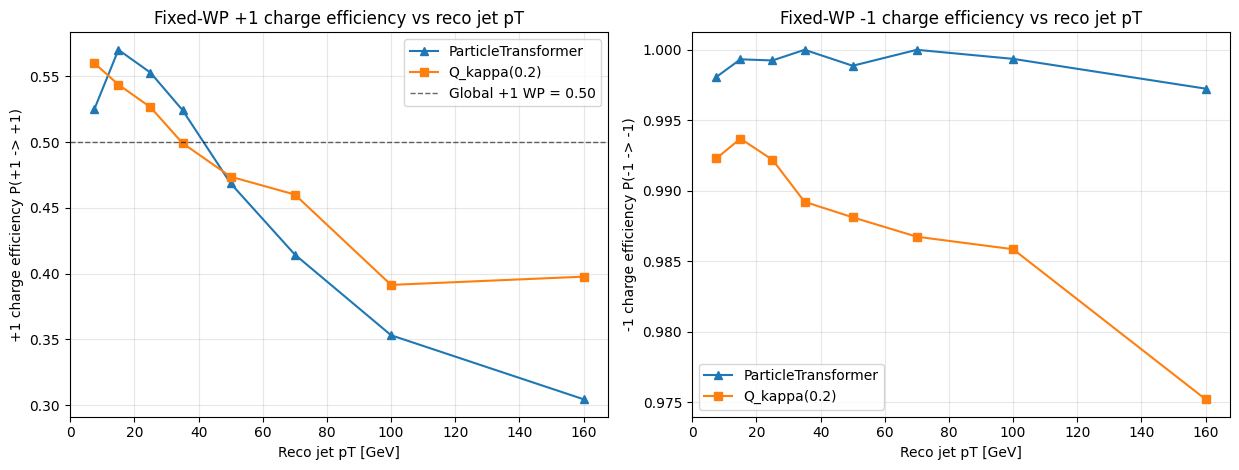

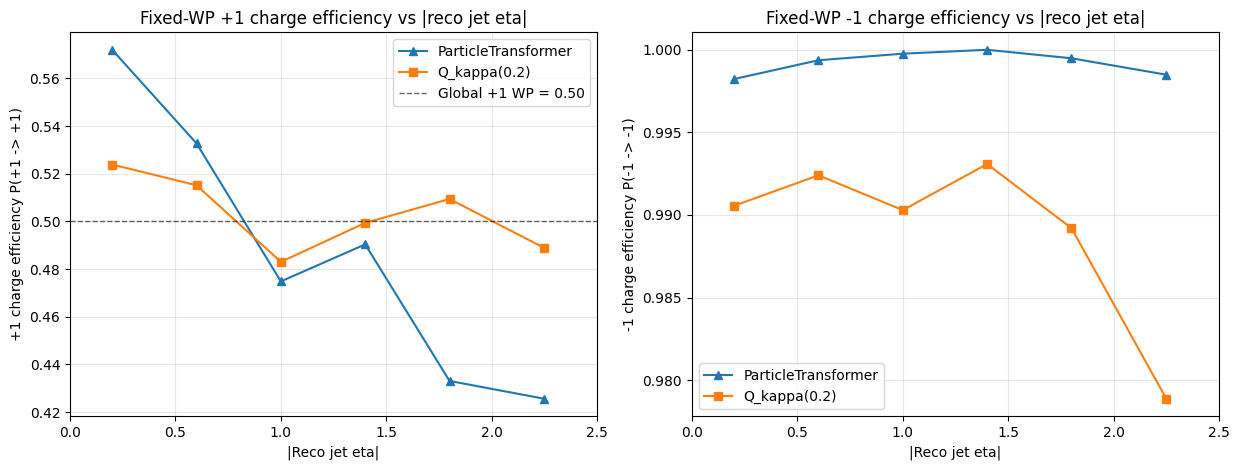

,pt_bin_low,pt_bin_high,count,model_pos_eff,model_neg_eff,model_flip_rate,qkappa_0.2_pos_eff,qkappa_0.2_neg_eff,qkappa_0.2_flip_rate
0,5,10,4108,0.525098,0.998073,0.001927,0.560039,0.992293,0.007707
1,10,20,8903,0.570179,0.999325,0.000675,0.543722,0.993698,0.006302
2,20,30,7969,0.552803,0.999245,0.000755,0.526527,0.992197,0.007803
3,30,40,5952,0.524288,1.000000,0.000000,0.499162,0.989215,0.010785
4,40,60,7260,0.468599,0.998868,0.001132,0.473698,0.988115,0.011885
5,60,80,3880,0.414536,1.000000,0.000000,0.460150,0.986737,0.013263
6,80,120,3384,0.353198,0.999357,0.000643,0.391471,0.985852,0.014148
7,120,200,803,0.304545,0.997245,0.002755,0.397727,0.975207,0.024793


,eta_bin_low,eta_bin_high,count,model_pos_eff,model_neg_eff,model_flip_rate,qkappa_0.2_pos_eff,qkappa_0.2_neg_eff,qkappa_0.2_flip_rate
0,0.0,0.4,10255,0.572009,0.998229,0.001771,0.523874,0.990555,0.009445
1,0.4,0.8,9746,0.532735,0.999367,0.000633,0.515170,0.992399,0.007601
2,0.8,1.2,8614,0.474835,0.999763,0.000237,0.483033,0.990291,0.009709
3,1.2,1.6,6258,0.490379,1.000000,0.000000,0.499379,0.993083,0.006917
4,1.6,2.0,3909,0.433079,0.999486,0.000514,0.509415,0.989198,0.010802
5,2.0,2.5,2622,0.425598,0.998491,0.001509,0.488820,0.978868,0.021132


In [110]:
# Fixed-working-point charge-sign performance vs reco kinematics.
# The threshold is chosen once on the full sample to reach the target +1-charge efficiency,
# then the same threshold is applied in every pT / |eta| bin.

target_pos_eff_wp = 0.50

def find_threshold_for_target_pos_eff(y_true, score, thresholds, target_pos_eff):
    pos_mask = y_true == 1
    pos_eff = np.array([np.mean(score[pos_mask] >= thr) for thr in thresholds])

    order = np.argsort(pos_eff)
    pos_eff_sorted = pos_eff[order]
    thr_sorted = thresholds[order]

    pos_eff_unique, unique_idx = np.unique(pos_eff_sorted, return_index=True)
    thr_unique = thr_sorted[unique_idx]
    return np.interp(target_pos_eff, pos_eff_unique, thr_unique, left=np.nan, right=np.nan)

def compute_binned_fixed_threshold_metrics(values, bins, y_true, score, threshold):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pos_eff = []
    neg_eff = []
    flip_rate = []
    overall_correct = []
    counts = []
    pos_counts = []
    neg_counts = []

    for low, high in zip(bins[:-1], bins[1:]):
        mask = (values >= low) & (values < high)
        y_bin = y_true[mask]
        score_bin = score[mask]
        counts.append(int(np.sum(mask)))

        pos_mask = y_bin == 1
        neg_mask = y_bin == 0
        pos_counts.append(int(np.sum(pos_mask)))
        neg_counts.append(int(np.sum(neg_mask)))

        if len(y_bin) == 0:
            pos_eff.append(np.nan)
            neg_eff.append(np.nan)
            flip_rate.append(np.nan)
            overall_correct.append(np.nan)
            continue

        pred_pos = score_bin >= threshold
        pred_charge = np.where(pred_pos, 1, -1)
        true_charge = np.where(y_bin == 1, 1, -1)

        pos_eff.append(np.mean(pred_pos[pos_mask]) if np.any(pos_mask) else np.nan)
        flip_rate.append(np.mean(pred_pos[neg_mask]) if np.any(neg_mask) else np.nan)
        neg_eff.append(np.mean(~pred_pos[neg_mask]) if np.any(neg_mask) else np.nan)
        overall_correct.append(np.mean(pred_charge == true_charge))

    return {
        'centers': centers,
        'pos_eff': np.array(pos_eff),
        'neg_eff': np.array(neg_eff),
        'flip_rate': np.array(flip_rate),
        'overall_correct': np.array(overall_correct),
        'counts': np.array(counts),
        'pos_counts': np.array(pos_counts),
        'neg_counts': np.array(neg_counts),
    }

target_binary = np.asarray(target)
model_score = np.asarray(model_score)
qk_best = np.asarray(qk_best)
reco_jet_pt = ak.to_numpy(to_p4(data_ptcut.reco_jet_p4s).pt)
abs_reco_jet_eta = np.abs(ak.to_numpy(to_p4(data_ptcut.reco_jet_p4s).eta))

model_threshold_wp = find_threshold_for_target_pos_eff(target_binary, model_score, np.linspace(0.0, 1.0, 2000), target_pos_eff_wp)
qk_threshold_wp = find_threshold_for_target_pos_eff(target_binary, qk_best, np.linspace(np.min(qk_best), np.max(qk_best), 2000), target_pos_eff_wp)

print(f'Global ParticleTransformer threshold at +1 efficiency {target_pos_eff_wp:.2f}: {model_threshold_wp:.4f}')
print(f'Global Q_kappa({best_kappa_label}) threshold at +1 efficiency {target_pos_eff_wp:.2f}: {qk_threshold_wp:.4f}')

pt_wp_model = compute_binned_fixed_threshold_metrics(reco_jet_pt, pt_bins, target_binary, model_score, model_threshold_wp)
pt_wp_qk = compute_binned_fixed_threshold_metrics(reco_jet_pt, pt_bins, target_binary, qk_best, qk_threshold_wp)
eta_wp_model = compute_binned_fixed_threshold_metrics(abs_reco_jet_eta, eta_bins, target_binary, model_score, model_threshold_wp)
eta_wp_qk = compute_binned_fixed_threshold_metrics(abs_reco_jet_eta, eta_bins, target_binary, qk_best, qk_threshold_wp)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True)
axes[0].plot(pt_wp_model['centers'], pt_wp_model['pos_eff'], marker='^', label='ParticleTransformer')
axes[0].plot(pt_wp_qk['centers'], pt_wp_qk['pos_eff'], marker='s', label=f'Q_kappa({best_kappa_label})')
axes[0].axhline(target_pos_eff_wp, color='black', linestyle='--', linewidth=1, alpha=0.6, label=f'Global +1 WP = {target_pos_eff_wp:.2f}')
axes[0].set_xlabel('Reco jet pT [GeV]')
axes[0].set_ylabel('+1 charge efficiency P(+1 -> +1)')
axes[0].set_title('Fixed-WP +1 charge efficiency vs reco jet pT')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(pt_wp_model['centers'], pt_wp_model['neg_eff'], marker='^', label='ParticleTransformer')
axes[1].plot(pt_wp_qk['centers'], pt_wp_qk['neg_eff'], marker='s', label=f'Q_kappa({best_kappa_label})')
axes[1].set_xlabel('Reco jet pT [GeV]')
axes[1].set_ylabel('-1 charge efficiency P(-1 -> -1)')
axes[1].set_title('Fixed-WP -1 charge efficiency vs reco jet pT')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True)
axes[0].plot(eta_wp_model['centers'], eta_wp_model['pos_eff'], marker='^', label='ParticleTransformer')
axes[0].plot(eta_wp_qk['centers'], eta_wp_qk['pos_eff'], marker='s', label=f'Q_kappa({best_kappa_label})')
axes[0].axhline(target_pos_eff_wp, color='black', linestyle='--', linewidth=1, alpha=0.6, label=f'Global +1 WP = {target_pos_eff_wp:.2f}')
axes[0].set_xlabel('|Reco jet eta|')
axes[0].set_ylabel('+1 charge efficiency P(+1 -> +1)')
axes[0].set_title('Fixed-WP +1 charge efficiency vs |reco jet eta|')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xlim(eta_bins[0], eta_bins[-1])

axes[1].plot(eta_wp_model['centers'], eta_wp_model['neg_eff'], marker='^', label='ParticleTransformer')
axes[1].plot(eta_wp_qk['centers'], eta_wp_qk['neg_eff'], marker='s', label=f'Q_kappa({best_kappa_label})')
axes[1].set_xlabel('|Reco jet eta|')
axes[1].set_ylabel('-1 charge efficiency P(-1 -> -1)')
axes[1].set_title('Fixed-WP -1 charge efficiency vs |reco jet eta|')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xlim(eta_bins[0], eta_bins[-1])
plt.tight_layout()
plt.show()

pt_wp_table = pd.DataFrame({
    'pt_bin_low': pt_bins[:-1],
    'pt_bin_high': pt_bins[1:],
    'count': pt_wp_model['counts'],
    'model_pos_eff': pt_wp_model['pos_eff'],
    'model_neg_eff': pt_wp_model['neg_eff'],
    'model_flip_rate': pt_wp_model['flip_rate'],
    f'qkappa_{best_kappa_label}_pos_eff': pt_wp_qk['pos_eff'],
    f'qkappa_{best_kappa_label}_neg_eff': pt_wp_qk['neg_eff'],
    f'qkappa_{best_kappa_label}_flip_rate': pt_wp_qk['flip_rate'],
})
display(pt_wp_table)

eta_wp_table = pd.DataFrame({
    'eta_bin_low': eta_bins[:-1],
    'eta_bin_high': eta_bins[1:],
    'count': eta_wp_model['counts'],
    'model_pos_eff': eta_wp_model['pos_eff'],
    'model_neg_eff': eta_wp_model['neg_eff'],
    'model_flip_rate': eta_wp_model['flip_rate'],
    f'qkappa_{best_kappa_label}_pos_eff': eta_wp_qk['pos_eff'],
    f'qkappa_{best_kappa_label}_neg_eff': eta_wp_qk['neg_eff'],
    f'qkappa_{best_kappa_label}_flip_rate': eta_wp_qk['flip_rate'],
})
display(eta_wp_table)


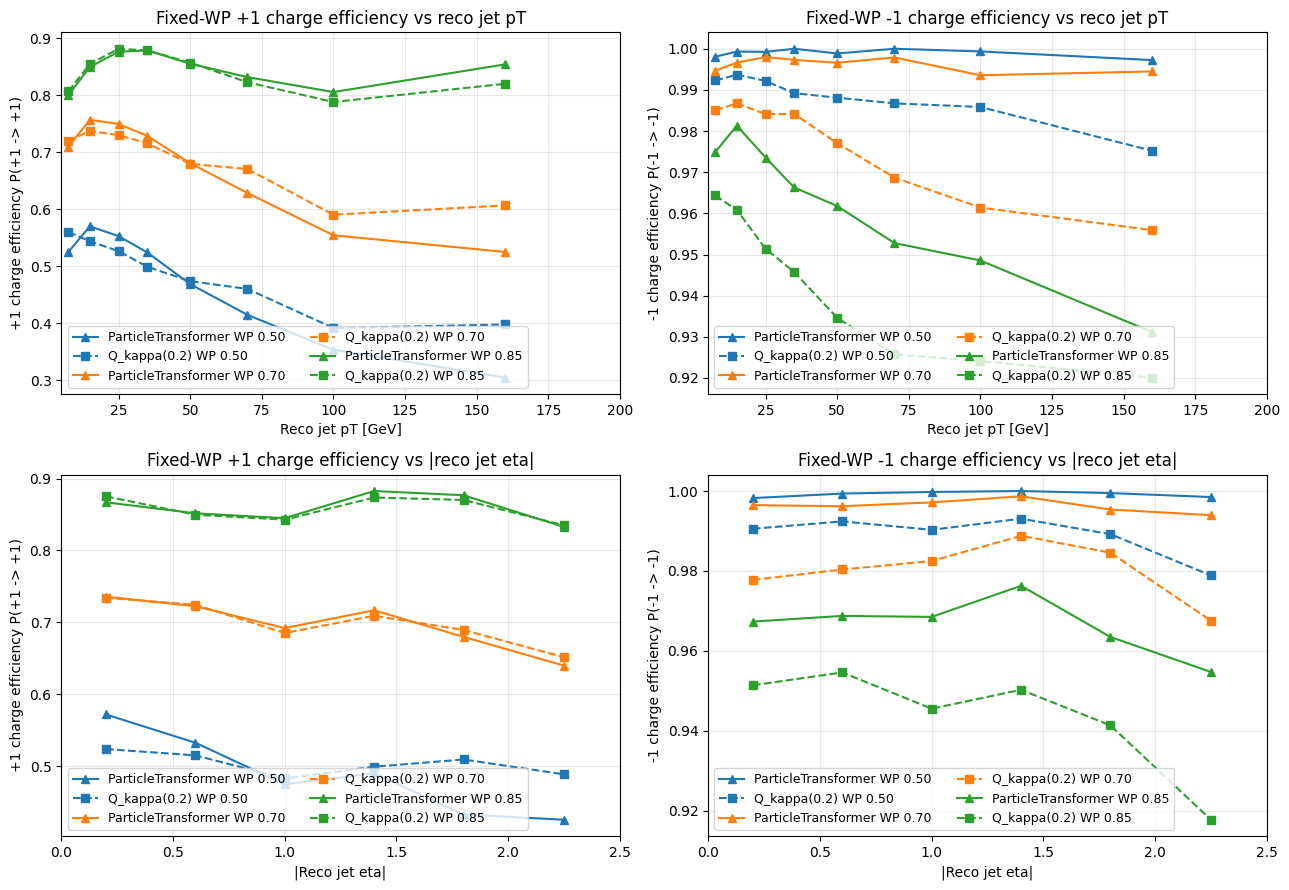

,target_pos_eff_wp,model_threshold,qkappa_0.2_threshold
0,0.50,0.996937,0.817957
1,0.70,0.972957,0.650178
2,0.85,0.632596,0.006214


In [111]:
# Multi-working-point view of the same pT / |eta| dependencies.
# Working points are defined by global +1-charge efficiency.
# Higher is better for both +1 and -1 efficiency panels.

wp_targets = [0.50, 0.70, 0.85]
wp_colors = ['tab:blue', 'tab:orange', 'tab:green']

def collect_wp_curves(y_true, score, thresholds, values, bins, wp_targets):
    curves = {}
    for wp in wp_targets:
        thr = find_threshold_for_target_pos_eff(y_true, score, thresholds, wp)
        curves[wp] = {
            'threshold': thr,
            'metrics': compute_binned_fixed_threshold_metrics(values, bins, y_true, score, thr),
        }
    return curves

model_threshold_grid = np.linspace(0.0, 1.0, 2000)
qk_threshold_grid = np.linspace(np.min(qk_best), np.max(qk_best), 2000)

pt_model_wp_curves = collect_wp_curves(target_binary, model_score, model_threshold_grid, reco_jet_pt, pt_bins, wp_targets)
pt_qk_wp_curves = collect_wp_curves(target_binary, qk_best, qk_threshold_grid, reco_jet_pt, pt_bins, wp_targets)
eta_model_wp_curves = collect_wp_curves(target_binary, model_score, model_threshold_grid, abs_reco_jet_eta, eta_bins, wp_targets)
eta_qk_wp_curves = collect_wp_curves(target_binary, qk_best, qk_threshold_grid, abs_reco_jet_eta, eta_bins, wp_targets)

fig, axes = plt.subplots(2, 2, figsize=(13.0, 9.0))

for wp, color in zip(wp_targets, wp_colors):
    axes[0, 0].plot(pt_model_wp_curves[wp]['metrics']['centers'], pt_model_wp_curves[wp]['metrics']['pos_eff'], marker='^', color=color, label=f'ParticleTransformer WP {wp:.2f}')
    axes[0, 0].plot(pt_qk_wp_curves[wp]['metrics']['centers'], pt_qk_wp_curves[wp]['metrics']['pos_eff'], marker='s', color=color, linestyle='--', label=f'Q_kappa({best_kappa_label}) WP {wp:.2f}')
    axes[0, 1].plot(pt_model_wp_curves[wp]['metrics']['centers'], pt_model_wp_curves[wp]['metrics']['neg_eff'], marker='^', color=color, label=f'ParticleTransformer WP {wp:.2f}')
    axes[0, 1].plot(pt_qk_wp_curves[wp]['metrics']['centers'], pt_qk_wp_curves[wp]['metrics']['neg_eff'], marker='s', color=color, linestyle='--', label=f'Q_kappa({best_kappa_label}) WP {wp:.2f}')
    axes[1, 0].plot(eta_model_wp_curves[wp]['metrics']['centers'], eta_model_wp_curves[wp]['metrics']['pos_eff'], marker='^', color=color, label=f'ParticleTransformer WP {wp:.2f}')
    axes[1, 0].plot(eta_qk_wp_curves[wp]['metrics']['centers'], eta_qk_wp_curves[wp]['metrics']['pos_eff'], marker='s', color=color, linestyle='--', label=f'Q_kappa({best_kappa_label}) WP {wp:.2f}')
    axes[1, 1].plot(eta_model_wp_curves[wp]['metrics']['centers'], eta_model_wp_curves[wp]['metrics']['neg_eff'], marker='^', color=color, label=f'ParticleTransformer WP {wp:.2f}')
    axes[1, 1].plot(eta_qk_wp_curves[wp]['metrics']['centers'], eta_qk_wp_curves[wp]['metrics']['neg_eff'], marker='s', color=color, linestyle='--', label=f'Q_kappa({best_kappa_label}) WP {wp:.2f}')

axes[0, 0].set_title('Fixed-WP +1 charge efficiency vs reco jet pT')
axes[0, 0].set_xlabel('Reco jet pT [GeV]')
axes[0, 0].set_ylabel('+1 charge efficiency P(+1 -> +1)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=9, ncol=2)
axes[0, 0].set_xlim(pt_bins[0], pt_bins[-1])

axes[0, 1].set_title('Fixed-WP -1 charge efficiency vs reco jet pT')
axes[0, 1].set_xlabel('Reco jet pT [GeV]')
axes[0, 1].set_ylabel('-1 charge efficiency P(-1 -> -1)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=9, ncol=2)
axes[0, 1].set_xlim(pt_bins[0], pt_bins[-1])

axes[1, 0].set_title('Fixed-WP +1 charge efficiency vs |reco jet eta|')
axes[1, 0].set_xlabel('|Reco jet eta|')
axes[1, 0].set_ylabel('+1 charge efficiency P(+1 -> +1)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=9, ncol=2)
axes[1, 0].set_xlim(eta_bins[0], eta_bins[-1])

axes[1, 1].set_title('Fixed-WP -1 charge efficiency vs |reco jet eta|')
axes[1, 1].set_xlabel('|Reco jet eta|')
axes[1, 1].set_ylabel('-1 charge efficiency P(-1 -> -1)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=9, ncol=2)
axes[1, 1].set_xlim(eta_bins[0], eta_bins[-1])

plt.tight_layout()
plt.show()

wp_threshold_summary = pd.DataFrame({
    'target_pos_eff_wp': wp_targets,
    'model_threshold': [pt_model_wp_curves[wp]['threshold'] for wp in wp_targets],
    f'qkappa_{best_kappa_label}_threshold': [pt_qk_wp_curves[wp]['threshold'] for wp in wp_targets],
})
display(wp_threshold_summary)


### mis juhtudel on raske charge'i klassifitseerida?

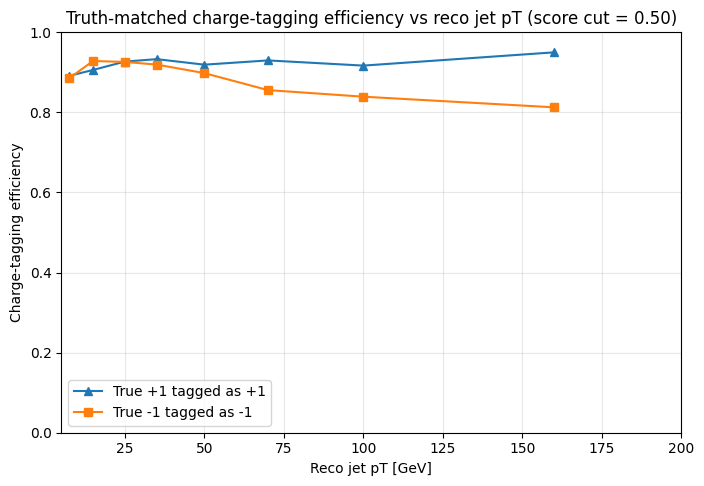

,pt_bin_low,pt_bin_high,true_pos_den,true_neg_den,eff_true_pos_to_pred_pos,eff_true_neg_to_pred_neg
0,5,10,2032,2076,0.891240,0.885356
1,10,20,4460,4443,0.906054,0.928427
2,20,30,3996,3973,0.926927,0.926001
3,30,40,2985,2967,0.932998,0.919447
4,40,60,3726,3534,0.919216,0.898132
5,60,80,1995,1885,0.929825,0.855703
6,80,120,1829,1555,0.916894,0.839228
7,120,200,440,363,0.950000,0.812672


In [112]:
# Truth-aware charge-tagging efficiency profile vs reco jet pT.
# This is evaluated on the truth-matched reco sample and split by true tau charge.
# Denominator in each bin: reco jets in that reco-pT bin with a valid matched gen tau charge.
# Numerator: those reco jets whose assigned charge is correct at the chosen score cut.

physics_score_cut = 0.50
physics_pt_bins = np.array([5, 10, 20, 30, 40, 60, 80, 120, 200])

def compute_truth_matched_charge_eff_vs_reco_pt(reco_pt, gen_charge, model_score, bins, score_cut=0.5):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pred_charge = np.where(model_score >= score_cut, 1, -1)

    eff_pos = []
    eff_neg = []
    pos_den = []
    neg_den = []

    valid_truth = np.isin(gen_charge, [-1, 1])

    for low, high in zip(bins[:-1], bins[1:]):
        bin_mask = (reco_pt >= low) & (reco_pt < high) & valid_truth

        pos_mask = bin_mask & (gen_charge == 1)
        neg_mask = bin_mask & (gen_charge == -1)

        pos_den_count = int(np.sum(pos_mask))
        neg_den_count = int(np.sum(neg_mask))
        pos_den.append(pos_den_count)
        neg_den.append(neg_den_count)

        eff_pos.append(np.mean(pred_charge[pos_mask] == 1) if pos_den_count > 0 else np.nan)
        eff_neg.append(np.mean(pred_charge[neg_mask] == -1) if neg_den_count > 0 else np.nan)

    return {
        'centers': centers,
        'eff_pos': np.array(eff_pos),
        'eff_neg': np.array(eff_neg),
        'pos_den': np.array(pos_den),
        'neg_den': np.array(neg_den),
    }

reco_jet_pt = ak.to_numpy(to_p4(data_ptcut.reco_jet_p4s).pt)
gen_tau_charge = ak.to_numpy(data_ptcut.gen_jet_tau_charge)
gen_tau_charge_signed = np.where(gen_tau_charge > 0, 1, np.where(gen_tau_charge < 0, -1, gen_tau_charge))
model_score_np = np.asarray(model_score)

physics_eff = compute_truth_matched_charge_eff_vs_reco_pt(
    reco_jet_pt,
    gen_tau_charge_signed,
    model_score_np,
    physics_pt_bins,
    score_cut=physics_score_cut,
)

plt.figure(figsize=(8.0, 5.2))
plt.plot(physics_eff['centers'], physics_eff['eff_pos'], marker='^', label='True +1 tagged as +1')
plt.plot(physics_eff['centers'], physics_eff['eff_neg'], marker='s', label='True -1 tagged as -1')
plt.xlabel('Reco jet pT [GeV]')
plt.ylabel('Charge-tagging efficiency')
plt.title(f'Truth-matched charge-tagging efficiency vs reco jet pT (score cut = {physics_score_cut:.2f})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(physics_pt_bins[0], physics_pt_bins[-1])
plt.ylim(0.0, 1.0)
plt.show()

physics_eff_table = pd.DataFrame({
    'pt_bin_low': physics_pt_bins[:-1],
    'pt_bin_high': physics_pt_bins[1:],
    'true_pos_den': physics_eff['pos_den'],
    'true_neg_den': physics_eff['neg_den'],
    'eff_true_pos_to_pred_pos': physics_eff['eff_pos'],
    'eff_true_neg_to_pred_neg': physics_eff['eff_neg'],
})
display(physics_eff_table)


In [113]:
# Explicit formula summary for the truth-matched reco-level charge-tagging plot.
print('Current reco-level truth-matched charge-tagging efficiency definitions:')
print()
print('For the +1 line in a reco-pT bin:')
print('  numerator   = N(reco jets in bin, matched to true +1 tau, predicted +1)')
print('  denominator = N(reco jets in bin, matched to true +1 tau)')
print('  efficiency  = numerator / denominator')
print()
print('For the -1 line in a reco-pT bin:')
print('  numerator   = N(reco jets in bin, matched to true -1 tau, predicted -1)')
print('  denominator = N(reco jets in bin, matched to true -1 tau)')
print('  efficiency  = numerator / denominator')
print()
print('With the current score cut:')
print(f'  predicted +1 if score >= {physics_score_cut:.2f}')
print(f'  predicted -1 if score <  {physics_score_cut:.2f}')
print()
print('Important limitation: this is NOT a full gen-denominator physics efficiency.')
print('It only uses reco jets that already exist in the parquet and have a valid matched gen charge.')
print('A true end-to-end physics efficiency would need all fiducial gen taus in the denominator,')
print('including gen taus that failed reconstruction or selection.')


Current reco-level truth-matched charge-tagging efficiency definitions:

For the +1 line in a reco-pT bin:
  numerator   = N(reco jets in bin, matched to true +1 tau, predicted +1)
  denominator = N(reco jets in bin, matched to true +1 tau)
  efficiency  = numerator / denominator

For the -1 line in a reco-pT bin:
  numerator   = N(reco jets in bin, matched to true -1 tau, predicted -1)
  denominator = N(reco jets in bin, matched to true -1 tau)
  efficiency  = numerator / denominator

With the current score cut:
  predicted +1 if score >= 0.50
  predicted -1 if score <  0.50

Important limitation: this is NOT a full gen-denominator physics efficiency.
It only uses reco jets that already exist in the parquet and have a valid matched gen charge.
A true end-to-end physics efficiency would need all fiducial gen taus in the denominator,
including gen taus that failed reconstruction or selection.


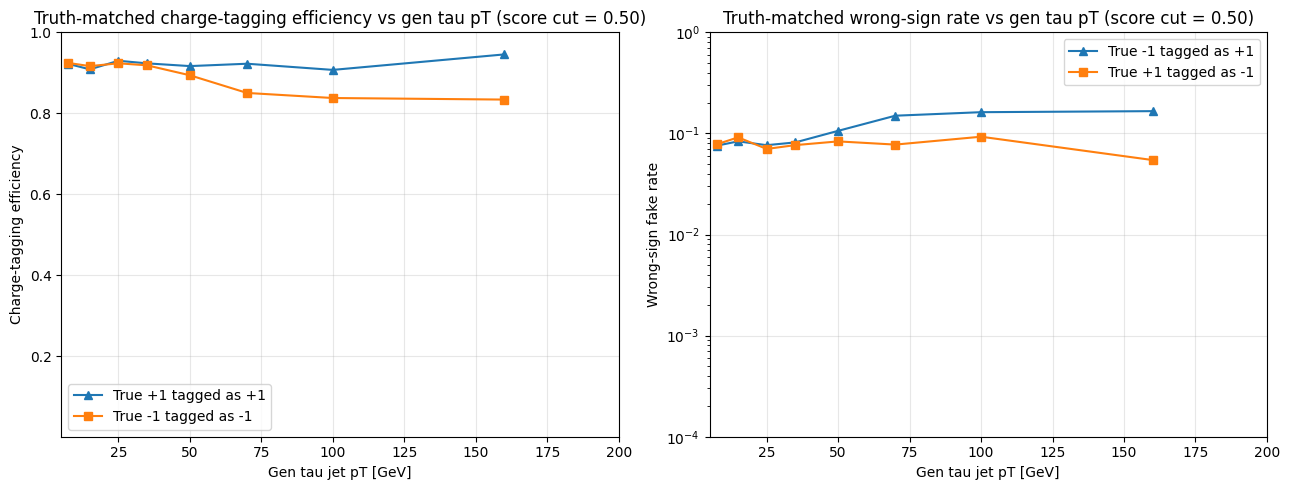

,gen_pt_bin_low,gen_pt_bin_high,true_pos_den,true_neg_den,eff_true_pos_to_pred_pos,eff_true_neg_to_pred_neg,fake_true_neg_to_pred_pos,fake_true_pos_to_pred_neg
0,5,10,2012,1970,0.921968,0.924365,0.075635,0.078032
1,10,20,4834,4672,0.908564,0.916524,0.083476,0.091436
2,20,30,4142,4064,0.929744,0.923474,0.076526,0.070256
3,30,40,3066,3006,0.923353,0.918496,0.081504,0.076647
4,40,60,3597,3422,0.916597,0.893922,0.106078,0.083403
5,60,80,1831,1803,0.922447,0.850250,0.149750,0.077553
6,80,120,1541,1473,0.907203,0.837746,0.162254,0.092797
7,120,200,330,301,0.945455,0.833887,0.166113,0.054545


In [114]:
# Truth-matched charge-tagging efficiency and wrong-sign fake rate vs gen tau pT.
# This uses the matched sample available in the parquet, but gen tau pT is the more natural x-axis
# for a physics-style view than reco jet pT.

gen_pt_score_cut = 0.50
gen_pt_bins = np.array([5, 10, 20, 30, 40, 60, 80, 120, 200])

def compute_truth_matched_charge_metrics_vs_gen_pt(gen_tau_pt, gen_charge, model_score, bins, score_cut=0.5):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pred_charge = np.where(model_score >= score_cut, 1, -1)
    valid_truth = np.isin(gen_charge, [-1, 1])

    eff_pos = []
    eff_neg = []
    fake_pos_from_neg = []
    fake_neg_from_pos = []
    pos_den = []
    neg_den = []

    for low, high in zip(bins[:-1], bins[1:]):
        bin_mask = (gen_tau_pt >= low) & (gen_tau_pt < high) & valid_truth
        pos_mask = bin_mask & (gen_charge == 1)
        neg_mask = bin_mask & (gen_charge == -1)

        pos_den_count = int(np.sum(pos_mask))
        neg_den_count = int(np.sum(neg_mask))
        pos_den.append(pos_den_count)
        neg_den.append(neg_den_count)

        eff_pos.append(np.mean(pred_charge[pos_mask] == 1) if pos_den_count > 0 else np.nan)
        eff_neg.append(np.mean(pred_charge[neg_mask] == -1) if neg_den_count > 0 else np.nan)
        fake_pos_from_neg.append(np.mean(pred_charge[neg_mask] == 1) if neg_den_count > 0 else np.nan)
        fake_neg_from_pos.append(np.mean(pred_charge[pos_mask] == -1) if pos_den_count > 0 else np.nan)

    return {
        'centers': centers,
        'eff_pos': np.array(eff_pos),
        'eff_neg': np.array(eff_neg),
        'fake_pos_from_neg': np.array(fake_pos_from_neg),
        'fake_neg_from_pos': np.array(fake_neg_from_pos),
        'pos_den': np.array(pos_den),
        'neg_den': np.array(neg_den),
    }

gen_tau_pt = ak.to_numpy(to_p4(data_ptcut.gen_jet_tau_p4s).pt)
gen_tau_charge = ak.to_numpy(data_ptcut.gen_jet_tau_charge)
gen_tau_charge_signed = np.where(gen_tau_charge > 0, 1, np.where(gen_tau_charge < 0, -1, gen_tau_charge))
model_score_np = np.asarray(model_score)

gen_pt_metrics = compute_truth_matched_charge_metrics_vs_gen_pt(
    gen_tau_pt,
    gen_tau_charge_signed,
    model_score_np,
    gen_pt_bins,
    score_cut=gen_pt_score_cut,
)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), sharex=True)
axes[0].plot(gen_pt_metrics['centers'], gen_pt_metrics['eff_pos'], marker='^', label='True +1 tagged as +1')
axes[0].plot(gen_pt_metrics['centers'], gen_pt_metrics['eff_neg'], marker='s', label='True -1 tagged as -1')
axes[0].set_xlabel('Gen tau jet pT [GeV]')
axes[0].set_ylabel('Charge-tagging efficiency')
axes[0].set_title(f'Truth-matched charge-tagging efficiency vs gen tau pT (score cut = {gen_pt_score_cut:.2f})')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xlim(gen_pt_bins[0], gen_pt_bins[-1])
# axes[0].set_yscale('log')
axes[0].set_ylim(1e-3, 1.0)

axes[1].plot(gen_pt_metrics['centers'], gen_pt_metrics['fake_pos_from_neg'], marker='^', label='True -1 tagged as +1')
axes[1].plot(gen_pt_metrics['centers'], gen_pt_metrics['fake_neg_from_pos'], marker='s', label='True +1 tagged as -1')
axes[1].set_xlabel('Gen tau jet pT [GeV]')
axes[1].set_ylabel('Wrong-sign fake rate')
axes[1].set_title(f'Truth-matched wrong-sign rate vs gen tau pT (score cut = {gen_pt_score_cut:.2f})')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xlim(gen_pt_bins[0], gen_pt_bins[-1])
axes[1].set_yscale('log')
axes[1].set_ylim(1e-4, 1.0)

plt.tight_layout()
plt.show()

gen_pt_metrics_table = pd.DataFrame({
    'gen_pt_bin_low': gen_pt_bins[:-1],
    'gen_pt_bin_high': gen_pt_bins[1:],
    'true_pos_den': gen_pt_metrics['pos_den'],
    'true_neg_den': gen_pt_metrics['neg_den'],
    'eff_true_pos_to_pred_pos': gen_pt_metrics['eff_pos'],
    'eff_true_neg_to_pred_neg': gen_pt_metrics['eff_neg'],
    'fake_true_neg_to_pred_pos': gen_pt_metrics['fake_pos_from_neg'],
    'fake_true_pos_to_pred_neg': gen_pt_metrics['fake_neg_from_pos'],
})
display(gen_pt_metrics_table)


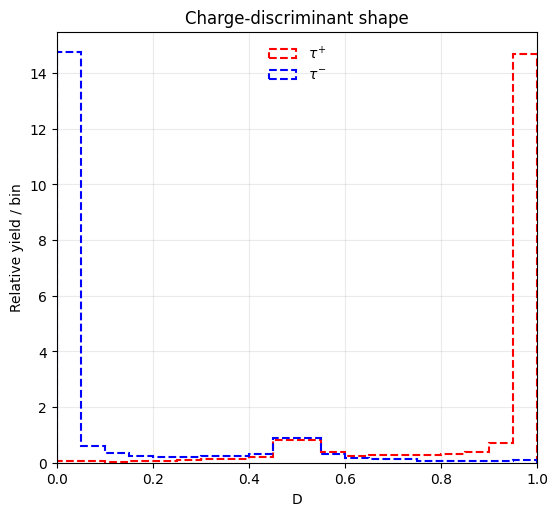

In [115]:
# Charge-discriminant shape D for true tau+ and tau-.
# Here D is the raw classifier score in [0, 1].

D = np.asarray(model_score)
true_charge_signed = np.where(np.asarray(target) == 1, 1, -1)
bins_D = np.linspace(0.0, 1.0, 21)

plt.figure(figsize=(6.2, 5.6))
plt.hist(D[true_charge_signed == 1], bins=bins_D, density=True, histtype='step', linestyle='--', linewidth=1.5, color='red', label=r'$\tau^{+}$')
plt.hist(D[true_charge_signed == -1], bins=bins_D, density=True, histtype='step', linestyle='--', linewidth=1.5, color='blue', label=r'$\tau^{-}$')
plt.xlabel('D')
plt.ylabel('Relative yield / bin')
plt.title('Charge-discriminant shape')
# plt.yscale('log')
plt.grid(True, alpha=0.25)
plt.legend(loc='upper center', frameon=False)
plt.xlim(0.0, 1.0)
plt.show()


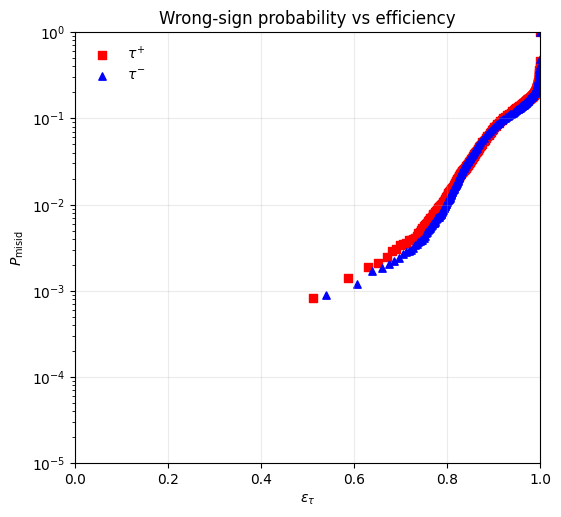

In [116]:
# Wrong-sign misidentification probability vs signal efficiency for tau+ and tau-.
# tau+ branch: classify as +1 for D >= threshold
# tau- branch: classify as -1 for D < threshold

D = np.asarray(model_score)
true_charge_signed = np.where(np.asarray(target) == 1, 1, -1)
thresholds_D = np.linspace(0.0, 1.0, 300)

eps_tau_pos = []
pmisid_pos = []
eps_tau_neg = []
pmisid_neg = []

pos_mask = true_charge_signed == 1
neg_mask = true_charge_signed == -1

for thr in thresholds_D:
    pred_pos = D >= thr
    pred_neg = D < thr

    eps_tau_pos.append(np.mean(pred_pos[pos_mask]))
    pmisid_pos.append(np.mean(pred_pos[neg_mask]))

    eps_tau_neg.append(np.mean(pred_neg[neg_mask]))
    pmisid_neg.append(np.mean(pred_neg[pos_mask]))

eps_tau_pos = np.array(eps_tau_pos)
pmisid_pos = np.array(pmisid_pos)
eps_tau_neg = np.array(eps_tau_neg)
pmisid_neg = np.array(pmisid_neg)

plt.figure(figsize=(6.0, 5.6))
plt.scatter(eps_tau_pos, pmisid_pos, s=28, marker='s', color='red', label=r'$\tau^{+}$')
plt.scatter(eps_tau_neg, pmisid_neg, s=28, marker='^', color='blue', label=r'$\tau^{-}$')
plt.xlabel(r'$\epsilon_{\tau}$')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title('Wrong-sign probability vs efficiency')
plt.yscale('log')
plt.grid(True, alpha=0.25)
plt.legend(loc='upper left', frameon=False)
plt.xlim(0.0, 1.0)
plt.ylim(1e-5, 1.0)
plt.show()


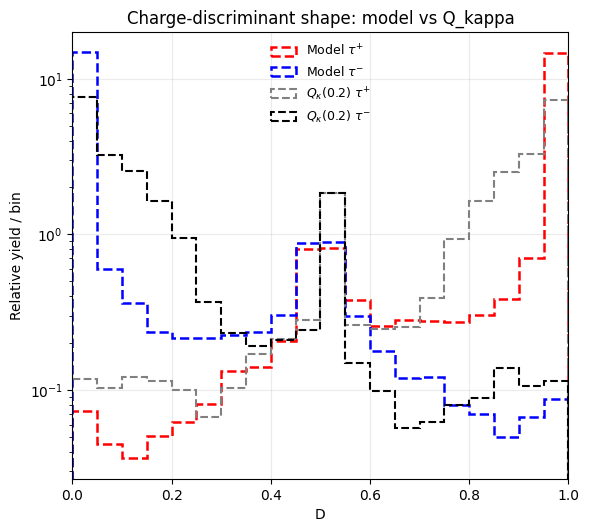

In [117]:
# Charge-discriminant shape D for true tau+ and tau-, with Q_kappa(0.2) baseline overlay.
# For the baseline we reuse the notebook's raw mapping D_qk = clip(0.5 * (Q_kappa + 1), 0, 1).

D_model = np.asarray(model_score)
D_qk = np.clip(0.5 * (np.asarray(qk_best) + 1.0), 0.0, 1.0)
true_charge_signed = np.where(np.asarray(target) == 1, 1, -1)
bins_D = np.linspace(0.0, 1.0, 21)

plt.figure(figsize=(6.4, 5.8))
plt.hist(D_model[true_charge_signed == 1], bins=bins_D, density=True, histtype='step', linestyle='--', linewidth=1.8, color='red', label=r'Model $\tau^{+}$')
plt.hist(D_model[true_charge_signed == -1], bins=bins_D, density=True, histtype='step', linestyle='--', linewidth=1.8, color='blue', label=r'Model $\tau^{-}$')
plt.hist(D_qk[true_charge_signed == 1], bins=bins_D, density=True, histtype='step', linestyle='--', linewidth=1.5, color='grey', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
plt.hist(D_qk[true_charge_signed == -1], bins=bins_D, density=True, histtype='step', linestyle='--', linewidth=1.5, color='black', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel('D')
plt.ylabel('Relative yield / bin')
plt.title('Charge-discriminant shape: model vs Q_kappa')
plt.yscale('log')
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, fontsize=9)
plt.xlim(0.0, 1.0)
plt.show()


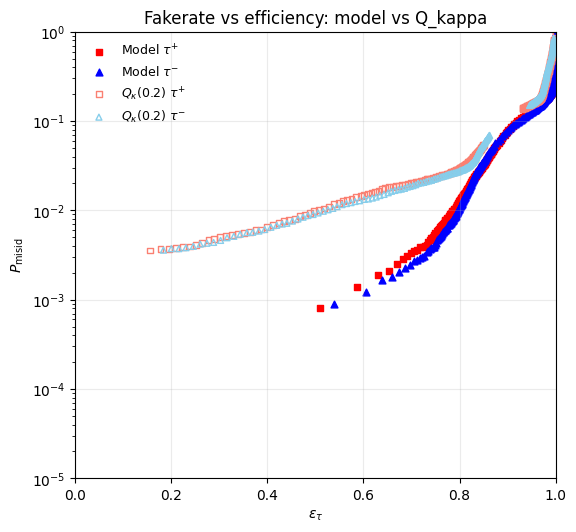

In [118]:
# Wrong-sign misidentification probability vs signal efficiency for tau+ and tau-,
# with ParticleTransformer and Q_kappa(0.2) overlaid on the same D in [0, 1] scale.

D_model = np.asarray(model_score)
D_qk = np.clip(0.5 * (np.asarray(qk_best) + 1.0), 0.0, 1.0)
true_charge_signed = np.where(np.asarray(target) == 1, 1, -1)
thresholds_D = np.linspace(0.0, 1.0, 300)

def compute_misid_vs_efficiency(D, true_charge_signed, thresholds):
    pos_mask = true_charge_signed == 1
    neg_mask = true_charge_signed == -1
    eps_tau_pos = []
    pmisid_pos = []
    eps_tau_neg = []
    pmisid_neg = []

    for thr in thresholds:
        pred_pos = D >= thr
        pred_neg = 1-D > thr
        eps_tau_pos.append(np.mean(pred_pos[pos_mask]))
        pmisid_pos.append(np.mean(pred_pos[neg_mask]))
        eps_tau_neg.append(np.mean(pred_neg[neg_mask]))
        pmisid_neg.append(np.mean(pred_neg[pos_mask]))

    return {
        'eps_tau_pos': np.array(eps_tau_pos),
        'pmisid_pos': np.array(pmisid_pos),
        'eps_tau_neg': np.array(eps_tau_neg),
        'pmisid_neg': np.array(pmisid_neg),
    }

curves_model = compute_misid_vs_efficiency(D_model, true_charge_signed, thresholds_D)
curves_qk = compute_misid_vs_efficiency(D_qk, true_charge_signed, thresholds_D)

plt.figure(figsize=(6.2, 5.8))
plt.scatter(curves_model['eps_tau_pos'], curves_model['pmisid_pos'], s=24, marker='s', color='red', label=r'Model $\tau^{+}$')
plt.scatter(curves_model['eps_tau_neg'], curves_model['pmisid_neg'], s=24, marker='^', color='blue', label=r'Model $\tau^{-}$')
plt.scatter(curves_qk['eps_tau_pos'], curves_qk['pmisid_pos'], s=18, marker='s', facecolors='none', edgecolors='salmon', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
plt.scatter(curves_qk['eps_tau_neg'], curves_qk['pmisid_neg'], s=18, marker='^', facecolors='none', edgecolors='skyblue', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel(r'$\epsilon_{\tau}$')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title('Fakerate vs efficiency: model vs Q_kappa')
plt.yscale('log')
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, fontsize=9)
plt.xlim(0.0, 1.0)
plt.ylim(1e-5, 1.0)
plt.show()

In [119]:
# Table of operating points for the fakerate-vs-efficiency plot.
# We quote the wrong-sign misidentification rate and its inverse at selected efficiencies.

target_eps_values = np.array([0.50, 0.60, 0.70, 0.80, 0.90])

def interpolate_metric_at_efficiency(eps_curve, metric_curve, target_eps_values):
    order = np.argsort(eps_curve)
    eps_sorted = eps_curve[order]
    metric_sorted = metric_curve[order]

    eps_unique, unique_idx = np.unique(eps_sorted, return_index=True)
    metric_unique = metric_sorted[unique_idx]

    metric_at_targets = np.interp(
        target_eps_values,
        eps_unique,
        metric_unique,
        left=np.nan,
        right=np.nan,
    )
    inv_metric_at_targets = np.divide(
        1.0,
        metric_at_targets,
        out=np.full_like(metric_at_targets, np.nan, dtype=float),
        where=metric_at_targets > 0,
    )
    return metric_at_targets, inv_metric_at_targets

rows = []
curve_specs = [
    ('ParticleTransformer', r'$\\tau^{+}$', curves_model['eps_tau_pos'], curves_model['pmisid_pos']),
    ('ParticleTransformer', r'$\\tau^{-}$', curves_model['eps_tau_neg'], curves_model['pmisid_neg']),
    (f'Q_kappa({best_kappa_label})', r'$\\tau^{+}$', curves_qk['eps_tau_pos'], curves_qk['pmisid_pos']),
    (f'Q_kappa({best_kappa_label})', r'$\\tau^{-}$', curves_qk['eps_tau_neg'], curves_qk['pmisid_neg']),
]

for algorithm, charge_label, eps_curve, pmisid_curve in curve_specs:
    pmisid_vals, inv_pmisid_vals = interpolate_metric_at_efficiency(eps_curve, pmisid_curve, target_eps_values)
    row = {
        'Algorithm': algorithm,
        'Charge': charge_label,
    }
    for eps_target, pmisid_val, inv_pmisid_val in zip(target_eps_values, pmisid_vals, inv_pmisid_vals):
        row[f'Pmisid @ eps={eps_target:.0%}'] = pmisid_val
        row[f'1/Pmisid @ eps={eps_target:.0%}'] = inv_pmisid_val
    rows.append(row)

fakerate_operating_points_table = pd.DataFrame(rows)
display(fakerate_operating_points_table)


,Algorithm,Charge,Pmisid @ eps=50%,1/Pmisid @ eps=50%,Pmisid @ eps=60%,1/Pmisid @ eps=60%,Pmisid @ eps=70%,1/Pmisid @ eps=70%,Pmisid @ eps=80%,1/Pmisid @ eps=80%,Pmisid @ eps=90%,1/Pmisid @ eps=90%
0,ParticleTransformer,$\\tau^{+}$,0.000801,1249.183813,0.001549,645.387177,0.003386,295.328972,0.012689,78.808458,0.076652,13.045955
1,ParticleTransformer,$\\tau^{-}$,0.000822,1217.019723,0.001186,843.295749,0.002528,395.503537,0.010908,91.673624,0.079536,12.572883
2,Q_kappa(0.2),$\\tau^{+}$,0.009918,100.825597,0.014682,68.110714,0.020104,49.741043,0.029442,33.964687,0.105455,9.482748
3,Q_kappa(0.2),$\\tau^{-}$,0.009166,109.097478,0.013192,75.801703,0.018721,53.414650,0.027540,36.311161,0.105270,9.499410


In [120]:
# Load the trained charge-classification models with their available test samples.
# ZZ+ZH-trained model: zz_test + zh_test
# ZZ-only-trained model: zz_test

model_runs_compare = {
    'ZZ+ZH': {
        'model_dir': '/home/norman/ml-tau/ml-tau-en-reg/training-outputs/260318_charge_classification_e150/charge_classification/ParticleTransformer',
        'raw_test_dir': '/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206_365',
        'sample_names': ['zz_test.parquet', 'zh_test.parquet'],
    },
    'ZZ': {
        'model_dir': '/home/norman/ml-tau/ml-tau-en-reg/training-outputs/260318_charge_classification_e150_ZZ/charge_classification/ParticleTransformer',
        'raw_test_dir': '/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206_365',
        'sample_names': ['zz_test.parquet'],
    },
}
compare_pt_cut = 5.0

def load_model_outputs_across_samples(model_dir, sample_names):
    preds_all = []
    targets_all = []
    loaded = []
    for sample_name in sample_names:
        sample_path = f'{model_dir}/{sample_name}'
        result = ak.from_parquet(sample_path)
        preds_all.append(np.asarray(result.charge_classification.pred))
        targets_all.append(np.asarray(result.charge_classification.target))
        loaded.append(sample_name)
    return {
        'pred': np.concatenate(preds_all),
        'target': np.concatenate(targets_all),
        'samples': loaded,
    }

def load_raw_eval_sample_across_samples(raw_dir, sample_names, pt_cut=5.0):
    chunks = []
    for sample_name in sample_names:
        raw_sample = ak.from_parquet(f'{raw_dir}/{sample_name}')
        mask = to_p4(raw_sample.reco_jet_p4s).pt > pt_cut
        chunks.append(raw_sample[mask])
    return ak.concatenate(chunks, axis=0)

compare_results = {}
compare_raw_data = {}
compare_qk = {}
compare_D_qk = {}
compare_true_charge_signed = {}

for label, run_cfg in model_runs_compare.items():
    sample_names = run_cfg['sample_names']
    payload = load_model_outputs_across_samples(run_cfg['model_dir'], sample_names)
    raw_data = load_raw_eval_sample_across_samples(run_cfg['raw_test_dir'], sample_names, pt_cut=compare_pt_cut)

    if len(payload['pred']) != len(raw_data):
        raise ValueError(
            f'Length mismatch for {label}: model outputs have {len(payload["pred"])} jets but raw sample has {len(raw_data)}'
        )

    compare_results[label] = payload
    compare_raw_data[label] = raw_data
    compare_true_charge_signed[label] = np.where(payload['target'] == 1, 1, -1)

    pf_charges = raw_data.reco_cand_charge
    pf_pts = to_p4(raw_data.reco_cand_p4s).pt
    jet_pts = to_p4(raw_data.reco_jet_p4s).pt
    qk = jet_charge_qkappa(pf_charges, pf_pts, jet_pts, kappa=best_kappa)
    compare_qk[label] = qk
    compare_D_qk[label] = np.clip(0.5 * (qk + 1.0), 0.0, 1.0)

display(pd.DataFrame({
    'model': list(compare_results.keys()),
    'samples': [', '.join(compare_results[label]['samples']) for label in compare_results],
    'n_jets': [len(compare_results[label]['pred']) for label in compare_results],
}))


,model,samples,n_jets
0,ZZ+ZH,"zz_test.parquet, zh_test.parquet",68510
1,ZZ,zz_test.parquet,42276


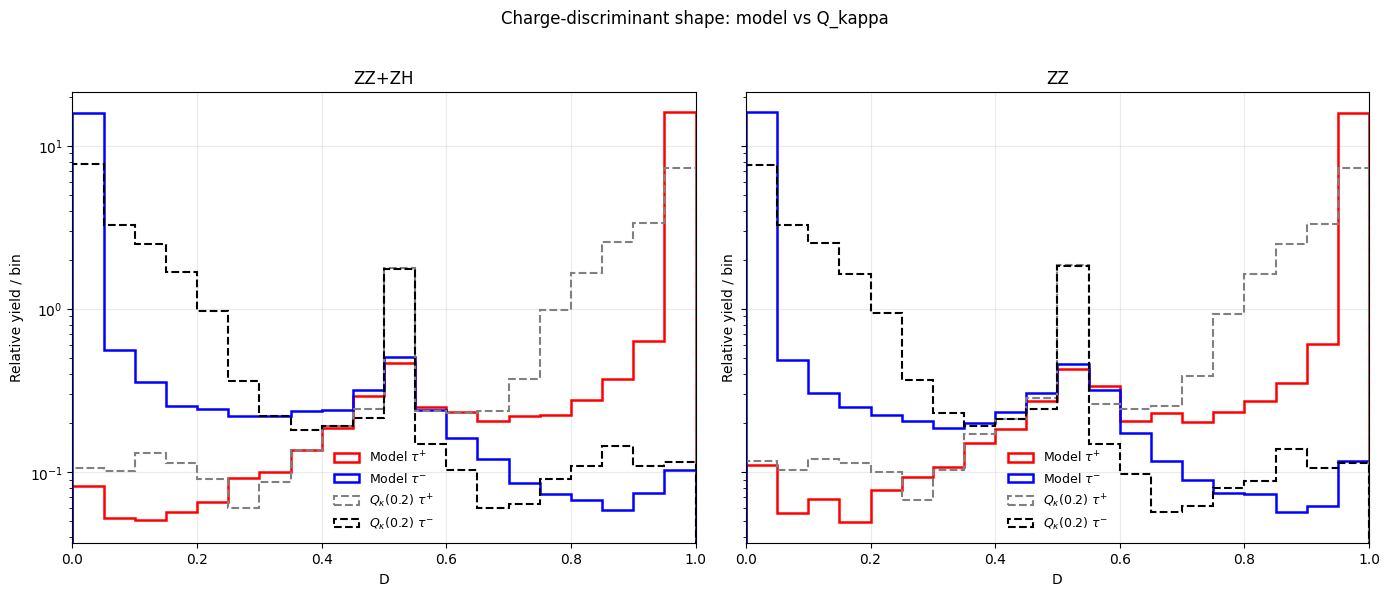

In [121]:
# Charge-discriminant shape D for each trained model, each compared to its matching Q_kappa baseline.

bins_D_compare = np.linspace(0.0, 1.0, 21)
fig, axes = plt.subplots(1, len(compare_results), figsize=(7.0 * len(compare_results), 5.8), sharey=True)
axes = np.atleast_1d(axes)

for ax, (label, payload) in zip(axes, compare_results.items()):
    D_model = np.asarray(payload['pred'])
    D_qk = compare_D_qk[label]
    true_charge = compare_true_charge_signed[label]

    ax.hist(D_model[true_charge == 1], bins=bins_D_compare, density=True, histtype='step', linestyle='-', linewidth=1.8, color='red', label=r'Model $\tau^{+}$')
    ax.hist(D_model[true_charge == -1], bins=bins_D_compare, density=True, histtype='step', linestyle='-', linewidth=1.8, color='blue', label=r'Model $\tau^{-}$')
    ax.hist(D_qk[true_charge == 1], bins=bins_D_compare, density=True, histtype='step', linestyle='--', linewidth=1.5, color='grey', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
    ax.hist(D_qk[true_charge == -1], bins=bins_D_compare, density=True, histtype='step', linestyle='--', linewidth=1.5, color='black', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
    ax.set_xlabel('D')
    ax.set_ylabel('Relative yield / bin')
    ax.set_title(label)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=9)
    ax.set_xlim(0.0, 1.0)

fig.suptitle('Charge-discriminant shape: model vs Q_kappa', y=1.02)
plt.tight_layout()
plt.show()


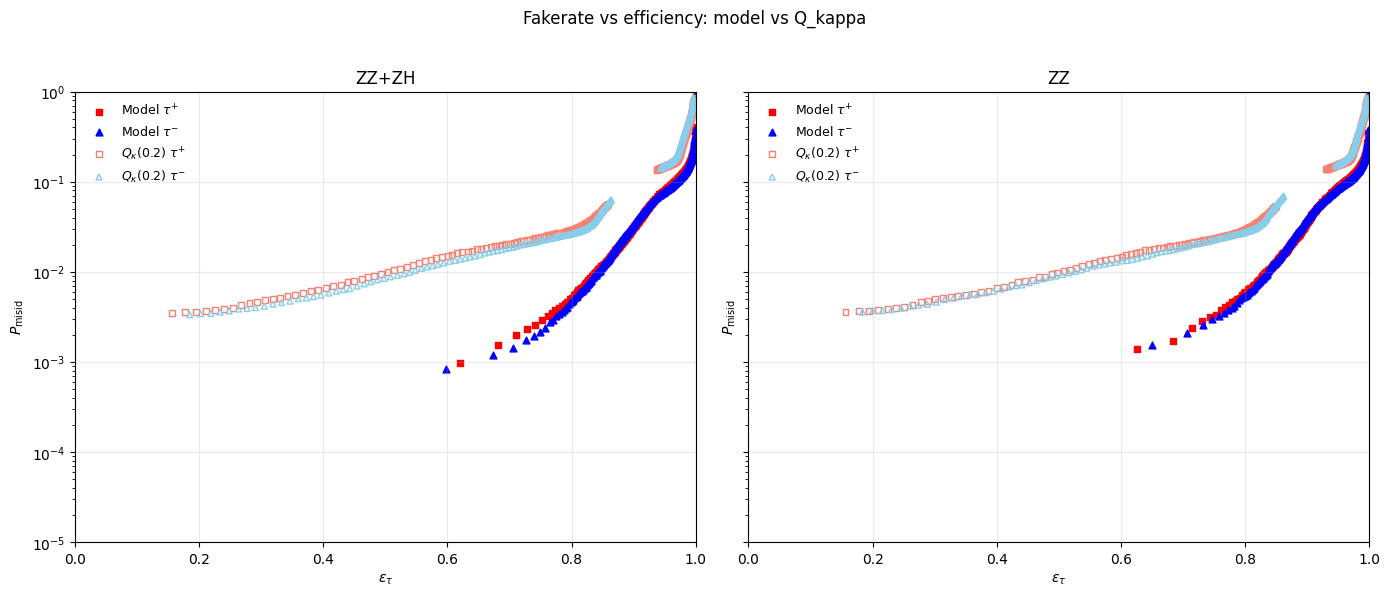

In [122]:
# Wrong-sign misidentification probability vs efficiency for each trained model,
# each compared to its matching Q_kappa baseline.

thresholds_D_compare = np.linspace(0.0, 1.0, 300)
fig, axes = plt.subplots(1, len(compare_results), figsize=(7.0 * len(compare_results), 5.8), sharey=True)
axes = np.atleast_1d(axes)

for ax, (label, payload) in zip(axes, compare_results.items()):
    true_charge = compare_true_charge_signed[label]
    curves_model = compute_misid_vs_efficiency(np.asarray(payload['pred']), true_charge, thresholds_D_compare)
    curves_qk = compute_misid_vs_efficiency(compare_D_qk[label], true_charge, thresholds_D_compare)

    ax.scatter(curves_model['eps_tau_pos'], curves_model['pmisid_pos'], s=24, marker='s', color='red', label=r'Model $\tau^{+}$')
    ax.scatter(curves_model['eps_tau_neg'], curves_model['pmisid_neg'], s=24, marker='^', color='blue', label=r'Model $\tau^{-}$')
    ax.scatter(curves_qk['eps_tau_pos'], curves_qk['pmisid_pos'], s=18, marker='s', facecolors='none', edgecolors='salmon', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
    ax.scatter(curves_qk['eps_tau_neg'], curves_qk['pmisid_neg'], s=18, marker='^', facecolors='none', edgecolors='skyblue', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
    ax.set_xlabel(r'$\epsilon_{\tau}$')
    ax.set_ylabel(r'$P_{\mathrm{misid}}$')
    ax.set_title(label)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=9)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(1e-5, 1.0)

fig.suptitle('Fakerate vs efficiency: model vs Q_kappa', y=1.02)
plt.tight_layout()
plt.show()


In [123]:
# Truth-matched charge-tagging efficiency vs gen tau pT for the newer ZZ-only and ZZ+ZH-trained models.
# This mirrors the older notebook plot and uses a fixed score cut of 0.5.

compare_gen_pt_score_cut = 0.50
compare_gen_pt_bins = np.array([5, 10, 20, 30, 40, 60, 80, 120, 200])

def compute_truth_matched_charge_metrics_vs_gen_pt_compare(gen_tau_pt, true_charge_signed, model_score, bins, score_cut=0.5):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pred_charge = np.where(model_score >= score_cut, 1, -1)

    eff_pos = []
    eff_neg = []
    fake_pos_from_neg = []
    fake_neg_from_pos = []
    pos_den = []
    neg_den = []

    for low, high in zip(bins[:-1], bins[1:]):
        bin_mask = (gen_tau_pt >= low) & (gen_tau_pt < high)
        pos_mask = bin_mask & (true_charge_signed == 1)
        neg_mask = bin_mask & (true_charge_signed == -1)

        pos_den_count = int(np.sum(pos_mask))
        neg_den_count = int(np.sum(neg_mask))
        pos_den.append(pos_den_count)
        neg_den.append(neg_den_count)

        eff_pos.append(np.mean(pred_charge[pos_mask] == 1) if pos_den_count > 0 else np.nan)
        eff_neg.append(np.mean(pred_charge[neg_mask] == -1) if neg_den_count > 0 else np.nan)
        fake_pos_from_neg.append(np.mean(pred_charge[neg_mask] == 1) if neg_den_count > 0 else np.nan)
        fake_neg_from_pos.append(np.mean(pred_charge[pos_mask] == -1) if pos_den_count > 0 else np.nan)

    return {
        'centers': centers,
        'eff_pos': np.array(eff_pos),
        'eff_neg': np.array(eff_neg),
        'fake_pos_from_neg': np.array(fake_pos_from_neg),
        'fake_neg_from_pos': np.array(fake_neg_from_pos),
        'pos_den': np.array(pos_den),
        'neg_den': np.array(neg_den),
    }


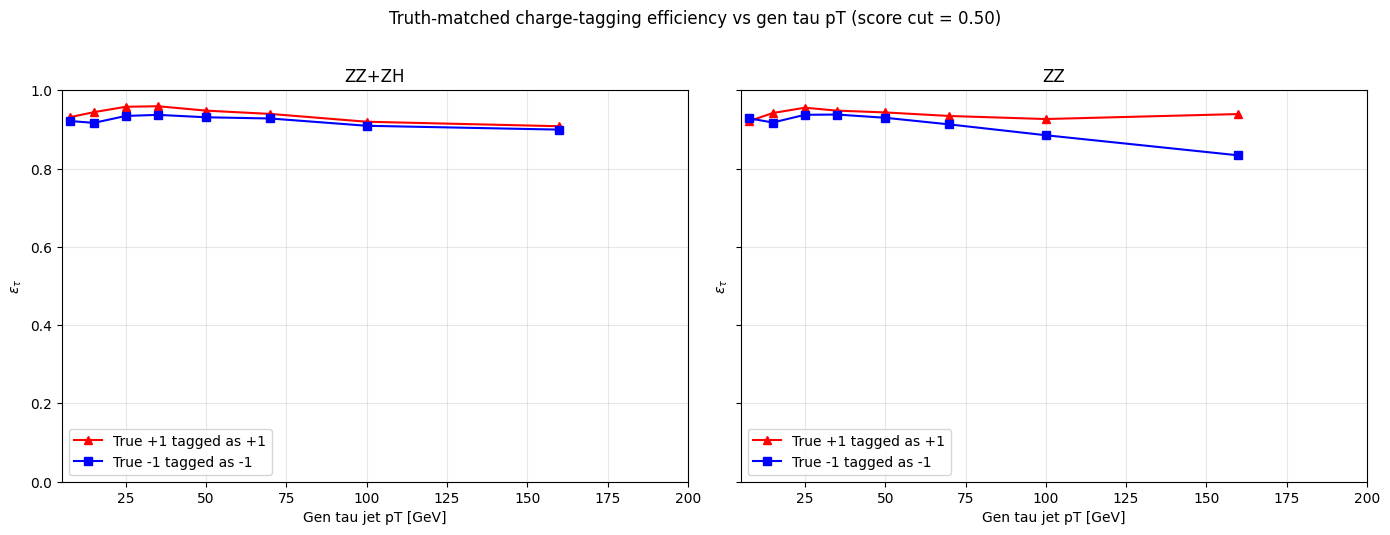

In [124]:
fig, axes = plt.subplots(1, len(compare_results), figsize=(7.0 * len(compare_results), 5.2), sharey=True)
axes = np.atleast_1d(axes)
compare_gen_pt_metrics = {}

for ax, (label, payload) in zip(axes, compare_results.items()):
    raw_data = compare_raw_data[label]
    gen_tau_pt_values = ak.to_numpy(to_p4(raw_data.gen_jet_tau_p4s).pt)
    true_charge_signed = compare_true_charge_signed[label]
    model_score_values = np.asarray(payload['pred'])

    metrics = compute_truth_matched_charge_metrics_vs_gen_pt_compare(
        gen_tau_pt=gen_tau_pt_values,
        true_charge_signed=true_charge_signed,
        model_score=model_score_values,
        bins=compare_gen_pt_bins,
        score_cut=compare_gen_pt_score_cut,
    )
    compare_gen_pt_metrics[label] = metrics

    ax.plot(metrics['centers'], metrics['eff_pos'], marker='^', label='True +1 tagged as +1', color='red')
    ax.plot(metrics['centers'], metrics['eff_neg'], marker='s', label='True -1 tagged as -1', color='blue')
    ax.set_xlabel('Gen tau jet pT [GeV]')
    ax.set_ylabel(r'$\epsilon_{\tau}$')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(compare_gen_pt_bins[0], compare_gen_pt_bins[-1])
    ax.set_ylim(0.0, 1.0)

fig.suptitle(f'Truth-matched charge-tagging efficiency vs gen tau pT (score cut = {compare_gen_pt_score_cut:.2f})', y=1.02)
plt.tight_layout()
plt.show()


In [125]:
# compare_gen_pt_tables = []
# for label, metrics in compare_gen_pt_metrics.items():
#     compare_gen_pt_tables.append(pd.DataFrame({
#         'model': label,
#         'gen_pt_bin_low': compare_gen_pt_bins[:-1],
#         'gen_pt_bin_high': compare_gen_pt_bins[1:],
#         'true_pos_den': metrics['pos_den'],
#         'true_neg_den': metrics['neg_den'],
#         'eff_true_pos_to_pred_pos': metrics['eff_pos'],
#         'eff_true_neg_to_pred_neg': metrics['eff_neg'],
#         'fake_true_neg_to_pred_pos': metrics['fake_pos_from_neg'],
#         'fake_true_pos_to_pred_neg': metrics['fake_neg_from_pos'],
#     }))

# display(pd.concat(compare_gen_pt_tables, ignore_index=True))


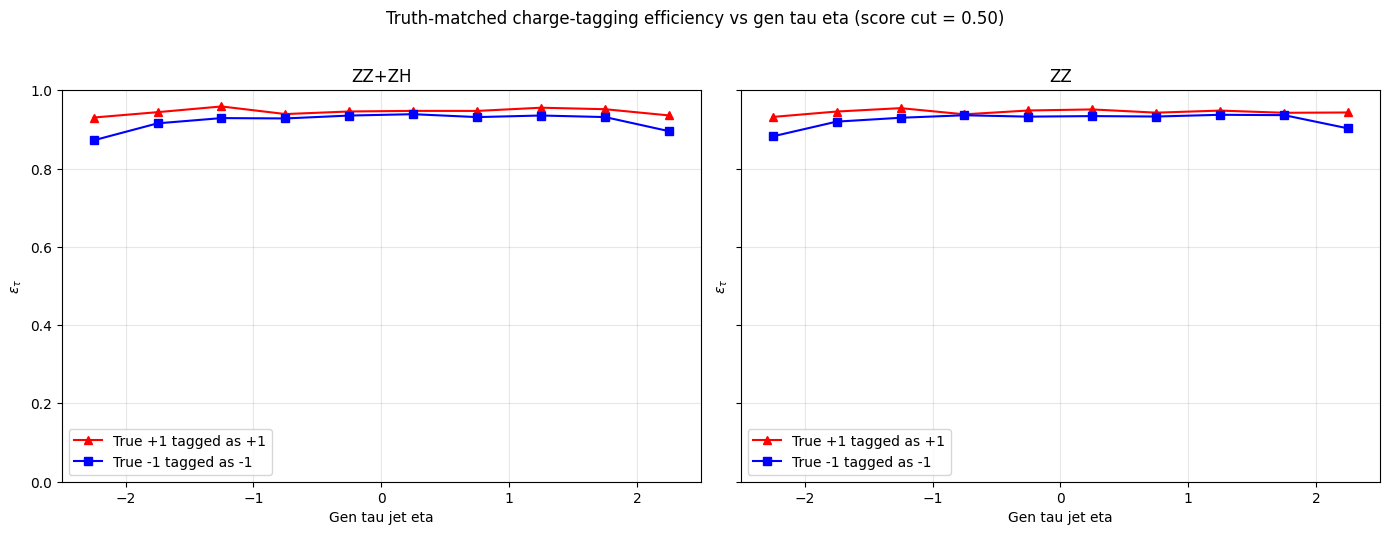

In [126]:
# Truth-matched charge-tagging efficiency vs gen tau eta for the newer ZZ-only and ZZ+ZH-trained models.
compare_gen_eta_bins = np.array([-2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5])

def compute_truth_matched_charge_metrics_vs_gen_eta_compare(gen_tau_eta, true_charge_signed, model_score, bins, score_cut=0.5):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pred_charge = np.where(model_score >= score_cut, 1, -1)

    eff_pos = []
    eff_neg = []
    pos_den = []
    neg_den = []

    for low, high in zip(bins[:-1], bins[1:]):
        bin_mask = (gen_tau_eta >= low) & (gen_tau_eta < high)
        pos_mask = bin_mask & (true_charge_signed == 1)
        neg_mask = bin_mask & (true_charge_signed == -1)

        pos_den_count = int(np.sum(pos_mask))
        neg_den_count = int(np.sum(neg_mask))
        pos_den.append(pos_den_count)
        neg_den.append(neg_den_count)

        eff_pos.append(np.mean(pred_charge[pos_mask] == 1) if pos_den_count > 0 else np.nan)
        eff_neg.append(np.mean(pred_charge[neg_mask] == -1) if neg_den_count > 0 else np.nan)

    return {
        'centers': centers,
        'eff_pos': np.array(eff_pos),
        'eff_neg': np.array(eff_neg),
        'pos_den': np.array(pos_den),
        'neg_den': np.array(neg_den),
    }

fig, axes = plt.subplots(1, len(compare_results), figsize=(7.0 * len(compare_results), 5.2), sharey=True)
axes = np.atleast_1d(axes)
compare_gen_eta_metrics = {}

for ax, (label, payload) in zip(axes, compare_results.items()):
    raw_data = compare_raw_data[label]
    gen_tau_eta_values = ak.to_numpy(to_p4(raw_data.gen_jet_tau_p4s).eta)
    true_charge_signed = compare_true_charge_signed[label]
    model_score_values = np.asarray(payload['pred'])

    metrics = compute_truth_matched_charge_metrics_vs_gen_eta_compare(
        gen_tau_eta=gen_tau_eta_values,
        true_charge_signed=true_charge_signed,
        model_score=model_score_values,
        bins=compare_gen_eta_bins,
        score_cut=compare_gen_pt_score_cut,
    )
    compare_gen_eta_metrics[label] = metrics

    ax.plot(metrics['centers'], metrics['eff_pos'], marker='^', label='True +1 tagged as +1', color='red')
    ax.plot(metrics['centers'], metrics['eff_neg'], marker='s', label='True -1 tagged as -1', color='blue')
    ax.set_xlabel('Gen tau jet eta')
    ax.set_ylabel(r'$\epsilon_{\tau}$')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(compare_gen_eta_bins[0], compare_gen_eta_bins[-1])
    ax.set_ylim(0.0, 1.0)

fig.suptitle(f'Truth-matched charge-tagging efficiency vs gen tau eta (score cut = {compare_gen_pt_score_cut:.2f})', y=1.02)
plt.tight_layout()
plt.show()


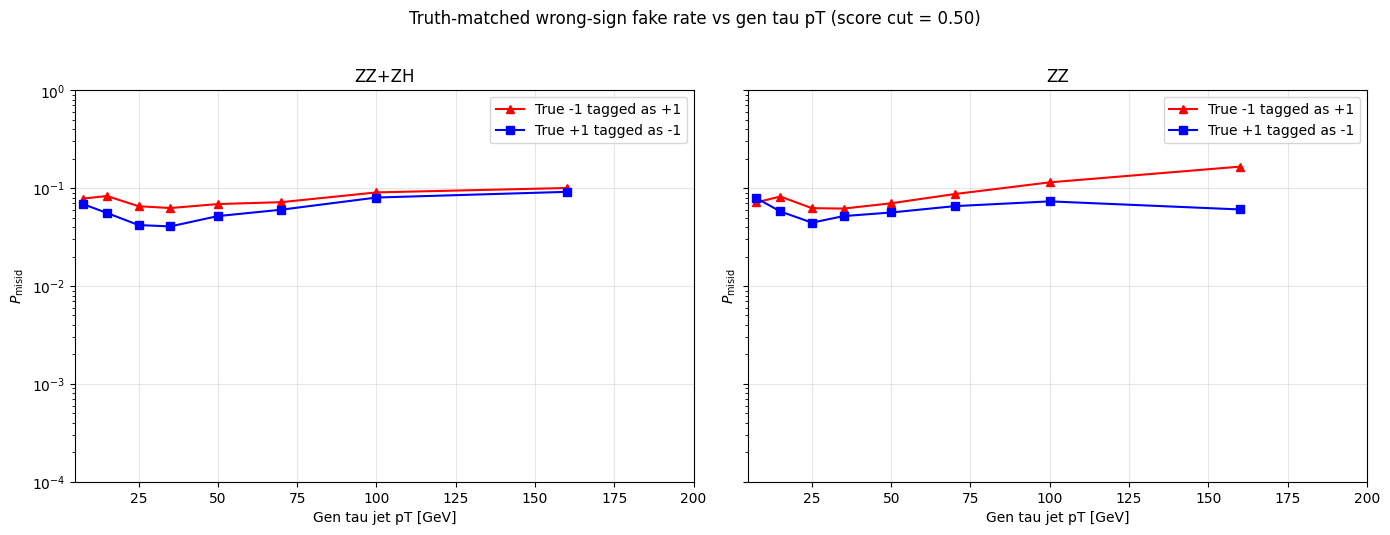

In [127]:
# Truth-matched wrong-sign fake rate vs gen tau pT for the newer ZZ-only and ZZ+ZH-trained models.
fig, axes = plt.subplots(1, len(compare_results), figsize=(7.0 * len(compare_results), 5.2), sharey=True)
axes = np.atleast_1d(axes)
compare_gen_pt_fake_metrics = {}

for ax, (label, payload) in zip(axes, compare_results.items()):
    raw_data = compare_raw_data[label]
    gen_tau_pt_values = ak.to_numpy(to_p4(raw_data.gen_jet_tau_p4s).pt)
    true_charge_signed = compare_true_charge_signed[label]
    model_score_values = np.asarray(payload['pred'])

    metrics = compute_truth_matched_charge_metrics_vs_gen_pt_compare(
        gen_tau_pt=gen_tau_pt_values,
        true_charge_signed=true_charge_signed,
        model_score=model_score_values,
        bins=compare_gen_pt_bins,
        score_cut=compare_gen_pt_score_cut,
    )
    compare_gen_pt_fake_metrics[label] = metrics

    ax.plot(metrics['centers'], metrics['fake_pos_from_neg'], marker='^', label='True -1 tagged as +1', color='red')
    ax.plot(metrics['centers'], metrics['fake_neg_from_pos'], marker='s', label='True +1 tagged as -1', color='blue')
    ax.set_xlabel('Gen tau jet pT [GeV]')
    ax.set_ylabel(r'$P_{\mathrm{misid}}$')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(compare_gen_pt_bins[0], compare_gen_pt_bins[-1])
    ax.set_yscale('log')
    ax.set_ylim(1e-4, 1.0)

fig.suptitle(f'Truth-matched wrong-sign fake rate vs gen tau pT (score cut = {compare_gen_pt_score_cut:.2f})', y=1.02)
plt.tight_layout()
plt.show()


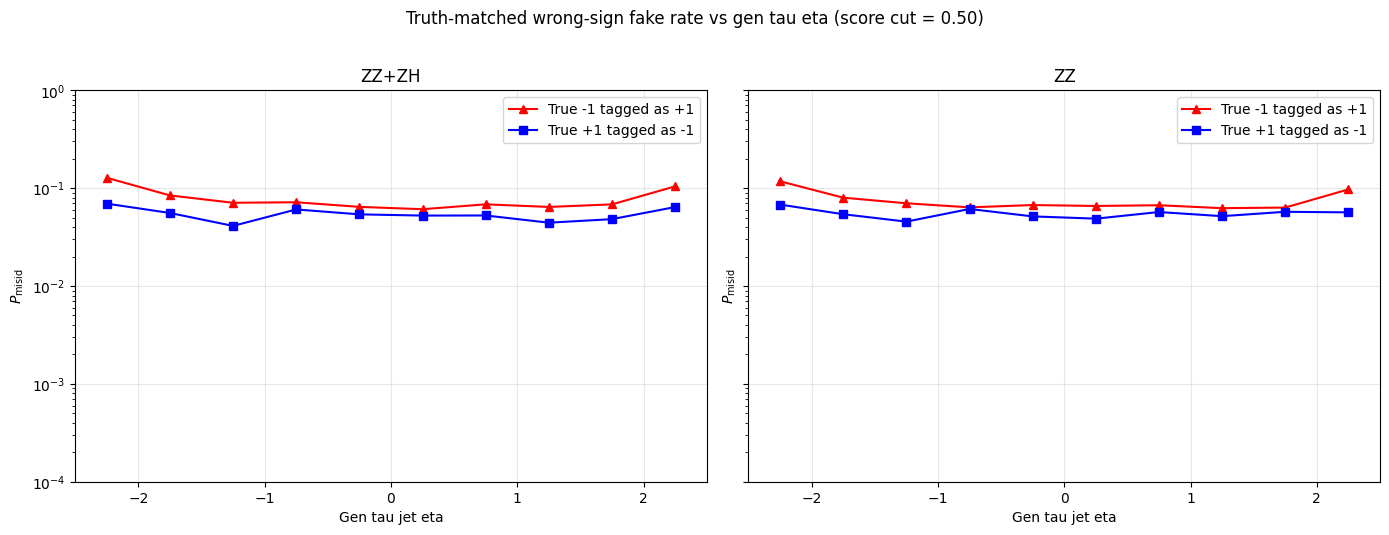

In [128]:
# Truth-matched wrong-sign fake rate vs gen tau eta for the newer ZZ-only and ZZ+ZH-trained models.
def compute_truth_matched_charge_fake_vs_gen_eta_compare(gen_tau_eta, true_charge_signed, model_score, bins, score_cut=0.5):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pred_charge = np.where(model_score >= score_cut, 1, -1)

    fake_pos_from_neg = []
    fake_neg_from_pos = []
    neg_den = []
    pos_den = []

    for low, high in zip(bins[:-1], bins[1:]):
        bin_mask = (gen_tau_eta >= low) & (gen_tau_eta < high)
        pos_mask = bin_mask & (true_charge_signed == 1)
        neg_mask = bin_mask & (true_charge_signed == -1)

        pos_den_count = int(np.sum(pos_mask))
        neg_den_count = int(np.sum(neg_mask))
        pos_den.append(pos_den_count)
        neg_den.append(neg_den_count)

        fake_pos_from_neg.append(np.mean(pred_charge[neg_mask] == 1) if neg_den_count > 0 else np.nan)
        fake_neg_from_pos.append(np.mean(pred_charge[pos_mask] == -1) if pos_den_count > 0 else np.nan)

    return {
        'centers': centers,
        'fake_pos_from_neg': np.array(fake_pos_from_neg),
        'fake_neg_from_pos': np.array(fake_neg_from_pos),
        'pos_den': np.array(pos_den),
        'neg_den': np.array(neg_den),
    }

fig, axes = plt.subplots(1, len(compare_results), figsize=(7.0 * len(compare_results), 5.2), sharey=True)
axes = np.atleast_1d(axes)
compare_gen_eta_fake_metrics = {}

for ax, (label, payload) in zip(axes, compare_results.items()):
    raw_data = compare_raw_data[label]
    gen_tau_eta_values = ak.to_numpy(to_p4(raw_data.gen_jet_tau_p4s).eta)
    true_charge_signed = compare_true_charge_signed[label]
    model_score_values = np.asarray(payload['pred'])

    metrics = compute_truth_matched_charge_fake_vs_gen_eta_compare(
        gen_tau_eta=gen_tau_eta_values,
        true_charge_signed=true_charge_signed,
        model_score=model_score_values,
        bins=compare_gen_eta_bins,
        score_cut=compare_gen_pt_score_cut,
    )
    compare_gen_eta_fake_metrics[label] = metrics

    ax.plot(metrics['centers'], metrics['fake_pos_from_neg'], marker='^', label='True -1 tagged as +1', color='red')
    ax.plot(metrics['centers'], metrics['fake_neg_from_pos'], marker='s', label='True +1 tagged as -1', color='blue')
    ax.set_xlabel('Gen tau jet eta')
    ax.set_ylabel(r'$P_{\mathrm{misid}}$')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(compare_gen_eta_bins[0], compare_gen_eta_bins[-1])
    ax.set_yscale('log')
    ax.set_ylim(1e-4, 1.0)

fig.suptitle(f'Truth-matched wrong-sign fake rate vs gen tau eta (score cut = {compare_gen_pt_score_cut:.2f})', y=1.02)
plt.tight_layout()
plt.show()


In [129]:
# Average-efficiency operating point chosen from a target average fake rate.
# Here average fake rate means 0.5 * [P(true -1 -> pred +1) + P(true +1 -> pred -1)].
# Average efficiency means 0.5 * [P(true +1 -> pred +1) + P(true -1 -> pred -1)].

target_avg_fake_rate = 1e-2
model_threshold_grid_compare = np.linspace(0.0, 1.0, 2001)

def compute_average_efficiency_and_fake_curve(score, true_charge_signed, thresholds):
    pos_mask = true_charge_signed == 1
    neg_mask = true_charge_signed == -1
    avg_eff = []
    avg_fake = []
    eff_pos = []
    eff_neg = []
    fake_pos_from_neg = []
    fake_neg_from_pos = []

    for thr in thresholds:
        # pred_pos = score >= thr
        # pred_neg = ~pred_pos
        pred_pos = score >= thr
        pred_neg = 1-score > thr

        eps_pos = np.mean(pred_pos[pos_mask]) if np.any(pos_mask) else np.nan
        eps_neg = np.mean(pred_neg[neg_mask]) if np.any(neg_mask) else np.nan
        fake_pos = np.mean(pred_pos[neg_mask]) if np.any(neg_mask) else np.nan
        fake_neg = np.mean(pred_neg[pos_mask]) if np.any(pos_mask) else np.nan

        eff_pos.append(eps_pos)
        eff_neg.append(eps_neg)
        fake_pos_from_neg.append(fake_pos)
        fake_neg_from_pos.append(fake_neg)
        avg_eff.append(0.5 * (eps_pos + eps_neg))
        avg_fake.append(0.5 * (fake_pos + fake_neg))

    return {
        'thresholds': np.asarray(thresholds),
        'avg_eff': np.asarray(avg_eff),
        'avg_fake': np.asarray(avg_fake),
        'eff_pos': np.asarray(eff_pos),
        'eff_neg': np.asarray(eff_neg),
        'fake_pos_from_neg': np.asarray(fake_pos_from_neg),
        'fake_neg_from_pos': np.asarray(fake_neg_from_pos),
    }

def choose_threshold_for_target_avg_fake(score, true_charge_signed, thresholds, target_avg_fake_rate):
    curve = compute_average_efficiency_and_fake_curve(score, true_charge_signed, thresholds)
    valid = np.isfinite(curve['avg_eff']) & np.isfinite(curve['avg_fake'])
    accepted = valid & (curve['avg_fake'] <= target_avg_fake_rate)

    if np.any(accepted):
        best_idx = np.nanargmax(np.where(accepted, curve['avg_eff'], np.nan))
    else:
        best_idx = np.nanargmin(np.abs(curve['avg_fake'] - target_avg_fake_rate))

    return {
        'threshold': curve['thresholds'][best_idx],
        'avg_eff': curve['avg_eff'][best_idx],
        'avg_fake': curve['avg_fake'][best_idx],
        'eff_pos': curve['eff_pos'][best_idx],
        'eff_neg': curve['eff_neg'][best_idx],
        'fake_pos_from_neg': curve['fake_pos_from_neg'][best_idx],
        'fake_neg_from_pos': curve['fake_neg_from_pos'][best_idx],
        'curve': curve,
    }

def compute_binned_average_efficiency(values, bins, score, true_charge_signed, threshold):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pred_charge = np.where(score >= threshold, 1, -1)
    avg_eff = []
    pos_den = []
    neg_den = []

    for low, high in zip(bins[:-1], bins[1:]):
        mask = (values >= low) & (values < high)
        pos_mask = mask & (true_charge_signed == 1)
        neg_mask = mask & (true_charge_signed == -1)

        pos_den_count = int(np.sum(pos_mask))
        neg_den_count = int(np.sum(neg_mask))
        pos_den.append(pos_den_count)
        neg_den.append(neg_den_count)

        eps_pos = np.mean(pred_charge[pos_mask] == 1) if pos_den_count > 0 else np.nan
        eps_neg = np.mean(pred_charge[neg_mask] == -1) if neg_den_count > 0 else np.nan
        avg_eff.append(0.5 * (eps_pos + eps_neg) if pos_den_count > 0 and neg_den_count > 0 else np.nan)

    return {
        'centers': centers,
        'avg_eff': np.asarray(avg_eff),
        'pos_den': np.asarray(pos_den),
        'neg_den': np.asarray(neg_den),
    }

avg_fake_operating_points = {}
for label, payload in compare_results.items():
    true_charge = compare_true_charge_signed[label]
    model_score = np.asarray(payload['pred'])
    qk_score = np.asarray(compare_qk[label])
    qk_threshold_grid_compare = np.linspace(np.min(qk_score), np.max(qk_score), 2001)

    avg_fake_operating_points[label] = {
        'model': choose_threshold_for_target_avg_fake(model_score, true_charge, model_threshold_grid_compare, target_avg_fake_rate),
        'qk': choose_threshold_for_target_avg_fake(qk_score, true_charge, qk_threshold_grid_compare, target_avg_fake_rate),
    }

display(pd.DataFrame({
    'model': list(avg_fake_operating_points.keys()),
    'model_threshold': [avg_fake_operating_points[label]['model']['threshold'] for label in avg_fake_operating_points],
    'model_avg_eff': [avg_fake_operating_points[label]['model']['avg_eff'] for label in avg_fake_operating_points],
    'model_avg_fake': [avg_fake_operating_points[label]['model']['avg_fake'] for label in avg_fake_operating_points],
    f'qkappa_{best_kappa_label}_threshold': [avg_fake_operating_points[label]['qk']['threshold'] for label in avg_fake_operating_points],
    f'qkappa_{best_kappa_label}_avg_eff': [avg_fake_operating_points[label]['qk']['avg_eff'] for label in avg_fake_operating_points],
    f'qkappa_{best_kappa_label}_avg_fake': [avg_fake_operating_points[label]['qk']['avg_fake'] for label in avg_fake_operating_points],
}))


,model,model_threshold,model_avg_eff,model_avg_fake,qkappa_0.2_threshold,qkappa_0.2_avg_eff,qkappa_0.2_avg_fake
0,ZZ+ZH,0.8610,0.840579,0.009981,1.658936,0.359684,0.009905
1,ZZ,0.8765,0.836081,0.009965,1.658841,0.358874,0.009927


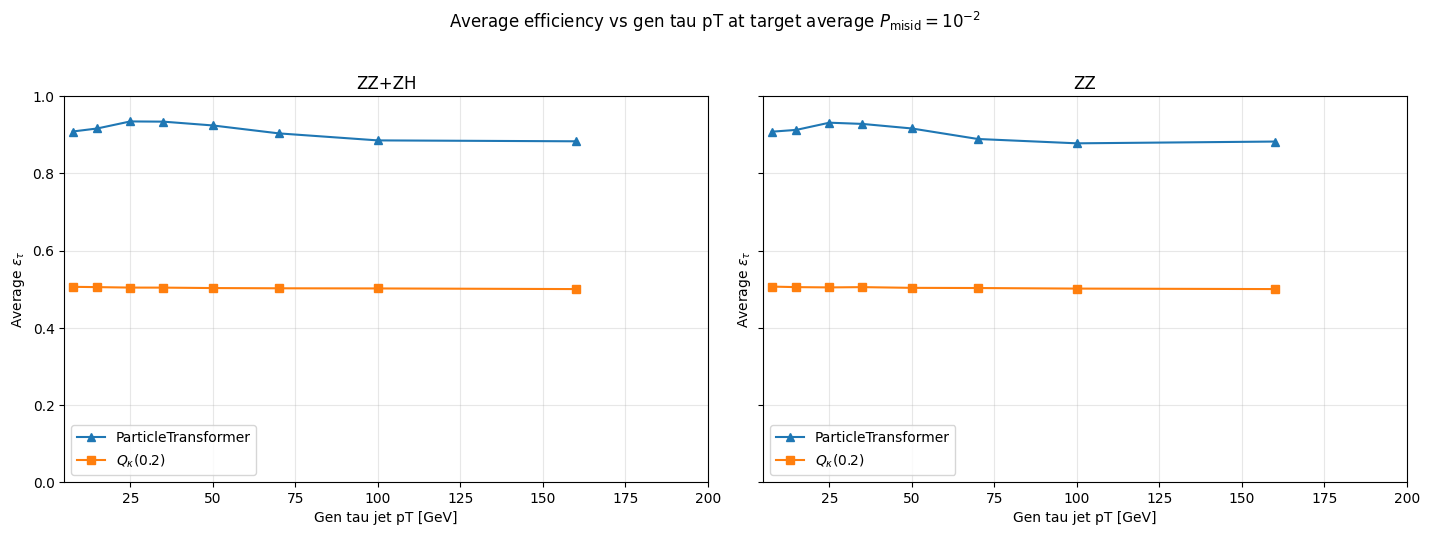

In [130]:
# Average efficiency vs gen tau pT at fixed average fake rate 1e-2, for model and Q_kappa.
fig, axes = plt.subplots(1, len(compare_results), figsize=(7.2 * len(compare_results), 5.2), sharey=True)
axes = np.atleast_1d(axes)
avg_eff_vs_pt_curves = {}

for ax, (label, payload) in zip(axes, compare_results.items()):
    raw_data = compare_raw_data[label]
    true_charge = compare_true_charge_signed[label]
    gen_tau_pt_values = ak.to_numpy(to_p4(raw_data.gen_jet_tau_p4s).pt)

    model_score = np.asarray(payload['pred'])
    qk_score = np.asarray(compare_qk[label])
    model_thr = avg_fake_operating_points[label]['model']['threshold']
    qk_thr = avg_fake_operating_points[label]['qk']['threshold']

    model_curve = compute_binned_average_efficiency(gen_tau_pt_values, compare_gen_pt_bins, model_score, true_charge, model_thr)
    qk_curve = compute_binned_average_efficiency(gen_tau_pt_values, compare_gen_pt_bins, qk_score, true_charge, qk_thr)
    avg_eff_vs_pt_curves[label] = {'model': model_curve, 'qk': qk_curve}

    ax.plot(model_curve['centers'], model_curve['avg_eff'], marker='^', color='tab:blue', label='ParticleTransformer')
    ax.plot(qk_curve['centers'], qk_curve['avg_eff'], marker='s', color='tab:orange', label=rf'$Q_\kappa({best_kappa_label})$')
    ax.set_xlabel('Gen tau jet pT [GeV]')
    ax.set_ylabel(r'Average $\epsilon_{\tau}$')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(compare_gen_pt_bins[0], compare_gen_pt_bins[-1])
    ax.set_ylim(0.0, 1.0)

fig.suptitle(r'Average efficiency vs gen tau pT at target average $P_{\mathrm{misid}} = 10^{-2}$', y=1.02)
plt.tight_layout()
plt.show()


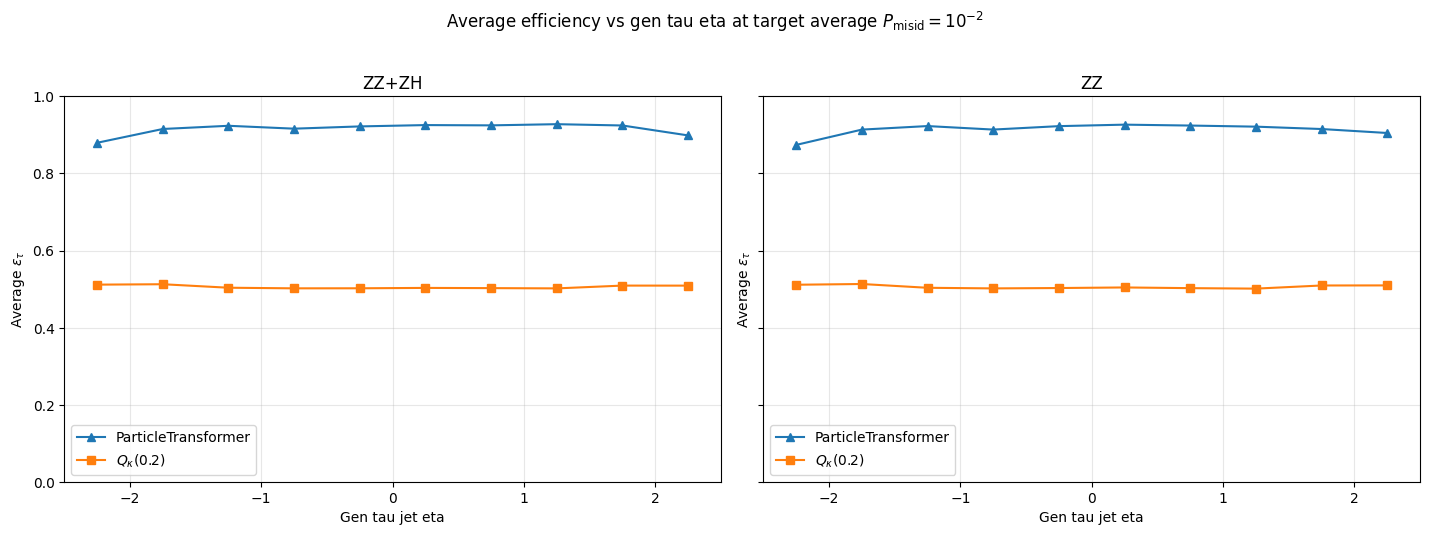

In [131]:
# Average efficiency vs gen tau eta at fixed average fake rate 1e-2, for model and Q_kappa.
fig, axes = plt.subplots(1, len(compare_results), figsize=(7.2 * len(compare_results), 5.2), sharey=True)
axes = np.atleast_1d(axes)
avg_eff_vs_eta_curves = {}

for ax, (label, payload) in zip(axes, compare_results.items()):
    raw_data = compare_raw_data[label]
    true_charge = compare_true_charge_signed[label]
    gen_tau_eta_values = ak.to_numpy(to_p4(raw_data.gen_jet_tau_p4s).eta)

    model_score = np.asarray(payload['pred'])
    qk_score = np.asarray(compare_qk[label])
    model_thr = avg_fake_operating_points[label]['model']['threshold']
    qk_thr = avg_fake_operating_points[label]['qk']['threshold']

    model_curve = compute_binned_average_efficiency(gen_tau_eta_values, compare_gen_eta_bins, model_score, true_charge, model_thr)
    qk_curve = compute_binned_average_efficiency(gen_tau_eta_values, compare_gen_eta_bins, qk_score, true_charge, qk_thr)
    avg_eff_vs_eta_curves[label] = {'model': model_curve, 'qk': qk_curve}

    ax.plot(model_curve['centers'], model_curve['avg_eff'], marker='^', color='tab:blue', label='ParticleTransformer')
    ax.plot(qk_curve['centers'], qk_curve['avg_eff'], marker='s', color='tab:orange', label=rf'$Q_\kappa({best_kappa_label})$')
    ax.set_xlabel('Gen tau jet eta')
    ax.set_ylabel(r'Average $\epsilon_{\tau}$')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(compare_gen_eta_bins[0], compare_gen_eta_bins[-1])
    ax.set_ylim(0.0, 1.0)

fig.suptitle(r'Average efficiency vs gen tau eta at target average $P_{\mathrm{misid}} = 10^{-2}$', y=1.02)
plt.tight_layout()
plt.show()


In [132]:
chargearray = ak.flatten(data_ptcut["gen_jet_tau_charge"], axis = -1)

zzchargearray = ak.flatten(zz_ptcut["gen_jet_tau_charge"], axis = -1)
zhchargearray = ak.flatten(zh_ptcut["gen_jet_tau_charge"], axis = -1)

In [133]:
unique, counts = np.unique(zhchargearray, return_counts=True)
for u, c in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"charge {u:>4}: {c}")

charge  1.0: 52606.0
charge -1.0: 52249.0


In [134]:
unique, counts = np.unique(zzchargearray, return_counts=True)
for u, c in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"charge {u:>4}: {c}")

charge  1.0: 86528.0
charge -1.0: 82714.0


In [135]:
qpos1 = 52606.0 + 86528.0
qneg1 = 52249.0 + 82714.0

In [136]:
qpos1, qneg1

(139134.0, 134963.0)

In [137]:
qpos1 - qneg1

4171.0

### Z@91GeV

In [138]:
# Load the standalone Z-trained charge-classification model and its matching test sample.
z_model_dir = '/home/norman/ml-tau/ml-tau-en-reg/training-outputs/260319_charge_classification_z_tautau_91_e150/charge_classification/ParticleTransformer'
z_raw_test_dir = '/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260319_91'
z_sample_names = ['z_test.parquet']
z_compare_pt_cut = 5.0

z_result = load_model_outputs_across_samples(z_model_dir, z_sample_names)
z_raw_data = load_raw_eval_sample_across_samples(z_raw_test_dir, z_sample_names, pt_cut=z_compare_pt_cut)
if len(z_result['pred']) != len(z_raw_data):
    raise ValueError(f'Length mismatch for Z: model outputs have {len(z_result["pred"])} jets but raw sample has {len(z_raw_data)}')

z_true_charge_signed = np.where(z_result['target'] == 1, 1, -1)
z_pf_charges = z_raw_data.reco_cand_charge
z_pf_pts = to_p4(z_raw_data.reco_cand_p4s).pt
z_jet_pts = to_p4(z_raw_data.reco_jet_p4s).pt
z_qk = jet_charge_qkappa(z_pf_charges, z_pf_pts, z_jet_pts, kappa=best_kappa)
z_D_qk = np.clip(0.5 * (z_qk + 1.0), 0.0, 1.0)

display(pd.DataFrame({
    'model': ['Z'],
    'samples': [', '.join(z_result['samples'])],
    'n_jets': [len(z_result['pred'])],
}))


,model,samples,n_jets
0,Z,z_test.parquet,24358


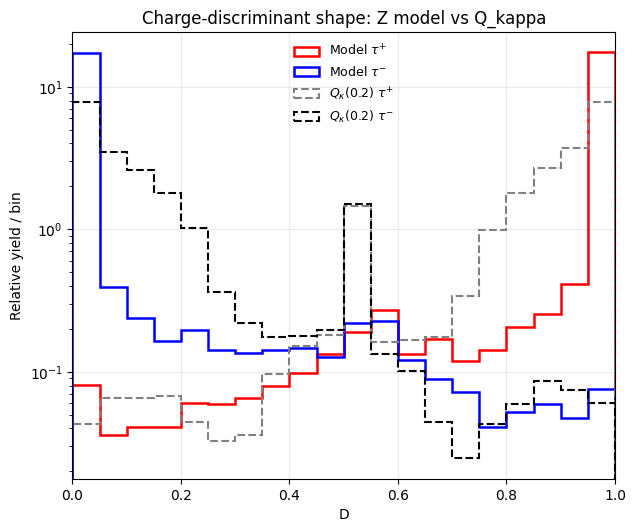

In [139]:
# Charge-discriminant shape: Z model vs Q_kappa.
bins_D_z = np.linspace(0.0, 1.0, 21)
plt.figure(figsize=(7.0, 5.8))
plt.hist(np.asarray(z_result['pred'])[z_true_charge_signed == 1], bins=bins_D_z, density=True, histtype='step', linestyle='-', linewidth=1.8, color='red', label=r'Model $\tau^{+}$')
plt.hist(np.asarray(z_result['pred'])[z_true_charge_signed == -1], bins=bins_D_z, density=True, histtype='step', linestyle='-', linewidth=1.8, color='blue', label=r'Model $\tau^{-}$')
plt.hist(z_D_qk[z_true_charge_signed == 1], bins=bins_D_z, density=True, histtype='step', linestyle='--', linewidth=1.5, color='grey', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
plt.hist(z_D_qk[z_true_charge_signed == -1], bins=bins_D_z, density=True, histtype='step', linestyle='--', linewidth=1.5, color='black', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel('D')
plt.ylabel('Relative yield / bin')
plt.title('Charge-discriminant shape: Z model vs Q_kappa')
plt.yscale('log')
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, fontsize=9)
plt.xlim(0.0, 1.0)
plt.show()


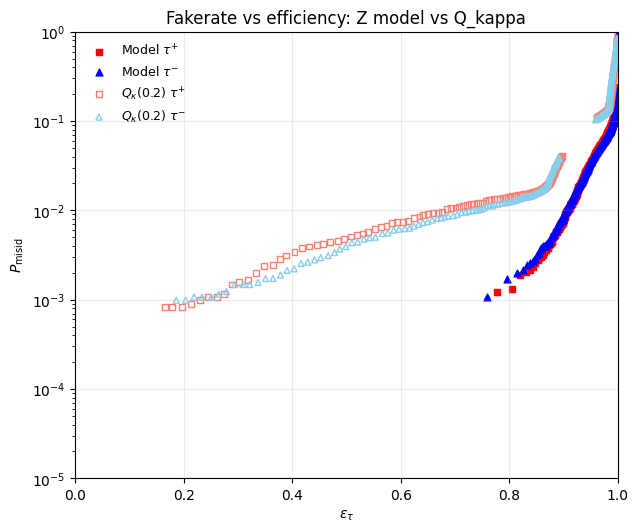

In [140]:
# Fakerate vs efficiency: Z model vs Q_kappa.
thresholds_D_z = np.linspace(0.0, 1.0, 300)
z_curves_model = compute_misid_vs_efficiency(np.asarray(z_result['pred']), z_true_charge_signed, thresholds_D_z)
z_curves_qk = compute_misid_vs_efficiency(z_D_qk, z_true_charge_signed, thresholds_D_z)
plt.figure(figsize=(7.0, 5.8))
plt.scatter(z_curves_model['eps_tau_pos'], z_curves_model['pmisid_pos'], s=24, marker='s', color='red', label=r'Model $\tau^{+}$')
plt.scatter(z_curves_model['eps_tau_neg'], z_curves_model['pmisid_neg'], s=24, marker='^', color='blue', label=r'Model $\tau^{-}$')
plt.scatter(z_curves_qk['eps_tau_pos'], z_curves_qk['pmisid_pos'], s=18, marker='s', facecolors='none', edgecolors='salmon', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
plt.scatter(z_curves_qk['eps_tau_neg'], z_curves_qk['pmisid_neg'], s=18, marker='^', facecolors='none', edgecolors='skyblue', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel(r'$\epsilon_{\tau}$')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title('Fakerate vs efficiency: Z model vs Q_kappa')
plt.yscale('log')
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, fontsize=9)
plt.xlim(0.0, 1.0)
plt.ylim(1e-5, 1.0)
plt.show()


In [141]:
# Optional x-axis range for the standalone Z pT-dependent plots.
# Change z_pt_plot_xlim_max if you want to zoom further in or out without changing the binning.
z_pt_plot_xlim_max = 55.0
z_pt_plot_xlim = (compare_gen_pt_bins[0], z_pt_plot_xlim_max)


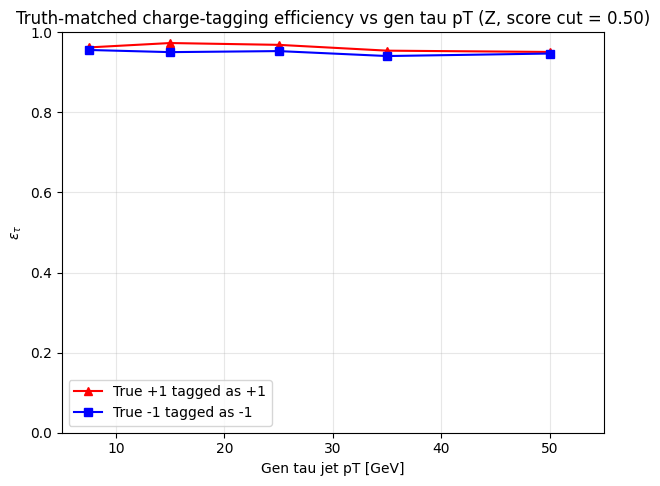

In [142]:
# Truth-matched charge-tagging efficiency vs gen tau pT for the Z-trained model.
z_gen_tau_pt_values = ak.to_numpy(to_p4(z_raw_data.gen_jet_tau_p4s).pt)
z_gen_pt_metrics = compute_truth_matched_charge_metrics_vs_gen_pt_compare(
    gen_tau_pt=z_gen_tau_pt_values,
    true_charge_signed=z_true_charge_signed,
    model_score=np.asarray(z_result['pred']),
    bins=compare_gen_pt_bins,
    score_cut=compare_gen_pt_score_cut,
)
plt.figure(figsize=(7.0, 5.2))
plt.plot(z_gen_pt_metrics['centers'], z_gen_pt_metrics['eff_pos'], marker='^', label='True +1 tagged as +1', color='red')
plt.plot(z_gen_pt_metrics['centers'], z_gen_pt_metrics['eff_neg'], marker='s', label='True -1 tagged as -1', color='blue')
plt.xlabel('Gen tau jet pT [GeV]')
plt.ylabel(r'$\epsilon_{\tau}$')
plt.title(f'Truth-matched charge-tagging efficiency vs gen tau pT (Z, score cut = {compare_gen_pt_score_cut:.2f})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(*z_pt_plot_xlim)
plt.ylim(0.0, 1.0)
plt.show()


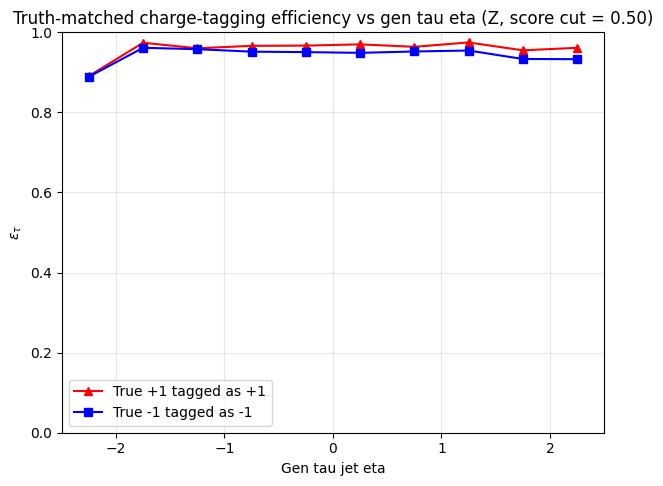

In [143]:
# Truth-matched charge-tagging efficiency vs gen tau eta for the Z-trained model.
z_gen_tau_eta_values = ak.to_numpy(to_p4(z_raw_data.gen_jet_tau_p4s).eta)
z_gen_eta_metrics = compute_truth_matched_charge_metrics_vs_gen_eta_compare(
    gen_tau_eta=z_gen_tau_eta_values,
    true_charge_signed=z_true_charge_signed,
    model_score=np.asarray(z_result['pred']),
    bins=compare_gen_eta_bins,
    score_cut=compare_gen_pt_score_cut,
)
plt.figure(figsize=(7.0, 5.2))
plt.plot(z_gen_eta_metrics['centers'], z_gen_eta_metrics['eff_pos'], marker='^', label='True +1 tagged as +1', color='red')
plt.plot(z_gen_eta_metrics['centers'], z_gen_eta_metrics['eff_neg'], marker='s', label='True -1 tagged as -1', color='blue')
plt.xlabel('Gen tau jet eta')
plt.ylabel(r'$\epsilon_{\tau}$')
plt.title(f'Truth-matched charge-tagging efficiency vs gen tau eta (Z, score cut = {compare_gen_pt_score_cut:.2f})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(compare_gen_eta_bins[0], compare_gen_eta_bins[-1])
plt.ylim(0.0, 1.0)
plt.show()


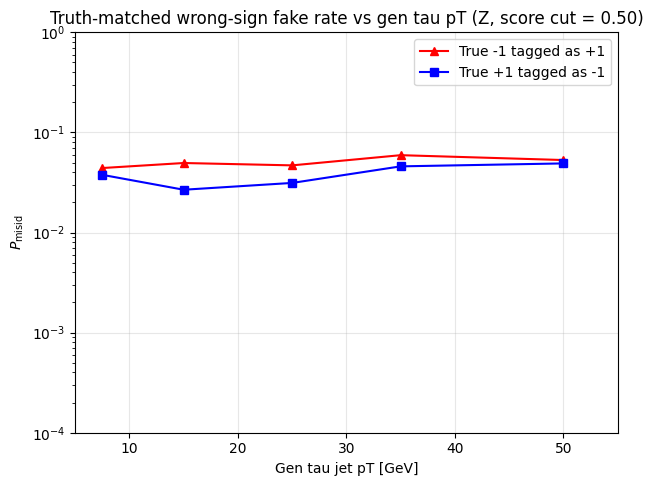

In [144]:
# Truth-matched wrong-sign fake rate vs gen tau pT for the Z-trained model.
plt.figure(figsize=(7.0, 5.2))
plt.plot(z_gen_pt_metrics['centers'], z_gen_pt_metrics['fake_pos_from_neg'], marker='^', label='True -1 tagged as +1', color='red')
plt.plot(z_gen_pt_metrics['centers'], z_gen_pt_metrics['fake_neg_from_pos'], marker='s', label='True +1 tagged as -1', color='blue')
plt.xlabel('Gen tau jet pT [GeV]')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title(f'Truth-matched wrong-sign fake rate vs gen tau pT (Z, score cut = {compare_gen_pt_score_cut:.2f})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(*z_pt_plot_xlim)
plt.yscale('log')
plt.ylim(1e-4, 1.0)
plt.show()


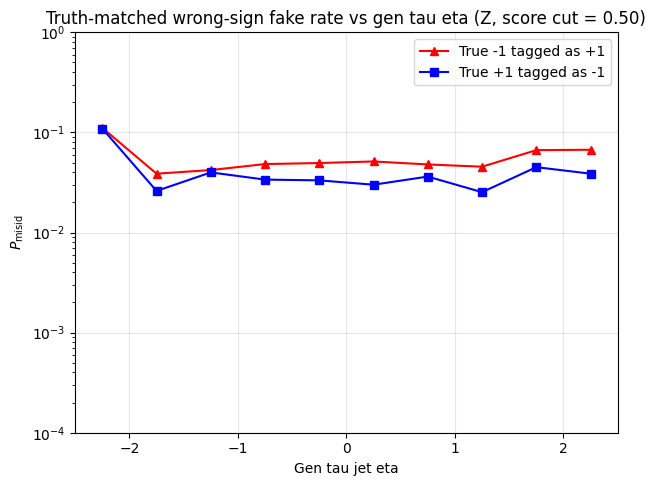

In [145]:
# Truth-matched wrong-sign fake rate vs gen tau eta for the Z-trained model.
z_gen_eta_fake_metrics = compute_truth_matched_charge_fake_vs_gen_eta_compare(
    gen_tau_eta=z_gen_tau_eta_values,
    true_charge_signed=z_true_charge_signed,
    model_score=np.asarray(z_result['pred']),
    bins=compare_gen_eta_bins,
    score_cut=compare_gen_pt_score_cut,
)
plt.figure(figsize=(7.0, 5.2))
plt.plot(z_gen_eta_fake_metrics['centers'], z_gen_eta_fake_metrics['fake_pos_from_neg'], marker='^', label='True -1 tagged as +1', color='red')
plt.plot(z_gen_eta_fake_metrics['centers'], z_gen_eta_fake_metrics['fake_neg_from_pos'], marker='s', label='True +1 tagged as -1', color='blue')
plt.xlabel('Gen tau jet eta')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title(f'Truth-matched wrong-sign fake rate vs gen tau eta (Z, score cut = {compare_gen_pt_score_cut:.2f})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(compare_gen_eta_bins[0], compare_gen_eta_bins[-1])
plt.yscale('log')
plt.ylim(1e-4, 1.0)
plt.show()


In [146]:
# Average-efficiency operating point chosen from a target average fake rate for the Z-trained model.
z_qk_threshold_grid = np.linspace(np.min(z_qk), np.max(z_qk), 2001)
z_avg_fake_operating_points = {
    'model': choose_threshold_for_target_avg_fake(np.asarray(z_result['pred']), z_true_charge_signed, model_threshold_grid_compare, target_avg_fake_rate),
    'qk': choose_threshold_for_target_avg_fake(np.asarray(z_qk), z_true_charge_signed, z_qk_threshold_grid, target_avg_fake_rate),
}
display(pd.DataFrame({
    'model': ['Z'],
    'model_threshold': [z_avg_fake_operating_points['model']['threshold']],
    'model_avg_eff': [z_avg_fake_operating_points['model']['avg_eff']],
    'model_avg_fake': [z_avg_fake_operating_points['model']['avg_fake']],
    f'qkappa_{best_kappa_label}_threshold': [z_avg_fake_operating_points['qk']['threshold']],
    f'qkappa_{best_kappa_label}_avg_eff': [z_avg_fake_operating_points['qk']['avg_eff']],
    f'qkappa_{best_kappa_label}_avg_fake': [z_avg_fake_operating_points['qk']['avg_fake']],
}))


,model,model_threshold,model_avg_eff,model_avg_fake,qkappa_0.2_threshold,qkappa_0.2_avg_eff,qkappa_0.2_avg_fake
0,Z,0.8185,0.906025,0.009976,1.239988,0.453041,0.009931


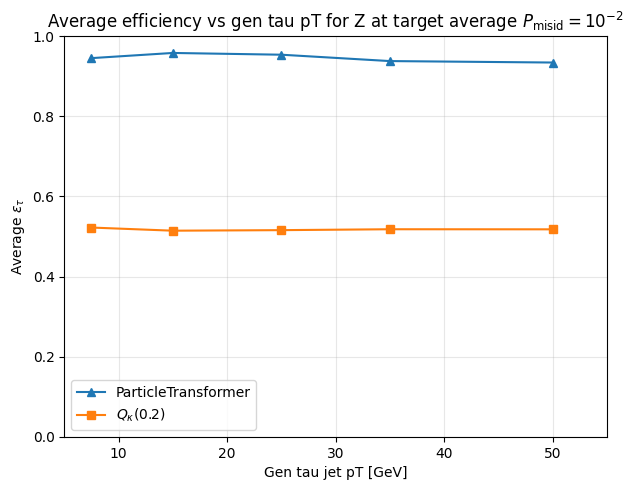

In [147]:
# Average efficiency vs gen tau pT at target average fake rate 1e-2 for the Z-trained model.
z_avg_eff_vs_pt_model = compute_binned_average_efficiency(z_gen_tau_pt_values, compare_gen_pt_bins, np.asarray(z_result['pred']), z_true_charge_signed, z_avg_fake_operating_points['model']['threshold'])
z_avg_eff_vs_pt_qk = compute_binned_average_efficiency(z_gen_tau_pt_values, compare_gen_pt_bins, np.asarray(z_qk), z_true_charge_signed, z_avg_fake_operating_points['qk']['threshold'])
plt.figure(figsize=(7.0, 5.2))
plt.plot(z_avg_eff_vs_pt_model['centers'], z_avg_eff_vs_pt_model['avg_eff'], marker='^', color='tab:blue', label='ParticleTransformer')
plt.plot(z_avg_eff_vs_pt_qk['centers'], z_avg_eff_vs_pt_qk['avg_eff'], marker='s', color='tab:orange', label=rf'$Q_\kappa({best_kappa_label})$')
plt.xlabel('Gen tau jet pT [GeV]')
plt.ylabel(r'Average $\epsilon_{\tau}$')
plt.title(r'Average efficiency vs gen tau pT for Z at target average $P_{\mathrm{misid}} = 10^{-2}$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(*z_pt_plot_xlim)
plt.ylim(0.0, 1.0)
plt.show()


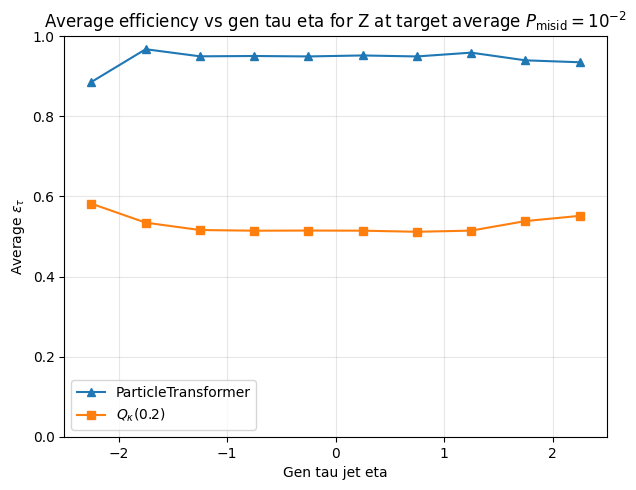

In [148]:
# Average efficiency vs gen tau eta at target average fake rate 1e-2 for the Z-trained model.
z_avg_eff_vs_eta_model = compute_binned_average_efficiency(z_gen_tau_eta_values, compare_gen_eta_bins, np.asarray(z_result['pred']), z_true_charge_signed, z_avg_fake_operating_points['model']['threshold'])
z_avg_eff_vs_eta_qk = compute_binned_average_efficiency(z_gen_tau_eta_values, compare_gen_eta_bins, np.asarray(z_qk), z_true_charge_signed, z_avg_fake_operating_points['qk']['threshold'])
plt.figure(figsize=(7.0, 5.2))
plt.plot(z_avg_eff_vs_eta_model['centers'], z_avg_eff_vs_eta_model['avg_eff'], marker='^', color='tab:blue', label='ParticleTransformer')
plt.plot(z_avg_eff_vs_eta_qk['centers'], z_avg_eff_vs_eta_qk['avg_eff'], marker='s', color='tab:orange', label=rf'$Q_\kappa({best_kappa_label})$')
plt.xlabel('Gen tau jet eta')
plt.ylabel(r'Average $\epsilon_{\tau}$')
plt.title(r'Average efficiency vs gen tau eta for Z at target average $P_{\mathrm{misid}} = 10^{-2}$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(compare_gen_eta_bins[0], compare_gen_eta_bins[-1])
plt.ylim(0.0, 1.0)
plt.show()


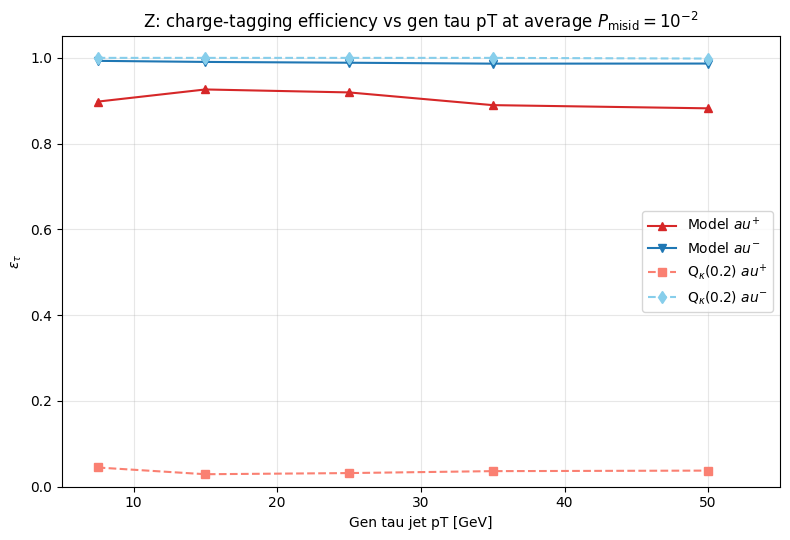

In [149]:
def compute_binned_charge_efficiencies(values, bins, score, true_charge_signed, threshold):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pred_charge_signed = np.where(score >= threshold, 1, -1)

    pos_eff = []
    neg_eff = []
    for low, high in zip(bins[:-1], bins[1:]):
        in_bin = (values >= low) & (values < high)

        pos_mask = in_bin & (true_charge_signed == 1)
        neg_mask = in_bin & (true_charge_signed == -1)

        pos_eff.append(np.mean(pred_charge_signed[pos_mask] == 1) if np.any(pos_mask) else np.nan)
        neg_eff.append(np.mean(pred_charge_signed[neg_mask] == -1) if np.any(neg_mask) else np.nan)

    return centers, np.asarray(pos_eff), np.asarray(neg_eff)

z_model_wp = z_avg_fake_operating_points['model']['threshold']
z_qk_wp = z_avg_fake_operating_points['qk']['threshold']

centers, z_model_pos_eff, z_model_neg_eff = compute_binned_charge_efficiencies(
    ak.to_numpy(to_p4(z_raw_data.gen_jet_tau_p4s).pt), compare_gen_pt_bins, z_result['pred'], z_true_charge_signed, z_model_wp
)
_, z_qk_pos_eff, z_qk_neg_eff = compute_binned_charge_efficiencies(
    ak.to_numpy(to_p4(z_raw_data.gen_jet_tau_p4s).pt), compare_gen_pt_bins, z_qk, z_true_charge_signed, z_qk_wp
)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(centers, z_model_pos_eff, marker='^', color='tab:red', label='Model $\tau^{+}$')
ax.plot(centers, z_model_neg_eff, marker='v', color='tab:blue', label='Model $\tau^{-}$')
ax.plot(centers, z_qk_pos_eff, marker='s', linestyle='--', color='salmon', label='Q$_\kappa$(0.2) $\tau^{+}$')
ax.plot(centers, z_qk_neg_eff, marker='d', linestyle='--', color='skyblue', label='Q$_\kappa$(0.2) $\tau^{-}$')
ax.set_xlabel('Gen tau jet pT [GeV]')
ax.set_ylabel(r'$\epsilon_\tau$')
ax.set_title(r'Z: charge-tagging efficiency vs gen tau pT at average $P_{\mathrm{misid}} = 10^{-2}$')
ax.set_ylim(0.0, 1.05)
ax.set_xlim(*z_pt_plot_xlim)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


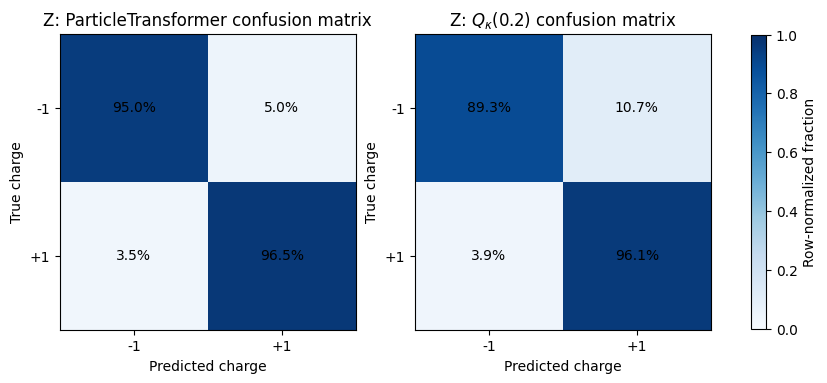

In [150]:
# Z-only normalized confusion matrices at the default decision threshold.
from sklearn.metrics import confusion_matrix

z_true_charge_labels = np.where(z_true_charge_signed == 1, '+1', '-1')
z_model_pred_labels = np.where(np.asarray(z_result['pred']) >= 0.5, '+1', '-1')
z_qk_pred_labels = np.where(np.asarray(z_qk) >= 0.0, '+1', '-1')

cm_model = confusion_matrix(z_true_charge_labels, z_model_pred_labels, labels=['-1', '+1'], normalize='true')
cm_qk = confusion_matrix(z_true_charge_labels, z_qk_pred_labels, labels=['-1', '+1'], normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
for ax, cm, title in [
    (axes[0], cm_model, 'Z: ParticleTransformer confusion matrix'),
    (axes[1], cm_qk, rf'Z: $Q_\kappa({best_kappa_label})$ confusion matrix'),
]:
    im = ax.imshow(cm, vmin=0.0, vmax=1.0, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['-1', '+1'])
    ax.set_yticklabels(['-1', '+1'])
    ax.set_xlabel('Predicted charge')
    ax.set_ylabel('True charge')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            ax.text(j, i, f'{100.0 * value:.1f}%', ha='center', va='center', color='black')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label='Row-normalized fraction')
# plt.tight_layout()
plt.show()


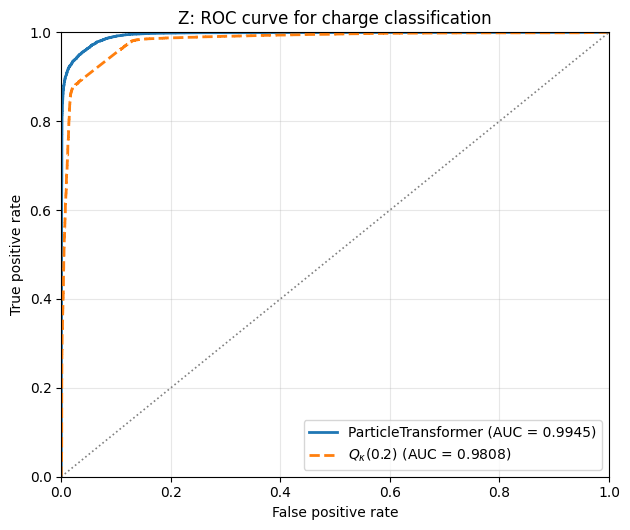

In [151]:
# Z-only ROC comparison: ParticleTransformer vs Q_kappa(0.2).
from sklearn.metrics import roc_curve, roc_auc_score

z_true_binary = np.asarray(z_result['target']).astype(int)
z_model_score = np.asarray(z_result['pred'])
z_qk_score = np.asarray(z_qk)

fpr_model, tpr_model, _ = roc_curve(z_true_binary, z_model_score)
fpr_qk, tpr_qk, _ = roc_curve(z_true_binary, z_qk_score)
auc_model = roc_auc_score(z_true_binary, z_model_score)
auc_qk = roc_auc_score(z_true_binary, z_qk_score)

plt.figure(figsize=(6.4, 5.4))
plt.plot(fpr_model, tpr_model, color='tab:blue', lw=2.0, label=f'ParticleTransformer (AUC = {auc_model:.4f})')
plt.plot(fpr_qk, tpr_qk, color='tab:orange', lw=2.0, linestyle='--', label=rf'$Q_\kappa({best_kappa_label})$ (AUC = {auc_qk:.4f})')
plt.plot([0, 1], [0, 1], color='0.5', lw=1.2, linestyle=':')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Z: ROC curve for charge classification')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [152]:
# Standalone evaluation block for the new 260323 charge-classification checkpoint run.
# This model was trained in the separate `ml-tau-model` repository, so bootstrap that package here.

import sys
import importlib.util
from pathlib import Path
import torch

run260323_repo = Path('/home/norman/ml-tau/ml-tau-model').resolve()
run260323_package_dir = run260323_repo / 'mltau'
if not run260323_package_dir.exists():
    raise FileNotFoundError(f'Could not find mltau package at {run260323_package_dir}')
if str(run260323_repo) not in sys.path:
    sys.path.insert(0, str(run260323_repo))
importlib.invalidate_caches()
if 'mltau' not in sys.modules:
    mltau_spec = importlib.util.spec_from_file_location(
        'mltau',
        run260323_package_dir / '__init__.py',
        submodule_search_locations=[str(run260323_package_dir)],
    )
    mltau_module = importlib.util.module_from_spec(mltau_spec)
    sys.modules['mltau'] = mltau_module
    mltau_spec.loader.exec_module(mltau_module)

from omegaconf import OmegaConf
from mltau.models.SingleParTau_module import ParTauModule
from mltau.tools.io.ParT_dataloader import ParticleTransformerDataset
from mltau.tools.io.general import load_row_groups

import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('default')
mpl.rcParams.update(mpl.rcParamsDefault)


run260323_dir = Path('/home/norman/ml-tau/training_outputs/260323')
run260323_model_dir = run260323_dir / 'models'
run260323_label = '260323'
run260323_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

run260323_cfg = OmegaConf.merge(
    OmegaConf.load(run260323_repo / 'mltau/config/main.yaml'),
    OmegaConf.load(run260323_repo / 'mltau/config/dataset.yaml'),
    OmegaConf.load(run260323_repo / 'mltau/config/training.yaml'),
)
run260323_cfg.training.model.name = 'SingleParTau'
run260323_cfg.training.model.task = 'charge'
run260323_test_path = str(Path(run260323_cfg.dataset.data_dir) / 'z_test.parquet')

run260323_pt_bins = compare_gen_pt_bins if 'compare_gen_pt_bins' in globals() else np.array([5, 10, 20, 30, 40, 60, 80, 120, 200], dtype=float)
run260323_eta_bins = compare_eta_bins if 'compare_eta_bins' in globals() else np.array([-2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5], dtype=float)
run260323_pt_plot_xlim = (run260323_pt_bins[0], 100.0)

def _to_float_score(x):
    if x is None:
        return None
    if hasattr(x, 'item'):
        return float(x.item())
    return float(x)

def find_best_checkpoint_from_callback_score(model_dir: Path):
    ckpt_paths = sorted(model_dir.glob('*.ckpt'))
    if not ckpt_paths:
        raise FileNotFoundError(f'No checkpoints found in {model_dir}')

    rows = []
    for ckpt_path in ckpt_paths:
        payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        epoch = payload.get('epoch', None)
        callbacks = payload.get('callbacks', {})
        score = None
        monitor = None
        mode = 'min'
        for state in callbacks.values():
            if isinstance(state, dict) and state.get('current_score', None) is not None:
                score = _to_float_score(state.get('current_score'))
                monitor = state.get('monitor', monitor)
                mode = state.get('mode', mode)
                break
        rows.append({'path': str(ckpt_path), 'epoch': epoch, 'score': score, 'monitor': monitor, 'mode': mode})

    ckpt_table = pd.DataFrame(rows).sort_values(['epoch', 'path']).reset_index(drop=True)
    scored = ckpt_table[ckpt_table['score'].notna()].copy()
    if len(scored) > 0:
        mode = scored.iloc[0]['mode'] if 'mode' in scored.columns else 'min'
        ascending = (mode != 'max')
        best_row = scored.sort_values(['score', 'epoch'], ascending=[ascending, True]).iloc[0]
    else:
        best_row = ckpt_table.sort_values('epoch', ascending=False).iloc[0]
    return ckpt_table, best_row

run260323_checkpoint_table, run260323_best_ckpt_row = find_best_checkpoint_from_callback_score(run260323_model_dir)
run260323_best_ckpt = run260323_best_ckpt_row['path']

display(run260323_checkpoint_table.head())
display(pd.DataFrame([run260323_best_ckpt_row]))
print('Test parquet:', run260323_test_path)
print('Using checkpoint:', run260323_best_ckpt)


,path,epoch,score,monitor,mode
0,/home/norman/ml-tau/training_outputs/260323/mo...,0,None,None,min
1,/home/norman/ml-tau/training_outputs/260323/mo...,1,None,None,min
2,/home/norman/ml-tau/training_outputs/260323/mo...,2,None,None,min
3,/home/norman/ml-tau/training_outputs/260323/mo...,3,None,None,min
4,/home/norman/ml-tau/training_outputs/260323/mo...,4,None,None,min


,path,epoch,score,monitor,mode
149,/home/norman/ml-tau/training_outputs/260323/mo...,149,None,None,min


Test parquet: /scratch/persistent/norman/ml-tau/cld/v1.2.5_key4hep_2025-05-29/260325/z_test.parquet
Using checkpoint: /home/norman/ml-tau/training_outputs/260323/models/ParT-epoch=149-val_loss=0.00.ckpt


In [153]:
# Run inference for the best 260323 checkpoint on the chosen Z test parquet.

from torch.utils.data import DataLoader

run260323_row_groups = load_row_groups(run260323_test_path)
run260323_dataset = ParticleTransformerDataset(run260323_row_groups, device='cpu', cfg=run260323_cfg)
run260323_loader = DataLoader(
    run260323_dataset,
    batch_size=run260323_cfg.training.dataloader.batch_size,
    num_workers=run260323_cfg.training.dataloader.num_dataloader_workers,
)

run260323_module = ParTauModule.load_from_checkpoint(
    run260323_best_ckpt,
    cfg=run260323_cfg,
    input_dim=13,
    num_dm_classes=6,
    task='charge',
    map_location=run260323_device,
)
run260323_module = run260323_module.to(run260323_device)
run260323_module.eval()

@torch.no_grad()
def run260323_predict_scores(module, loader):
    pred_chunks = []
    target_chunks = []
    for batch in loader:
        predictions, targets, _weights = module.forward(batch)
        scores = predictions['charge']
        pred_chunks.append(scores.detach().cpu().numpy())
        target_chunks.append(targets['charge'].detach().cpu().numpy())
    return np.concatenate(pred_chunks), np.concatenate(target_chunks)

run260323_scores, run260323_targets = run260323_predict_scores(run260323_module, run260323_loader)

run260323_raw_data = ak.from_parquet(run260323_test_path)
if len(run260323_raw_data) != len(run260323_scores):
    raise ValueError(f'Length mismatch: raw_data={len(run260323_raw_data)} vs predictions={len(run260323_scores)}')

run260323_result = {
    'pred': np.asarray(run260323_scores),
    'target': np.asarray(run260323_targets).astype(int),
}
run260323_true_charge_signed = np.where(run260323_result['target'] == 1, 1, -1)
run260323_pf_charges = run260323_raw_data.reco_cand_charge
run260323_pf_pts = to_p4(run260323_raw_data.reco_cand_p4s).pt
run260323_jet_pts = to_p4(run260323_raw_data.reco_jet_p4s).pt
run260323_qk = jet_charge_qkappa(run260323_pf_charges, run260323_pf_pts, run260323_jet_pts, kappa=best_kappa)
run260323_D_qk = np.clip(0.5 * (np.asarray(run260323_qk) + 1.0), 0.0, 1.0)
run260323_gen_tau_pt_values = ak.to_numpy(to_p4(run260323_raw_data.gen_jet_tau_p4s).pt)
run260323_gen_tau_eta_values = ak.to_numpy(to_p4(run260323_raw_data.gen_jet_tau_p4s).eta)

print('Loaded', len(run260323_result['pred']), 'jets for', run260323_label)


There are 128,385 jets in the dataset.


RuntimeError: Error(s) in loading state_dict for ParTauModule:
	size mismatch for ParTau.binary_head.weight: copying a param with shape torch.Size([1, 256]) from checkpoint, the shape in current model is torch.Size([2, 256]).
	size mismatch for ParTau.binary_head.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current model is torch.Size([2]).

In [ ]:

# Charge-discriminant shape D for the 260323 model vs Q_kappa(0.2).
run260323_D_model = np.asarray(run260323_result['pred'])
run260323_bins_D = np.linspace(0.0, 1.0, 21)

plt.figure(figsize=(6.4, 5.8))
plt.hist(run260323_D_model[run260323_true_charge_signed == 1], bins=run260323_bins_D, density=True, histtype='step', linestyle='--', linewidth=1.8, color='red', label=r'Model $	au^{+}$')
plt.hist(run260323_D_model[run260323_true_charge_signed == -1], bins=run260323_bins_D, density=True, histtype='step', linestyle='--', linewidth=1.8, color='blue', label=r'Model $	au^{-}$')
plt.hist(run260323_D_qk[run260323_true_charge_signed == 1], bins=run260323_bins_D, density=True, histtype='step', linestyle='--', linewidth=1.5, color='grey', label=rf'$Q_\kappa({best_kappa_label})$ $	au^{{+}}$')
plt.hist(run260323_D_qk[run260323_true_charge_signed == -1], bins=run260323_bins_D, density=True, histtype='step', linestyle='--', linewidth=1.5, color='black', label=rf'$Q_\kappa({best_kappa_label})$ $	au^{{-}}$')
plt.xlabel('D')
plt.ylabel('Relative yield / bin')
plt.title('Charge-discriminant shape: 260323 model vs Q_kappa')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# Fakerate vs efficiency for the 260323 model vs Q_kappa(0.2).
run260323_thresholds = np.linspace(0.0, 1.0, 2001)
run260323_qk_thresholds = np.linspace(np.min(run260323_qk), np.max(run260323_qk), 2001)

run260323_model_curve = compute_average_efficiency_and_fake_curve(np.asarray(run260323_result['pred']), run260323_true_charge_signed, run260323_thresholds)
run260323_qk_curve = compute_average_efficiency_and_fake_curve(np.asarray(run260323_qk), run260323_true_charge_signed, run260323_qk_thresholds)

plt.figure(figsize=(6.8, 5.4))
plt.plot(run260323_model_curve['eff_pos'], run260323_model_curve['fake_pos_from_neg'], linestyle='None', marker='s', markersize=4.5, color='red', label='Model $\tau^{+}$')
plt.plot(run260323_model_curve['eff_neg'], run260323_model_curve['fake_neg_from_pos'], linestyle='None', marker='^', markersize=4.5, color='blue', label='Model $\tau^{-}$')
plt.plot(run260323_qk_curve['eff_pos'], run260323_qk_curve['fake_pos_from_neg'], linestyle='None', marker='s', markersize=4.0, markerfacecolor='none', markeredgecolor='salmon', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
plt.plot(run260323_qk_curve['eff_neg'], run260323_qk_curve['fake_neg_from_pos'], linestyle='None', marker='^', markersize=4.0, markerfacecolor='none', markeredgecolor='skyblue', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel(r'$\epsilon_{	au}$')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title('Fakerate vs efficiency: 260323 model vs Q_kappa')
plt.yscale('log')
plt.xlim(0.0, 1.0)
plt.ylim(1e-5, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# Truth-matched charge-tagging efficiency vs gen tau pT (score cut = 0.50) for the 260323 model.
run260323_eff_vs_pt_pos = []
run260323_eff_vs_pt_neg = []
run260323_centers_pt = 0.5 * (run260323_pt_bins[:-1] + run260323_pt_bins[1:])
run260323_pred_charge_signed = np.where(np.asarray(run260323_result['pred']) >= 0.5, 1, -1)
for low, high in zip(run260323_pt_bins[:-1], run260323_pt_bins[1:]):
    in_bin = (run260323_gen_tau_pt_values >= low) & (run260323_gen_tau_pt_values < high)
    pos_mask = in_bin & (run260323_true_charge_signed == 1)
    neg_mask = in_bin & (run260323_true_charge_signed == -1)
    run260323_eff_vs_pt_pos.append(np.mean(run260323_pred_charge_signed[pos_mask] == 1) if np.any(pos_mask) else np.nan)
    run260323_eff_vs_pt_neg.append(np.mean(run260323_pred_charge_signed[neg_mask] == -1) if np.any(neg_mask) else np.nan)

plt.figure(figsize=(7.0, 5.2))
plt.plot(run260323_centers_pt, run260323_eff_vs_pt_pos, marker='^', color='red', label='True +1 tagged as +1')
plt.plot(run260323_centers_pt, run260323_eff_vs_pt_neg, marker='s', color='blue', label='True -1 tagged as -1')
plt.xlabel('Gen tau jet pT [GeV]')
plt.ylabel(r'$\epsilon_	au$')
plt.title('Truth-matched charge-tagging efficiency vs gen tau pT (260323, score cut = 0.50)')
plt.xlim(*run260323_pt_plot_xlim)
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:

# Truth-matched charge-tagging efficiency vs gen tau eta (score cut = 0.50) for the 260323 model.
run260323_eff_vs_eta_pos = []
run260323_eff_vs_eta_neg = []
run260323_centers_eta = 0.5 * (run260323_eta_bins[:-1] + run260323_eta_bins[1:])
for low, high in zip(run260323_eta_bins[:-1], run260323_eta_bins[1:]):
    in_bin = (run260323_gen_tau_eta_values >= low) & (run260323_gen_tau_eta_values < high)
    pos_mask = in_bin & (run260323_true_charge_signed == 1)
    neg_mask = in_bin & (run260323_true_charge_signed == -1)
    run260323_eff_vs_eta_pos.append(np.mean(run260323_pred_charge_signed[pos_mask] == 1) if np.any(pos_mask) else np.nan)
    run260323_eff_vs_eta_neg.append(np.mean(run260323_pred_charge_signed[neg_mask] == -1) if np.any(neg_mask) else np.nan)

plt.figure(figsize=(7.0, 5.2))
plt.plot(run260323_centers_eta, run260323_eff_vs_eta_pos, marker='^', color='red', label='True +1 tagged as +1')
plt.plot(run260323_centers_eta, run260323_eff_vs_eta_neg, marker='s', color='blue', label='True -1 tagged as -1')
plt.xlabel('Gen tau jet eta')
plt.ylabel(r'$\epsilon_	au$')
plt.title('Truth-matched charge-tagging efficiency vs gen tau eta (260323, score cut = 0.50)')
plt.xlim(run260323_eta_bins[0], run260323_eta_bins[-1])
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:

# Truth-matched wrong-sign fake rate vs gen tau pT (score cut = 0.50) for the 260323 model.
run260323_fake_vs_pt_pos = []
run260323_fake_vs_pt_neg = []
for low, high in zip(run260323_pt_bins[:-1], run260323_pt_bins[1:]):
    in_bin = (run260323_gen_tau_pt_values >= low) & (run260323_gen_tau_pt_values < high)
    neg_mask = in_bin & (run260323_true_charge_signed == -1)
    pos_mask = in_bin & (run260323_true_charge_signed == 1)
    run260323_fake_vs_pt_pos.append(np.mean(run260323_pred_charge_signed[neg_mask] == 1) if np.any(neg_mask) else np.nan)
    run260323_fake_vs_pt_neg.append(np.mean(run260323_pred_charge_signed[pos_mask] == -1) if np.any(pos_mask) else np.nan)

plt.figure(figsize=(7.0, 5.2))
plt.plot(run260323_centers_pt, run260323_fake_vs_pt_pos, marker='^', color='red', label='True -1 tagged as +1')
plt.plot(run260323_centers_pt, run260323_fake_vs_pt_neg, marker='s', color='blue', label='True +1 tagged as -1')
plt.xlabel('Gen tau jet pT [GeV]')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title('Truth-matched wrong-sign fake rate vs gen tau pT (260323, score cut = 0.50)')
plt.xlim(*run260323_pt_plot_xlim)
plt.yscale('log')
plt.ylim(1e-4, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:

# Truth-matched wrong-sign fake rate vs gen tau eta (score cut = 0.50) for the 260323 model.
run260323_fake_vs_eta_pos = []
run260323_fake_vs_eta_neg = []
for low, high in zip(run260323_eta_bins[:-1], run260323_eta_bins[1:]):
    in_bin = (run260323_gen_tau_eta_values >= low) & (run260323_gen_tau_eta_values < high)
    neg_mask = in_bin & (run260323_true_charge_signed == -1)
    pos_mask = in_bin & (run260323_true_charge_signed == 1)
    run260323_fake_vs_eta_pos.append(np.mean(run260323_pred_charge_signed[neg_mask] == 1) if np.any(neg_mask) else np.nan)
    run260323_fake_vs_eta_neg.append(np.mean(run260323_pred_charge_signed[pos_mask] == -1) if np.any(pos_mask) else np.nan)

plt.figure(figsize=(7.0, 5.2))
plt.plot(run260323_centers_eta, run260323_fake_vs_eta_pos, marker='^', color='red', label='True -1 tagged as +1')
plt.plot(run260323_centers_eta, run260323_fake_vs_eta_neg, marker='s', color='blue', label='True +1 tagged as -1')
plt.xlabel('Gen tau jet eta')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title('Truth-matched wrong-sign fake rate vs gen tau eta (260323, score cut = 0.50)')
plt.xlim(run260323_eta_bins[0], run260323_eta_bins[-1])
plt.yscale('log')
plt.ylim(1e-4, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:

# Average-efficiency operating point chosen from a target average fake rate for the 260323 model.
run260323_qk_threshold_grid = np.linspace(np.min(run260323_qk), np.max(run260323_qk), 2001)
run260323_avg_fake_operating_points = {
    'model': choose_threshold_for_target_avg_fake(np.asarray(run260323_result['pred']), run260323_true_charge_signed, model_threshold_grid_compare, target_avg_fake_rate),
    'qk': choose_threshold_for_target_avg_fake(np.asarray(run260323_qk), run260323_true_charge_signed, run260323_qk_threshold_grid, target_avg_fake_rate),
}

display(pd.DataFrame({
    'model': [run260323_label],
    'model_threshold': [run260323_avg_fake_operating_points['model']['threshold']],
    'model_avg_eff': [run260323_avg_fake_operating_points['model']['avg_eff']],
    'model_avg_fake': [run260323_avg_fake_operating_points['model']['avg_fake']],
    f'qkappa_{best_kappa_label}_threshold': [run260323_avg_fake_operating_points['qk']['threshold']],
    f'qkappa_{best_kappa_label}_avg_eff': [run260323_avg_fake_operating_points['qk']['avg_eff']],
    f'qkappa_{best_kappa_label}_avg_fake': [run260323_avg_fake_operating_points['qk']['avg_fake']],
}))


In [ ]:

# Average efficiency vs gen tau pT at target average fake rate 1e-2 for the 260323 model.
run260323_avg_eff_vs_pt_model = compute_binned_average_efficiency(run260323_gen_tau_pt_values, run260323_pt_bins, np.asarray(run260323_result['pred']), run260323_true_charge_signed, run260323_avg_fake_operating_points['model']['threshold'])
run260323_avg_eff_vs_pt_qk = compute_binned_average_efficiency(run260323_gen_tau_pt_values, run260323_pt_bins, np.asarray(run260323_qk), run260323_true_charge_signed, run260323_avg_fake_operating_points['qk']['threshold'])
plt.figure(figsize=(7.0, 5.2))
plt.plot(run260323_avg_eff_vs_pt_model['centers'], run260323_avg_eff_vs_pt_model['avg_eff'], marker='^', color='tab:blue', label='ParticleTransformer')
plt.plot(run260323_avg_eff_vs_pt_qk['centers'], run260323_avg_eff_vs_pt_qk['avg_eff'], marker='s', color='tab:orange', label=rf'$Q_\kappa({best_kappa_label})$')
plt.xlabel('Gen tau jet pT [GeV]')
plt.ylabel(r'Average $\epsilon_{	au}$')
plt.title(r'Average efficiency vs gen tau pT for 260323 at target average $P_{\mathrm{misid}} = 10^{-2}$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(*run260323_pt_plot_xlim)
plt.ylim(0.0, 1.0)
plt.show()


In [ ]:

# Average efficiency vs gen tau eta at target average fake rate 1e-2 for the 260323 model.
run260323_avg_eff_vs_eta_model = compute_binned_average_efficiency(run260323_gen_tau_eta_values, run260323_eta_bins, np.asarray(run260323_result['pred']), run260323_true_charge_signed, run260323_avg_fake_operating_points['model']['threshold'])
run260323_avg_eff_vs_eta_qk = compute_binned_average_efficiency(run260323_gen_tau_eta_values, run260323_eta_bins, np.asarray(run260323_qk), run260323_true_charge_signed, run260323_avg_fake_operating_points['qk']['threshold'])
plt.figure(figsize=(7.0, 5.2))
plt.plot(run260323_avg_eff_vs_eta_model['centers'], run260323_avg_eff_vs_eta_model['avg_eff'], marker='^', color='tab:blue', label='ParticleTransformer')
plt.plot(run260323_avg_eff_vs_eta_qk['centers'], run260323_avg_eff_vs_eta_qk['avg_eff'], marker='s', color='tab:orange', label=rf'$Q_\kappa({best_kappa_label})$')
plt.xlabel('Gen tau jet eta')
plt.ylabel(r'Average $\epsilon_{	au}$')
plt.title(r'Average efficiency vs gen tau eta for 260323 at target average $P_{\mathrm{misid}} = 10^{-2}$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(run260323_eta_bins[0], run260323_eta_bins[-1])
plt.ylim(0.0, 1.0)
plt.show()


In [ ]:

# Charge-separated efficiency vs gen tau pT at target average fake rate 1e-2 for the 260323 model.
run260323_model_wp = run260323_avg_fake_operating_points['model']['threshold']
run260323_qk_wp = run260323_avg_fake_operating_points['qk']['threshold']
run260323_centers, run260323_model_pos_eff, run260323_model_neg_eff = compute_binned_charge_efficiencies(run260323_gen_tau_pt_values, run260323_pt_bins, run260323_result['pred'], run260323_true_charge_signed, run260323_model_wp)
_, run260323_qk_pos_eff, run260323_qk_neg_eff = compute_binned_charge_efficiencies(run260323_gen_tau_pt_values, run260323_pt_bins, run260323_qk, run260323_true_charge_signed, run260323_qk_wp)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(run260323_centers, run260323_model_pos_eff, marker='^', color='tab:red', label='Model $\tau^{+}$')
ax.plot(run260323_centers, run260323_model_neg_eff, marker='v', color='tab:blue', label='Model $\tau^{-}$')
ax.plot(run260323_centers, run260323_qk_pos_eff, marker='s', linestyle='--', color='tab:orange', label='Q$_\kappa$(0.2) $\tau^{+}$')
ax.plot(run260323_centers, run260323_qk_neg_eff, marker='d', linestyle='--', color='tab:green', label='Q$_\kappa$(0.2) $\tau^{-}$')
ax.set_xlabel('Gen tau jet pT [GeV]')
ax.set_ylabel(r'$\epsilon_\tau$')
ax.set_title(r'260323: charge-tagging efficiency vs gen tau pT at average $P_{\mathrm{misid}} = 10^{-2}$')
ax.set_ylim(0.0, 1.05)
ax.set_xlim(*run260323_pt_plot_xlim)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:

# Charge-separated efficiency vs gen tau eta at target average fake rate 1e-2 for the 260323 model.
run260323_centers_eta_sep, run260323_model_pos_eff_eta, run260323_model_neg_eff_eta = compute_binned_charge_efficiencies(run260323_gen_tau_eta_values, run260323_eta_bins, run260323_result['pred'], run260323_true_charge_signed, run260323_model_wp)
_, run260323_qk_pos_eff_eta, run260323_qk_neg_eff_eta = compute_binned_charge_efficiencies(run260323_gen_tau_eta_values, run260323_eta_bins, run260323_qk, run260323_true_charge_signed, run260323_qk_wp)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(run260323_centers_eta_sep, run260323_model_pos_eff_eta, marker='^', color='tab:red', label='Model $\tau^{+}$')
ax.plot(run260323_centers_eta_sep, run260323_model_neg_eff_eta, marker='v', color='tab:blue', label='Model $\tau^{-}$')
ax.plot(run260323_centers_eta_sep, run260323_qk_pos_eff_eta, marker='s', linestyle='--', color='tab:orange', label='Q$_\kappa$(0.2) $\tau^{+}$')
ax.plot(run260323_centers_eta_sep, run260323_qk_neg_eff_eta, marker='d', linestyle='--', color='tab:green', label='Q$_\kappa$(0.2) $\tau^{-}$')
ax.set_xlabel('Gen tau jet eta')
ax.set_ylabel(r'$\epsilon_\tau$')
ax.set_title(r'260323: charge-tagging efficiency vs gen tau eta at average $P_{\mathrm{misid}} = 10^{-2}$')
ax.set_ylim(0.0, 1.05)
ax.set_xlim(run260323_eta_bins[0], run260323_eta_bins[-1])
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:

# Confusion matrices for the 260323 model and Q_kappa(0.2).
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

run260323_true_labels = np.where(run260323_true_charge_signed == 1, '+1', '-1')
run260323_model_pred_labels = np.where(np.asarray(run260323_result['pred']) >= 0.5, '+1', '-1')
run260323_qk_pred_labels = np.where(np.asarray(run260323_qk) >= 0.0, '+1', '-1')

run260323_cm_model = confusion_matrix(run260323_true_labels, run260323_model_pred_labels, labels=['-1', '+1'], normalize='true')
run260323_cm_qk = confusion_matrix(run260323_true_labels, run260323_qk_pred_labels, labels=['-1', '+1'], normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
for ax, cm, title in [
    (axes[0], run260323_cm_model, '260323: ParticleTransformer confusion matrix'),
    (axes[1], run260323_cm_qk, rf'260323: $Q_\kappa({best_kappa_label})$ confusion matrix'),
]:
    im = ax.imshow(cm, vmin=0.0, vmax=1.0, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['-1', '+1'])
    ax.set_yticklabels(['-1', '+1'])
    ax.set_xlabel('Predicted charge')
    ax.set_ylabel('True charge')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{100.0 * cm[i, j]:.1f}%', ha='center', va='center', color='black')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label='Row-normalized fraction')
plt.tight_layout()
plt.show()


In [ ]:

# ROC curve for the 260323 model vs Q_kappa(0.2).
run260323_true_binary = np.asarray(run260323_result['target']).astype(int)
run260323_model_score = np.asarray(run260323_result['pred'])
run260323_qk_score = np.asarray(run260323_qk)

run260323_fpr_model, run260323_tpr_model, _ = roc_curve(run260323_true_binary, run260323_model_score)
run260323_fpr_qk, run260323_tpr_qk, _ = roc_curve(run260323_true_binary, run260323_qk_score)
run260323_auc_model = roc_auc_score(run260323_true_binary, run260323_model_score)
run260323_auc_qk = roc_auc_score(run260323_true_binary, run260323_qk_score)

plt.figure(figsize=(6.4, 5.4))
plt.plot(run260323_fpr_model, run260323_tpr_model, color='tab:blue', lw=2.0, label=f'ParticleTransformer (AUC = {run260323_auc_model:.4f})')
plt.plot(run260323_fpr_qk, run260323_tpr_qk, color='tab:orange', lw=2.0, linestyle='--', label=rf'$Q_\kappa({best_kappa_label})$ (AUC = {run260323_auc_qk:.4f})')
plt.plot([0, 1], [0, 1], color='0.5', lw=1.2, linestyle=':')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('260323: ROC curve for charge classification')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import torch

In [233]:

# Reset matplotlib to the default style for the current notebook session.
# Run this once, then rerun any earlier plot cells that were affected by the mplhep CMS style.
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('default')
mpl.rcParams.update(mpl.rcParamsDefault)
print('Matplotlib style reset to default.')


Matplotlib style reset to default.


## 260325 charge checkpoint evaluation (ml-tau-model)

This block evaluates the `ml-tau-model` single-task charge checkpoint `ParT-model_best.ckpt` on the Z-only test parquet and compares it against the pt-weighted jet-charge baseline $Q_\kappa$ with $\kappa \in [0, 1]$. The baseline operating point is chosen by the best AUC in that scan.


In [234]:
# Standalone evaluation block for the 260325 charge-classification checkpoint.
# This model was trained in the separate `ml-tau-model` repository.

import sys
import importlib.util
from pathlib import Path
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, roc_auc_score
from omegaconf import OmegaConf

run260325_root_candidates = [
    Path('/home/norman/ml-tau'),
    Path('/home/norman/manivald-home/ml-tau'),
]
run260325_workspace = next((p for p in run260325_root_candidates if (p / 'ml-tau-model').exists()), run260325_root_candidates[-1])
run260325_repo = (run260325_workspace / 'ml-tau-model').resolve()
run260325_package_dir = run260325_repo / 'mltau'
if not run260325_package_dir.exists():
    raise FileNotFoundError(f'Could not find mltau package at {run260325_package_dir}')
if str(run260325_repo) not in sys.path:
    sys.path.insert(0, str(run260325_repo))
importlib.invalidate_caches()
if 'mltau' not in sys.modules:
    mltau_spec = importlib.util.spec_from_file_location(
        'mltau',
        run260325_package_dir / '__init__.py',
        submodule_search_locations=[str(run260325_package_dir)],
    )
    mltau_module = importlib.util.module_from_spec(mltau_spec)
    sys.modules['mltau'] = mltau_module
    mltau_spec.loader.exec_module(mltau_module)

from mltau.models.SingleParTau_module import ParTauModule
from mltau.tools.io.ParT_dataloader import ParticleTransformerDataset
from mltau.tools.io.general import load_row_groups

run260325_checkpoint_candidates = [
    Path('/home/norman/ml-tau/training_outputs/260325/models/ParT-model_best.ckpt'),
    run260325_workspace / 'training_outputs/260325/models/ParT-model_best.ckpt',
]
run260325_checkpoint = next((p for p in run260325_checkpoint_candidates if p.exists()), run260325_checkpoint_candidates[0])
run260325_test_path = '/scratch/persistent/norman/ml-tau/cld/v1.2.5_key4hep_2025-05-29/260325/z_test.parquet'
run260325_label = '260325 charge'
run260325_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

run260325_cfg = OmegaConf.merge(
    OmegaConf.load(run260325_repo / 'mltau/config/main.yaml'),
    OmegaConf.load(run260325_repo / 'mltau/config/dataset.yaml'),
    OmegaConf.load(run260325_repo / 'mltau/config/training.yaml'),
)
run260325_cfg.training.model.name = 'SingleParTau'
run260325_cfg.training.model.task = 'charge'
run260325_cfg.training.dataloader.num_dataloader_workers = 0

run260325_pt_bins = compare_gen_pt_bins if 'compare_gen_pt_bins' in globals() else np.array([5, 10, 20, 30, 40, 60, 80, 120, 200], dtype=float)
run260325_pt_plot_xlim = (run260325_pt_bins[0], 60.0)
run260325_target_avg_fake_rate = 1e-2
run260325_model_threshold_grid = np.linspace(0.0, 1.0, 2001)


def compute_average_efficiency_and_fake_curve(score, true_charge_signed, thresholds):
    pos_mask = true_charge_signed == 1
    neg_mask = true_charge_signed == -1
    avg_eff = []
    avg_fake = []
    eff_pos = []
    eff_neg = []
    fake_pos_from_neg = []
    fake_neg_from_pos = []

    for thr in thresholds:
        pred_pos = score >= thr
        pred_neg = 1 - score > thr

        eps_pos = np.mean(pred_pos[pos_mask]) if np.any(pos_mask) else np.nan
        eps_neg = np.mean(pred_neg[neg_mask]) if np.any(neg_mask) else np.nan
        fake_pos = np.mean(pred_pos[neg_mask]) if np.any(neg_mask) else np.nan
        fake_neg = np.mean(pred_neg[pos_mask]) if np.any(pos_mask) else np.nan

        eff_pos.append(eps_pos)
        eff_neg.append(eps_neg)
        fake_pos_from_neg.append(fake_pos)
        fake_neg_from_pos.append(fake_neg)
        avg_eff.append(0.5 * (eps_pos + eps_neg))
        avg_fake.append(0.5 * (fake_pos + fake_neg))

    return {
        'thresholds': np.asarray(thresholds),
        'avg_eff': np.asarray(avg_eff),
        'avg_fake': np.asarray(avg_fake),
        'eff_pos': np.asarray(eff_pos),
        'eff_neg': np.asarray(eff_neg),
        'fake_pos_from_neg': np.asarray(fake_pos_from_neg),
        'fake_neg_from_pos': np.asarray(fake_neg_from_pos),
    }


def choose_threshold_for_target_avg_fake(score, true_charge_signed, thresholds, target_avg_fake_rate):
    curve = compute_average_efficiency_and_fake_curve(score, true_charge_signed, thresholds)
    valid = np.isfinite(curve['avg_eff']) & np.isfinite(curve['avg_fake'])

    if not np.any(valid):
        raise ValueError('No finite operating points were found for the supplied score array.')

    # Choose the operating point whose average fake rate is closest to the target.
    valid_indices = np.where(valid)[0]
    distances = np.abs(curve['avg_fake'][valid_indices] - target_avg_fake_rate)
    best_idx = valid_indices[np.argmin(distances)]

    return {
        'threshold': curve['thresholds'][best_idx],
        'avg_eff': curve['avg_eff'][best_idx],
        'avg_fake': curve['avg_fake'][best_idx],
        'eff_pos': curve['eff_pos'][best_idx],
        'eff_neg': curve['eff_neg'][best_idx],
        'fake_pos_from_neg': curve['fake_pos_from_neg'][best_idx],
        'fake_neg_from_pos': curve['fake_neg_from_pos'][best_idx],
        'curve': curve,
    }


def compute_binned_charge_efficiencies(values, bins, score, true_charge_signed, threshold):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pred_charge_signed = np.where(score >= threshold, 1, -1)

    pos_eff = []
    neg_eff = []
    for low, high in zip(bins[:-1], bins[1:]):
        in_bin = (values >= low) & (values < high)
        pos_mask = in_bin & (true_charge_signed == 1)
        neg_mask = in_bin & (true_charge_signed == -1)
        pos_eff.append(np.mean(pred_charge_signed[pos_mask] == 1) if np.any(pos_mask) else np.nan)
        neg_eff.append(np.mean(pred_charge_signed[neg_mask] == -1) if np.any(neg_mask) else np.nan)

    return centers, np.asarray(pos_eff), np.asarray(neg_eff)



def compute_binned_charge_fake_rates(values, bins, score, true_charge_signed, threshold):
    centers = 0.5 * (bins[:-1] + bins[1:])
    pred_charge_signed = np.where(score >= threshold, 1, -1)

    fake_pos = []
    fake_neg = []
    for low, high in zip(bins[:-1], bins[1:]):
        in_bin = (values >= low) & (values < high)
        neg_mask = in_bin & (true_charge_signed == -1)
        pos_mask = in_bin & (true_charge_signed == 1)
        fake_pos.append(np.mean(pred_charge_signed[neg_mask] == 1) if np.any(neg_mask) else np.nan)
        fake_neg.append(np.mean(pred_charge_signed[pos_mask] == -1) if np.any(pos_mask) else np.nan)

    return centers, np.asarray(fake_pos), np.asarray(fake_neg)


def jet_charge_qkappa(charges, pts, jet_pts, kappa=0.5):
    numer = ak.sum(charges * (pts ** kappa), axis=1)
    denom = jet_pts ** kappa
    denom = ak.where(denom == 0, 1.0, denom)
    return ak.to_numpy(numer / denom)

run260325_row_groups = load_row_groups(run260325_test_path)
run260325_dataset = ParticleTransformerDataset(run260325_row_groups, device=str(run260325_device), cfg=run260325_cfg)
run260325_loader = DataLoader(
    run260325_dataset,
    batch_size=run260325_cfg.training.dataloader.batch_size,
    num_workers=0,
)

run260325_module = ParTauModule.load_from_checkpoint(
    str(run260325_checkpoint),
    cfg=run260325_cfg,
    input_dim=13,
    num_dm_classes=6,
    task='charge',
    map_location=run260325_device,
)
run260325_module = run260325_module.to(run260325_device)
run260325_module.eval()

@torch.no_grad()
def run260325_predict_scores(module, loader):
    pred_chunks = []
    target_chunks = []
    for batch in loader:
        predictions, targets, _weights = module.forward(batch)
        target_key = 'charge_enreg' if 'charge_enreg' in targets else 'charge'
        pred_chunks.append(predictions['charge'].detach().cpu().numpy())
        target_chunks.append(targets[target_key].detach().cpu().numpy())
    return np.concatenate(pred_chunks), np.concatenate(target_chunks)

run260325_scores, run260325_targets = run260325_predict_scores(run260325_module, run260325_loader)
run260325_raw_data = ak.from_parquet(run260325_test_path)
if len(run260325_raw_data) != len(run260325_scores):
    raise ValueError(f'Length mismatch: raw_data={len(run260325_raw_data)} vs predictions={len(run260325_scores)}')

run260325_result = {
    'pred': np.asarray(run260325_scores),
    'target': np.asarray(run260325_targets).astype(int),
}
run260325_true_charge_signed = np.where(run260325_result['target'] == 1, 1, -1)
run260325_true_labels = np.where(run260325_true_charge_signed == 1, '+1', '-1')
run260325_gen_tau_pt_values = ak.to_numpy(to_p4(run260325_raw_data.gen_jet_tau_p4s).pt)

run260325_pf_charges = run260325_raw_data.reco_cand_charge
run260325_pf_pts = to_p4(run260325_raw_data.reco_cand_p4s).pt
run260325_jet_pts = to_p4(run260325_raw_data.reco_jet_p4s).pt

run260325_kappa_values = np.round(np.arange(0.0, 1.01, 0.1), 2)
run260325_kappa_rows = []
run260325_qk_scores = {}
for kappa in run260325_kappa_values:
    qk = jet_charge_qkappa(run260325_pf_charges, run260325_pf_pts, run260325_jet_pts, kappa=float(kappa))
    run260325_qk_scores[float(kappa)] = qk
    run260325_kappa_rows.append({
        'kappa': float(kappa),
        'auc': roc_auc_score(run260325_result['target'], qk),
        'accuracy': np.mean((qk >= 0.0).astype(int) == run260325_result['target']),
    })

run260325_kappa_scan_df = pd.DataFrame(run260325_kappa_rows).sort_values(['auc', 'kappa'], ascending=[False, True]).reset_index(drop=True)
run260325_best_kappa = float(run260325_kappa_scan_df.loc[0, 'kappa'])
run260325_best_kappa_label = f'{run260325_best_kappa:.2f}'.rstrip('0').rstrip('.')
run260325_qk = np.asarray(run260325_qk_scores[run260325_best_kappa])
run260325_qk_threshold_grid = np.linspace(np.min(run260325_qk), np.max(run260325_qk), 2001)

print('Using checkpoint:', run260325_checkpoint)
print('Using test parquet:', run260325_test_path)
print(f'Best Q_kappa baseline by AUC on [0, 1]: kappa = {run260325_best_kappa_label}')
display(run260325_kappa_scan_df)


There are 128,385 jets in the dataset.
Using checkpoint: /home/norman/ml-tau/training_outputs/260325/models/ParT-model_best.ckpt
Using test parquet: /scratch/persistent/norman/ml-tau/cld/v1.2.5_key4hep_2025-05-29/260325/z_test.parquet
Best Q_kappa baseline by AUC on [0, 1]: kappa = 0.1


,kappa,auc,accuracy
0,0.1,0.980422,0.924454
1,0.2,0.980404,0.924430
2,0.3,0.979493,0.922390
3,0.4,0.976946,0.916236
4,0.0,0.974286,0.921260
5,0.5,0.973157,0.909250
6,0.6,0.968498,0.902987
7,0.7,0.963442,0.897932
8,0.8,0.958344,0.893695
9,0.9,0.953542,0.890338


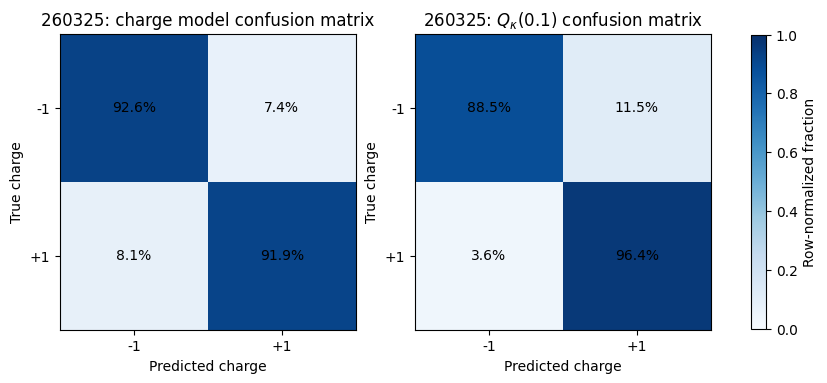

In [236]:
# Confusion matrices for the 260325 charge model and the best Q_kappa baseline.

run260325_model_pred_labels = np.where(np.asarray(run260325_result['pred']) >= 0.5, '+1', '-1')
run260325_qk_pred_labels = np.where(np.asarray(run260325_qk) >= 0.0, '+1', '-1')

run260325_cm_model = confusion_matrix(run260325_true_labels, run260325_model_pred_labels, labels=['-1', '+1'], normalize='true')
run260325_cm_qk = confusion_matrix(run260325_true_labels, run260325_qk_pred_labels, labels=['-1', '+1'], normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
for ax, cm, title in [
    (axes[0], run260325_cm_model, '260325: charge model confusion matrix'),
    (axes[1], run260325_cm_qk, rf'260325: $Q_\kappa({run260325_best_kappa_label})$ confusion matrix'),
]:
    im = ax.imshow(cm, vmin=0.0, vmax=1.0, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['-1', '+1'])
    ax.set_yticklabels(['-1', '+1'])
    ax.set_xlabel('Predicted charge')
    ax.set_ylabel('True charge')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{100.0 * cm[i, j]:.1f}%', ha='center', va='center', color='black')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label='Row-normalized fraction')
# plt.tight_layout()
plt.show()


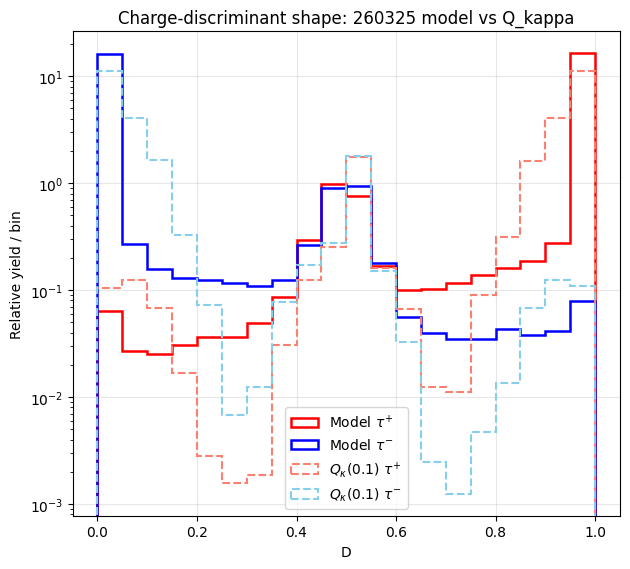

In [248]:
# Classifier-score distribution for the 260325 charge model and the best Q_kappa baseline.

run260325_D_model = np.asarray(run260325_result['pred'])
run260325_D_qk = np.clip(0.5 * (np.asarray(run260325_qk) + 1.0), 0.0, 1.0)
run260325_bins_D = np.linspace(0.0, 1.0, 21)

plt.figure(figsize=(6.4, 5.8))
plt.hist(run260325_D_model[run260325_true_charge_signed == 1], bins=run260325_bins_D, density=True, histtype='step', linestyle='-', linewidth=1.8, color='red', label=r'Model $\tau^{+}$')
plt.hist(run260325_D_model[run260325_true_charge_signed == -1], bins=run260325_bins_D, density=True, histtype='step', linestyle='-', linewidth=1.8, color='blue', label=r'Model $\tau^{-}$')
plt.hist(run260325_D_qk[run260325_true_charge_signed == 1], bins=run260325_bins_D, density=True, histtype='step', linestyle='--', linewidth=1.5, color='salmon', label=rf'$Q_\kappa({run260325_best_kappa_label})$ $\tau^{{+}}$')
plt.hist(run260325_D_qk[run260325_true_charge_signed == -1], bins=run260325_bins_D, density=True, histtype='step', linestyle='--', linewidth=1.5, color='skyblue', label=rf'$Q_\kappa({run260325_best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel('D')
plt.ylabel('Relative yield / bin')
plt.title('Charge-discriminant shape: 260325 model vs Q_kappa')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


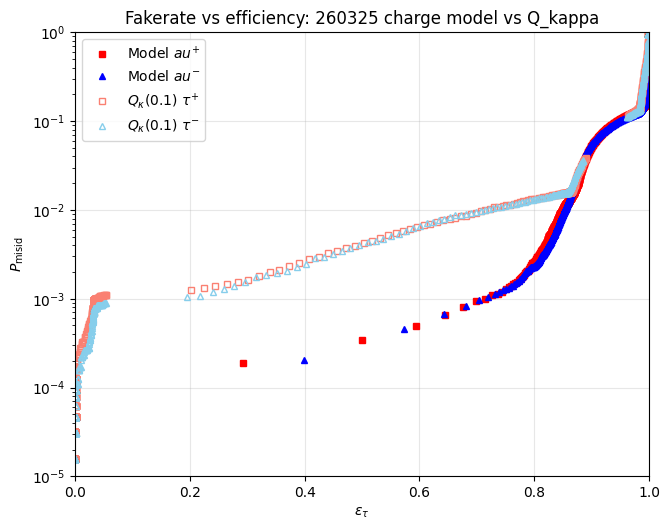

In [237]:
# Fakerate vs efficiency ROC-style plot for the 260325 charge model and the best Q_kappa baseline.

run260325_model_curve = compute_average_efficiency_and_fake_curve(np.asarray(run260325_result['pred']), run260325_true_charge_signed, run260325_model_threshold_grid)
run260325_qk_curve = compute_average_efficiency_and_fake_curve(np.asarray(run260325_qk), run260325_true_charge_signed, run260325_qk_threshold_grid)

plt.figure(figsize=(6.8, 5.4))
plt.plot(run260325_model_curve['eff_pos'], run260325_model_curve['fake_pos_from_neg'], linestyle='None', marker='s', markersize=4.5, color='red', label='Model $\tau^{+}$')
plt.plot(run260325_model_curve['eff_neg'], run260325_model_curve['fake_neg_from_pos'], linestyle='None', marker='^', markersize=4.5, color='blue', label='Model $\tau^{-}$')
plt.plot(run260325_qk_curve['eff_pos'], run260325_qk_curve['fake_pos_from_neg'], linestyle='None', marker='s', markersize=4.0, markerfacecolor='none', markeredgecolor='salmon', label=rf'$Q_\kappa({run260325_best_kappa_label})$ $\tau^{{+}}$')
plt.plot(run260325_qk_curve['eff_neg'], run260325_qk_curve['fake_neg_from_pos'], linestyle='None', marker='^', markersize=4.0, markerfacecolor='none', markeredgecolor='skyblue', label=rf'$Q_\kappa({run260325_best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel(r'$\epsilon_{\tau}$')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title('Fakerate vs efficiency: 260325 charge model vs Q_kappa')
plt.yscale('log')
plt.xlim(0.0, 1.0)
plt.ylim(1e-5, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


,model,model_threshold,model_avg_eff,model_avg_fake,qkappa_0.1_threshold,qkappa_0.1_avg_eff,qkappa_0.1_avg_fake
0,260325 charge,0.763,0.851709,0.01001,1.161922,0.449668,0.009971


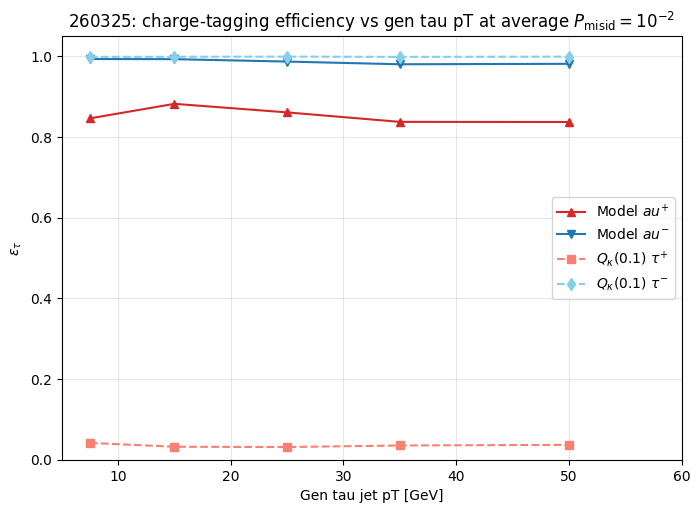

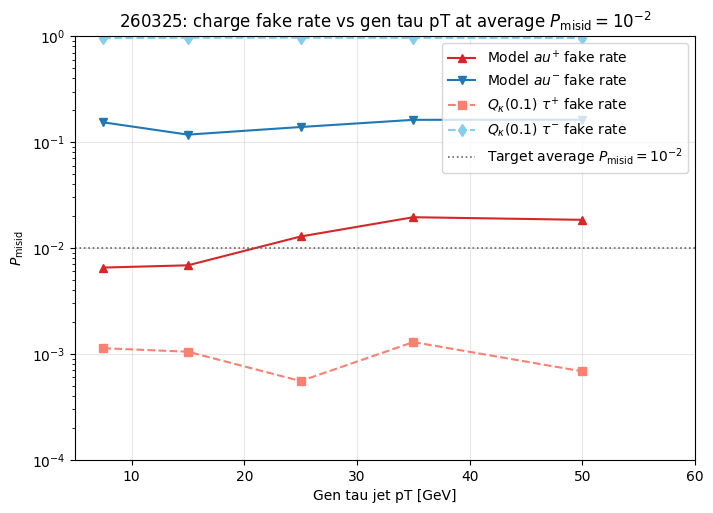

In [246]:
# Charge-separated efficiency and fake-rate vs gen tau pT at average fake rate 1e-2.

run260325_avg_fake_operating_points = {
    'model': choose_threshold_for_target_avg_fake(np.asarray(run260325_result['pred']), run260325_true_charge_signed, run260325_model_threshold_grid, run260325_target_avg_fake_rate),
    'qk': choose_threshold_for_target_avg_fake(np.asarray(run260325_qk), run260325_true_charge_signed, run260325_qk_threshold_grid, run260325_target_avg_fake_rate),
}

display(pd.DataFrame({
    'model': [run260325_label],
    'model_threshold': [run260325_avg_fake_operating_points['model']['threshold']],
    'model_avg_eff': [run260325_avg_fake_operating_points['model']['avg_eff']],
    'model_avg_fake': [run260325_avg_fake_operating_points['model']['avg_fake']],
    f'qkappa_{run260325_best_kappa_label}_threshold': [run260325_avg_fake_operating_points['qk']['threshold']],
    f'qkappa_{run260325_best_kappa_label}_avg_eff': [run260325_avg_fake_operating_points['qk']['avg_eff']],
    f'qkappa_{run260325_best_kappa_label}_avg_fake': [run260325_avg_fake_operating_points['qk']['avg_fake']],
}))

run260325_model_wp = run260325_avg_fake_operating_points['model']['threshold']
run260325_qk_wp = run260325_avg_fake_operating_points['qk']['threshold']
run260325_centers_pt, run260325_model_pos_eff, run260325_model_neg_eff = compute_binned_charge_efficiencies(run260325_gen_tau_pt_values, run260325_pt_bins, run260325_result['pred'], run260325_true_charge_signed, run260325_model_wp)
_, run260325_qk_pos_eff, run260325_qk_neg_eff = compute_binned_charge_efficiencies(run260325_gen_tau_pt_values, run260325_pt_bins, run260325_qk, run260325_true_charge_signed, run260325_qk_wp)
_, run260325_model_fake_pos, run260325_model_fake_neg = compute_binned_charge_fake_rates(run260325_gen_tau_pt_values, run260325_pt_bins, run260325_result['pred'], run260325_true_charge_signed, run260325_model_wp)
_, run260325_qk_fake_pos, run260325_qk_fake_neg = compute_binned_charge_fake_rates(run260325_gen_tau_pt_values, run260325_pt_bins, run260325_qk, run260325_true_charge_signed, run260325_qk_wp)

fig, ax = plt.subplots(figsize=(8.0, 5.5))
ax.plot(run260325_centers_pt, run260325_model_pos_eff, marker='^', color='tab:red', label='Model $\tau^{+}$')
ax.plot(run260325_centers_pt, run260325_model_neg_eff, marker='v', color='tab:blue', label='Model $\tau^{-}$')
ax.plot(run260325_centers_pt, run260325_qk_pos_eff, marker='s', linestyle='--', color='salmon', label=rf'$Q_\kappa({run260325_best_kappa_label})$ $\tau^{{+}}$')
ax.plot(run260325_centers_pt, run260325_qk_neg_eff, marker='d', linestyle='--', color='skyblue', label=rf'$Q_\kappa({run260325_best_kappa_label})$ $\tau^{{-}}$')
ax.set_xlabel('Gen tau jet pT [GeV]')
ax.set_ylabel(r'$\epsilon_\tau$')
ax.set_title(r'260325: charge-tagging efficiency vs gen tau pT at average $P_{\mathrm{misid}} = 10^{-2}$')
ax.set_ylim(0.0, 1.05)
ax.set_xlim(*run260325_pt_plot_xlim)
ax.grid(alpha=0.3)
ax.legend()
# plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 5.5))
ax.plot(run260325_centers_pt, run260325_model_fake_pos, marker='^', color='tab:red', label='Model $\tau^{+}$ fake rate')
ax.plot(run260325_centers_pt, run260325_model_fake_neg, marker='v', color='tab:blue', label='Model $\tau^{-}$ fake rate')
ax.plot(run260325_centers_pt, run260325_qk_fake_pos, marker='s', linestyle='--', color='salmon', label=rf'$Q_\kappa({run260325_best_kappa_label})$ $\tau^{{+}}$ fake rate')
ax.plot(run260325_centers_pt, run260325_qk_fake_neg, marker='d', linestyle='--', color='skyblue', label=rf'$Q_\kappa({run260325_best_kappa_label})$ $\tau^{{-}}$ fake rate')
ax.axhline(run260325_target_avg_fake_rate, color='0.4', linestyle=':', linewidth=1.2, label=r'Target average $P_{\mathrm{misid}} = 10^{-2}$')
ax.set_xlabel('Gen tau jet pT [GeV]')
ax.set_ylabel(r'$P_{\mathrm{misid}}$')
ax.set_title(r'260325: charge fake rate vs gen tau pT at average $P_{\mathrm{misid}} = 10^{-2}$')
ax.set_xlim(*run260325_pt_plot_xlim)
ax.set_yscale('log')
ax.set_ylim(1e-4, 1.0)
ax.grid(alpha=0.3)
ax.legend()
# plt.tight_layout()
plt.show()
